# 제조 생산데이터 기반 전력사용량 예측 및 최대피크 위험조건 분석

제6회 K-인공지능 제조데이터 분석 경진대회 · 과제 ⑤ 자원 최적화 AI 데이터셋

이 노트북은 분석 전 과정을 처음부터 끝까지 순서대로 실행하고, 단계마다 **무엇을 했는지 → 근거 → 결과**를 보여 줍니다.
**모든 계산 코드가 이 노트북 안에 들어 있습니다.** `data/okm_augumented_2021.csv`만 있으면 처음부터 끝까지 실행되고, 테스트 예측결과는 `predictions/`에, 표와 그림은 `outputs/`에 저장됩니다(필요 패키지는 `requirements.txt`).
각 단계 앞의 "함수 정의" 셀이 그 단계의 계산 코드이고, 그 뒤 셀이 실행과 결과입니다.

## 목차

- **준비.** 과제 정의와 실행 환경
- **0단계. 데이터 전처리 및 분할**
  - 0.1 데이터 구조와 변수 의미
  - 0.2 결측·이상치 진단과 처리
  - 0.3 중복 데이터 확인(복사일)
  - 0.4 누수·중복 변수 제거
  - 0.5 불균형 확인
  - 0.6 시간 순 Train / Valid / Test 분할
- **1단계. 전력 예측**
  - 1.1 예측 과제와 입력 변수
  - 1.2 기본 설정 모델 비교(베이스라인 대 회귀·신경망·부스팅)
  - 1.3 입력 구성 검증
  - 1.4 하이퍼파라미터 탐색
  - 1.5 앙상블 비교와 최종 모델 선정
  - 1.6 시험 구간 결과
  - 1.7 일 최대 전용 예측과 예측구간
  - 1.8 피크 발생 확률 예측(불균형 학습, 확률보정)
  - 1.9 주요 영향변수와 상호작용
- **2단계. 예측오차 분석**
  - 2.1 피크 시간 MAE 대 전체 MAE
  - 2.2 시간대·생산조건·가동상태별 오차
  - 2.3 큰 오차가 나는 조건
  - 2.4 놓친 피크와 헛경보
- **3단계. 실제 피크 추출**
- **4단계. 피크 두 유형 구분**
- **5단계. 유형별 발생조건**
- **6단계. 저감방안**
  - 6.1 유형별 조치 시뮬레이션
  - 6.2 예측 연동 운영 검증
  - 6.3 요금 환산과 현장 운영 절차
- **정리.** 발견한 사실, 서면평가 대응, 외부 데이터, 한계

---
## 준비. 과제 정의와 실행 환경

**과제 요구사항**
1. 생산·전력 데이터로 향후 지정된 시간구간의 전력사용량을 예측하는 AI 모델 개발
2. 예측오차가 크게 발생하는 생산조건과 최대전력 피크가 발생하는 주요 조건 분석
3. 생산일정 또는 설비가동 시점 조정을 통한 피크전력 저감방안 제안

**이 분석의 정의**
- 예측 대상: 15분 단위 최대수요전력(원본 `15분/30분/45분/60분` 컬럼), 하루 96개
- 예측 시점: 전날 24시에 다음 날 하루를 예측(생산일정을 바꿀 수 있는 마지막 시점)
- 주최 측이 별도 시험 데이터를 주지 않으므로, 가이드북 실습과 같은 **2021-09-01~14**를 시험 구간으로 정함

In [1]:
import warnings, os, time, json
warnings.filterwarnings("ignore")
os.environ.setdefault("OMP_NUM_THREADS", "4")
from pathlib import Path
import numpy as np
import pandas as pd
import holidays
import optuna
import lightgbm as lgb
import xgboost as xgb
import shap
import matplotlib
matplotlib.use("Agg")          # 그림은 파일로 저장한 뒤 노트북에 불러와 표시
import matplotlib.pyplot as plt
from matplotlib import font_manager
from catboost import CatBoostRegressor
from scipy.optimize import linprog, linear_sum_assignment, nnls
from scipy.sparse import lil_matrix
from scipy.stats import mannwhitneyu
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import (f1_score, precision_score, recall_score, silhouette_score,
                             average_precision_score, brier_score_loss, roc_auc_score)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from IPython.display import display, Image, Markdown

pd.set_option("display.max_columns", 40); pd.set_option("display.width", 200); pd.set_option("display.max_colwidth", 80)
pd.options.display.float_format = "{:,.2f}".format

def table(path, **kw):
    """저장된 결과표(CSV) 불러오기"""
    return pd.read_csv(path, **kw)

def fig(path, width=1100):
    display(Image(filename=str(path), width=width))

REUSE_CV = True   # True: 1.2절 모델 비교 결과 캐시(outputs/cache_cv.pkl)가 있으면 재사용. 없으면 자동으로 처음부터 계산(약 5~10분)

아래 두 셀은 분석 전체에서 쓰는 설정값입니다. 결과 파일은 이 노트북이 있는 폴더의 `outputs/` 아래에 단계별로 저장됩니다.

**함수 정의 — 설정값: 경로, 시험 구간, 피크 기준, 요금 단가**

In [2]:
ROOT = Path.cwd()                                   # 노트북이 있는 폴더
DATA_PATH = ROOT / "data" / "okm_augumented_2021.csv"   # 학습용 데이터
OUT = ROOT / "outputs"
# 분석 단계별 결과 폴더(표 CSV와 그림 PNG를 단계별로 함께 저장)
S0 = OUT / "step0_preprocess_split"      # 0. 데이터 전처리 및 분할
S1 = OUT / "step1_forecast"              # 1. 전력 예측
S2 = OUT / "step2_error_analysis"        # 2. 예측오차 분석
S3 = OUT / "step3_peak_extraction"       # 3. 실제 피크 추출
S4 = OUT / "step4_peak_types"            # 4. 피크 두 유형 구분
S5 = OUT / "step5_peak_conditions"       # 5. 유형별 발생조건
S6 = OUT / "step6_mitigation"            # 6. 저감방안
PRED = ROOT / "predictions"              # 테스트데이터 예측결과 파일
for _p in (S0, S1, S2, S3, S4, S5, S6, PRED):
    _p.mkdir(parents=True, exist_ok=True)

SEED = 42
SLOTS_PER_DAY = 96          # 15분 x 96 = 24시간
QUARTER_COLS = ["15분", "30분", "45분", "60분"]

# 최종 시험(Test) 구간: 가이드북 실습과 동일한 2021-09-01 ~ 09-14 (336시간 = 1,344개 15분 슬롯)
TEST_START = "2021-09-01"
# 롤링 원점 백테스트(모델 선택용) 주 단위 fold 시작일: 7~8월(증강 복사가 거의 없는 원본 구간)
CV_FOLD_STARTS = ["2021-07-05", "2021-07-12", "2021-07-19", "2021-07-26",
                  "2021-08-09", "2021-08-16", "2021-08-23", "2021-08-30"]
CV_FOLD_DAYS = 7

# 피크 위험 이벤트 정의: 15분 최대수요전력이 이 값 이상(전체 15분 슬롯의 상위 5%)
PEAK_EVENT_KW = 180.0

# ---- 외부 데이터 (출처: 한국전력공사 전기요금표 종합, 2023.05.16 시행) ----
# 데이터의 최대 15분 수요전력이 약 222kW로 계약전력 300kW 미만 -> 산업용전력(갑)Ⅱ(시간대별) 고압A 선택Ⅱ 적용 가정
# 기본요금은 '요금적용전력(kW)'에 부과. 요금적용전력 = 검침 당월 포함 직전 12개월 중 12·1·2·7·8·9월 및 당월의
# 최대수요전력 중 가장 큰 값(한전 기본공급약관, 최대수요전력계 설치 고객). 단가는 설정값이므로 계약종별에 맞게 변경 가능.
TARIFF_NAME = "산업용전력(갑)Ⅱ 고압A 선택Ⅱ"
BASIC_CHARGE_KRW_PER_KW = 7470
BILLING_MONTHS = [12, 1, 2, 7, 8, 9]
# 전력량요금(원/kWh): 계절별 x 시간대별
ENERGY_RATE = {
    "summer": {"off": 82.3, "mid": 108.1, "peak": 141.6},       # 6~8월
    "springfall": {"off": 82.3, "mid": 87.1, "peak": 106.3},   # 3~5월, 9~10월
    "winter": {"off": 89.7, "mid": 106.6, "peak": 136.0},      # 11~2월
}
# 시간대 구분(시작 시각 기준): 경부하 22~08시 공통
TOU_PEAK_HOURS = {"summer": [11, 13, 14, 15, 16, 17], "springfall": [11, 13, 14, 15, 16, 17],
                  "winter": [9, 10, 11, 16, 17, 18]}
TOU_OFF_HOURS = [22, 23, 0, 1, 2, 3, 4, 5, 6, 7]


def season_of(month: int) -> str:
    if month in (6, 7, 8):
        return "summer"
    if month in (3, 4, 5, 9, 10):
        return "springfall"
    return "winter"


def tou_band(month: int, hour: int) -> str:
    if hour in TOU_OFF_HOURS:
        return "off"
    if hour in TOU_PEAK_HOURS[season_of(month)]:
        return "peak"
    return "mid"

**함수 정의 — 그림 설정(한글 글꼴, 색상)**

In [3]:
matplotlib.use("Agg")

for _f in ["AppleGothic", "NanumGothic", "Malgun Gothic", "Noto Sans CJK KR"]:
    if any(_f == f.name for f in font_manager.fontManager.ttflist):
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 160
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

C = {"actual": "#2b2b2b", "pred": "#2a6fdb", "band": "#9dbcf0", "peak": "#d1495b", "accent": "#edae49",
     "muted": "#8d99ae", "good": "#00798c"}


def save(fig, path):
    fig.tight_layout()
    fig.savefig(path, bbox_inches="tight")
    plt.close(fig)

In [4]:
print("데이터:", DATA_PATH.relative_to(ROOT), "| 있음" if DATA_PATH.exists() else "| 없음(data 폴더에 CSV를 두세요)")
print("시드:", SEED, "| 시험 시작:", TEST_START, "| 피크 기준:", PEAK_EVENT_KW, "kW")

데이터: data/okm_augumented_2021.csv | 있음
시드: 42 | 시험 시작: 2021-09-01 | 피크 기준: 180.0 kW


---
## 0단계. 데이터 전처리 및 분할

### 0.1 데이터 구조와 변수 의미

1개 공장(선박엔진용 볼트·너트)의 2021-01-01~09-14 기록입니다. 1행이 1시간이고, 그 안에 15분 구간별 최대수요전력 4개가 들어 있습니다.

**함수 정의 — 데이터 적재·품질 진단·정제·복사일 탐지**

In [5]:
RENAME = {"날짜": "date_int", "시간": "hour_raw", "평균": "avg", "생산량": "prod", "기온": "temp",
          "풍속": "wind", "습도": "humid", "강수량": "rain_cum", "전기요금(계절)": "tariff_season",
          "day": "dow", "d": "dom", "m": "month", "공장인원": "staff", "인건비": "labor_mult"}


def load_raw(path=DATA_PATH) -> pd.DataFrame:
    return pd.read_csv(path, encoding="utf-8-sig")


def diagnose(raw: pd.DataFrame) -> dict:
    """원천 데이터 품질 진단 결과(표로 저장)."""
    df = raw.rename(columns=RENAME)
    dates = pd.to_datetime(df["date_int"].astype(str))
    rep = {}
    rep["행 수"] = len(df)
    rep["열 수"] = raw.shape[1]
    rep["일 수"] = dates.nunique()
    rep["기간"] = f"{dates.min().date()} ~ {dates.max().date()}"
    rep["결측(풍속/강수량/공장인원)"] = f"{df.wind.isna().sum()}/{df.rain_cum.isna().sum()}/{df.staff.isna().sum()}"
    rep["완전 중복 행"] = int(raw.duplicated().sum())
    rep["(날짜,시간) 중복 키"] = int(raw.duplicated(["날짜", "시간"]).sum())
    rep["시간 범위 위반(>23) 행"] = int((df.hour_raw > 23).sum())
    rep["전력 4구간 모두 0인 행"] = int((df[QUARTER_COLS] == 0).all(axis=1).sum())
    avg_chk = (df[QUARTER_COLS].mean(axis=1) - df["avg"]).abs()
    rep["평균 = 4구간 평균 일치(오차<=0.5)"] = f"{(avg_chk <= 0.5).mean():.1%}"
    calc_dow = dates.dt.dayofweek + 1
    rep["요일(day) 일치율"] = f"{(calc_dow == df.dow).mean():.1%}"
    # 누수 검증: 공장인원 = 생산량 / (4개 15분 전력의 합) 인가?
    m = (df["prod"] > 0) & (df["staff"] > 0)
    recon = df.loc[m, "prod"] / df.loc[m, QUARTER_COLS].sum(axis=1)
    rep["공장인원 = 생산량/(4구간 전력 합) 최대 오차"] = f"{(recon - df.loc[m, 'staff']).abs().max():.1e} ({int(m.sum())}행)"
    return rep


def find_aug_groups(df: pd.DataFrame) -> pd.Series:
    """하루 96개 15분 전력값이 완전히 같은 날끼리 그룹 id 부여 (단독 날은 -1)."""
    sig = df.groupby("date")[QUARTER_COLS].apply(lambda g: hash(g.values.tobytes()))
    counts = sig.map(sig.value_counts())
    gid = sig.astype("category").cat.codes.where(counts > 1, -1)
    return pd.DataFrame({"aug_group": gid, "aug_size": counts.where(counts > 1, 1)})


def clean_hourly(raw: pd.DataFrame) -> pd.DataFrame:
    df = raw.rename(columns=RENAME).copy()
    df["date"] = pd.to_datetime(df["date_int"].astype(str))
    df["prod"] = df["prod"].astype(float)
    # 1) 시간 복원: 모든 날이 정확히 24행이고 행 순서가 0~23시 순서임을 확인 후 적용
    assert (df.groupby("date").size() == 24).all()
    df["hour"] = df.groupby("date").cumcount()
    df["hour_corrupted"] = (df["hour_raw"] != df["hour"]).astype(int)
    df["ts"] = df["date"] + pd.to_timedelta(df["hour"], unit="h")

    # 1-2) 시간 순서 불명일 -> 전력 결측 처리
    bad_days = df.loc[df["hour_corrupted"] == 1, "date"].unique()
    df["hour_order_unknown"] = df["date"].isin(bad_days).astype(int)
    # 2) 전력 0 구간 -> 결측
    zero = (df[QUARTER_COLS] == 0).all(axis=1)
    df["power_missing"] = (zero | (df["hour_order_unknown"] == 1)).astype(int)
    df.loc[df["power_missing"] == 1, QUARTER_COLS + ["avg"]] = np.nan

    # 4) 강수량: 일 누적 -> 시간 강수량. 0시 행은 전일 합계가 남아 있으므로 0시 강수 = 0시 값 - 전일 23시 값
    rc = df["rain_cum"].interpolate(limit_direction="both")
    prev = rc.shift(1)
    hourly = np.where(df["hour"] == 1, rc, rc - prev)
    df["rain"] = np.clip(np.nan_to_num(hourly), 0, None)
    # 5) 결측 보간
    df["wind"] = df["wind"].interpolate(limit_direction="both")
    df["staff"] = df["staff"].fillna(0.0)

    # 3) 생산량 누락일 대체(07-13, 07-15)
    df["prod_imputed"] = 0
    miss_days = []
    for d, g in df.groupby("date"):
        # 평일 정상가동 수준 전력(일평균>100)인데 생산계획이 전부 0이고 '시간' 컬럼까지 손상된 날
        if g["prod"].sum() == 0 and g["hour_order_unknown"].any():
            miss_days.append(d)
    for d in miss_days:
        ref = df[(df.date < d) & (df.date >= d - pd.Timedelta(days=28)) & (df.dow == df.loc[df.date == d, "dow"].iloc[0])
                 & (~df.date.isin(miss_days))]
        med = ref.groupby("hour")[["prod", "staff"]].median()
        idx = df.date == d
        df.loc[idx, "prod"] = df.loc[idx, "hour"].map(med["prod"]).values
        df.loc[idx, "staff"] = df.loc[idx, "hour"].map(med["staff"]).values
        df.loc[idx, "prod_imputed"] = 1

    # 공휴일(외부데이터: python 'holidays' 패키지의 대한민국 법정공휴일)
    kr = holidays.KR(years=2021)
    df["holiday"] = df["date"].dt.date.map(lambda x: int(x in kr))

    # 6) 증강 복사 그룹
    aug = find_aug_groups(df)
    df = df.join(aug, on="date")
    return df


def to_long(hourly: pd.DataFrame) -> pd.DataFrame:
    """시간 단위(1행=1시간, 4개 15분 컬럼) -> 15분 단위 long 포맷(1행=15분 슬롯)."""
    keep = [c for c in hourly.columns if c not in QUARTER_COLS]
    L = hourly.melt(id_vars=keep, value_vars=QUARTER_COLS, var_name="qcol", value_name="kw")
    L["quarter"] = L["qcol"].map({c: i for i, c in enumerate(QUARTER_COLS)})
    L["ts"] = L["ts"] + pd.to_timedelta(15 * L["quarter"], unit="min")
    L = L.sort_values("ts").reset_index(drop=True)
    L["slot"] = L["hour"] * 4 + L["quarter"]
    # 7) 15분 단발 0값(대기전력 약 21kW보다 낮아 물리적으로 불가능한 값) -> 계측 누락으로 결측 처리
    L["kw_dropout"] = (L["kw"] < 5).astype(int)
    L.loc[L["kw_dropout"] == 1, "kw"] = np.nan
    return L.drop(columns=["qcol"])


def load_clean():
    raw = load_raw()
    hourly = clean_hourly(raw)
    return raw, hourly, to_long(hourly)

**함수 정의 — 진단표·분할표·누수 변수표·기초 그림**

In [6]:
def eda_run(raw, hourly, L):
    # 품질 진단표
    rep = diagnose(raw)
    pd.Series(rep, name="값").to_csv(S0 / "data_quality.csv", encoding="utf-8-sig")
    actions = pd.DataFrame([
        ["시간 컬럼 손상·행 정렬 오류", "07-13, 07-15 (48행)", "'시간'에 70~188 값, 손상값 기준 정렬로 실제 시각 불명", "전력 목표값 제외, 생산계획은 직전 4주 동요일 중앙값으로 대체"],
        ["전력 0 연속 구간", "08-28 18시~08-29 10시 (17행)", "4개 15분 값 모두 0, 공장인원도 결측 -> 계측 누락/정전", "목표값 결측 처리(학습·평가 제외)"],
        ["증강 복사일", f"{int((hourly.groupby('date').aug_size.first() > 1).sum())}일 / 45개 그룹", "하루 96개 15분 전력 패턴이 다른 날과 완전 동일, 1~6월에 집중(요일 불일치 포함)", "그룹 단위 집계 가중치(1/n), 지연변수 배제 근거"],
        ["15분 단발 0값", "6개 슬롯(08-28, 08-29, 09-08)", "대기전력(약 21kW)보다 낮은 0kW가 정상 부하 사이에 1~2슬롯 출현", "계측 누락으로 결측 처리"],
        ["강수량 누적값", "전 기간", "1시에 초기화되는 일 누적값, 0시 행에 전일 합계", "시간 강수량으로 차분 변환"],
        ["결측", "풍속 3, 강수량 1, 공장인원 17", "산발 결측", "선형보간 / 0(비가동)"],
        ["공장인원(누수 변수)", "생산이 있는 3,511행", "공장인원 = 생산량 / (4개 15분 전력의 합)으로 계산된 값(오차 1e-8 이하)", "모델 입력에서 제거"],
        ["(날짜,시간) 중복 키", "5건", "손상된 '시간' 값끼리 우연히 같음", "시간 재구성으로 해소"],
        ["계획-실적 불일치", "일요일 특근 등", "생산계획 0인데 설비 가동(최대 130kW)", "오차분석의 별도 조건으로 분리"],
    ], columns=["항목", "범위", "근거", "처리"])
    actions.to_csv(S0 / "data_cleaning_actions.csv", index=False, encoding="utf-8-sig")

    day = hourly.groupby("date").agg(pmax=("avg", "max"), pmean=("avg", "mean"), prod=("prod", "sum"),
                                     aug=("aug_size", "first"), dow=("dow", "first"))
    q = hourly.groupby("date")[QUARTER_COLS].max().max(axis=1)
    day["qmax"] = q

    # 그림1: 일별 최대·평균 + 증강일 표시
    fig, ax = plt.subplots(2, 1, figsize=(13, 6), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
    ax[0].plot(day.index, day["qmax"], color=C["peak"], lw=1, label="일 최대 15분 수요전력")
    ax[0].plot(day.index, day["pmean"], color=C["actual"], lw=1, label="일 평균")
    aug = day[day.aug > 1]
    ax[0].scatter(aug.index, aug["qmax"], s=8, color=C["accent"], zorder=3, label="증강 복사일")
    ax[0].axvspan(pd.Timestamp("2021-09-01"), pd.Timestamp("2021-09-14"), color=C["band"], alpha=.4, label="시험 구간")
    ax[0].set(ylabel="kW", title="일별 최대수요전력과 증강 복사일 분포")
    ax[0].legend(frameon=False, ncol=4, fontsize=8)
    ax[1].bar(day.index, day["prod"] / 1000, color=C["muted"])
    ax[1].set(ylabel="일 생산계획(천개)")
    save(fig, S0 / "eda_daily_overview.png")

    # 그림2: 증강 그룹 달력
    cal = day.assign(m=day.index.month, d=day.index.day).pivot(index="m", columns="d", values="aug")
    fig, ax = plt.subplots(figsize=(12, 3.4))
    im = ax.imshow(np.log2(cal.values), cmap="YlOrRd", aspect="auto")
    ax.set_yticks(range(len(cal.index)), [f"{m}월" for m in cal.index])
    ax.set_xticks(range(0, 31, 2), range(1, 32, 2))
    ax.set(xlabel="일", title="증강 복사 그룹 크기(같은 전력 패턴을 가진 날 수, log2) — 7~9월은 거의 원본")
    cb = plt.colorbar(im, ax=ax)
    cb.set_ticks([0, 1, 2, 3, 4], labels=["1", "2", "4", "8", "16"])
    save(fig, S0 / "eda_augmentation_calendar.png")

    # 그림3: 요일별 평균 15분 프로파일 + 생산계획 vs 전력
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
    w = 1 / L["aug_size"]
    prof = L.assign(w=w, kww=L["kw"] * w).groupby(["dow", "slot"]).apply(lambda g: g["kww"].sum() / g.loc[g.kw.notna(), "w"].sum()).unstack(0)
    names = "월화수목금토일"
    cmap = plt.get_cmap("viridis")
    for i, dw in enumerate(prof.columns):
        ax[0].plot(prof.index / 4, prof[dw], color=cmap(i / 6), label=names[dw - 1], lw=1.3)
    ax[0].set(xlabel="시각", ylabel="kW", title="요일별 평균 15분 최대수요전력 프로파일")
    ax[0].legend(frameon=False, ncol=7, fontsize=8)
    hw = hourly[(hourly["prod"] > 0) & hourly["avg"].notna()]
    sc = ax[1].scatter(hw["prod"], hw[QUARTER_COLS].max(axis=1), c=hw["hour"], s=4, cmap="twilight", alpha=.6)
    ax[1].set(xscale="symlog", xlabel="시간당 생산계획량(개, symlog)", ylabel="시간 내 최대 15분 수요전력(kW)",
              title="생산계획량 vs 전력(색: 시각)")
    plt.colorbar(sc, ax=ax[1])
    save(fig, S0 / "eda_profiles.png")

    # 그림4: 상관행렬
    cols = ["avg", "prod", "staff", "temp", "humid", "wind", "rain", "hour", "dow", "month", "tariff_season", "labor_mult"]
    kor = ["전력평균", "생산량", "공장인원", "기온", "습도", "풍속", "강수(시간)", "시각", "요일", "월", "전기요금(계절)", "인건비"]
    cm = hourly[cols].corr(method="spearman")
    fig, ax = plt.subplots(figsize=(7.5, 6))
    im = ax.imshow(cm.values, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(len(cols)), kor, rotation=60, ha="right")
    ax.set_yticks(range(len(cols)), kor)
    for i in range(len(cols)):
        for j in range(len(cols)):
            ax.text(j, i, f"{cm.values[i, j]:.2f}", ha="center", va="center", fontsize=6.5)
    plt.colorbar(im, ax=ax)
    ax.set_title("변수 간 Spearman 상관")
    save(fig, S0 / "eda_corr.png")
    cm.round(3).to_csv(S0 / "eda_corr.csv", encoding="utf-8-sig")
    return rep, actions


def split_table(X):
    """시간 순 Train / Valid / Test 분할표(행 = 15분 슬롯). Valid는 롤링 원점 8개 fold."""
    rows = []
    y = X["kw"].notna()
    for i, f0 in enumerate(CV_FOLD_STARTS, 1):
        s = pd.Timestamp(f0)
        e = s + pd.Timedelta(days=CV_FOLD_DAYS)
        tr = (X["ts"] < s) & y
        va = (X["ts"] >= s) & (X["ts"] < e) & y
        rows.append({"구분": f"Valid fold {i}", "학습 구간": f"2021-01-01 ~ {(s - pd.Timedelta(days=1)).date()}", "학습 슬롯 수": int(tr.sum()),
                     "평가 구간": f"{s.date()} ~ {(e - pd.Timedelta(days=1)).date()}", "평가 슬롯 수": int(va.sum()),
                     "평가 구간 내 복사일 수": int(X.loc[va & (X["aug_size"] > 1), "date"].nunique())})
    t = pd.Timestamp(TEST_START)
    tr = (X["ts"] < t) & y
    te = (X["ts"] >= t) & y
    rows.append({"구분": "Test(최종 1회)", "학습 구간": f"2021-01-01 ~ {(t - pd.Timedelta(days=1)).date()}", "학습 슬롯 수": int(tr.sum()),
                 "평가 구간": f"{t.date()} ~ {X['ts'].max().date()}", "평가 슬롯 수": int(te.sum()),
                 "평가 구간 내 복사일 수": int(X.loc[te & (X["aug_size"] > 1), "date"].nunique())})
    T = pd.DataFrame(rows)
    T.to_csv(S0 / "train_valid_test_split.csv", index=False, encoding="utf-8-sig")
    drop = pd.DataFrame([
        ["평균", "예측 대상 4개 값의 평균(목표값 그 자체)", "제거"],
        ["공장인원", "공장인원 = 생산량 / (15분+30분+45분+60분 전력 합). 생산이 있는 3,511행 모두에서 오차 1e-8 이하로 일치 -> 생산량과 함께 쓰면 그 시간의 전력을 역산할 수 있음", "제거(파생 변수 포함)"],
        ["15분/30분/45분/60분(같은 시각)", "예측 대상", "입력에서 제거, 목표값으로만 사용"],
        ["전기요금(계절)", "월만으로 결정(값 3개)", "제거(월과 중복)"],
        ["인건비", "시각만으로 결정(9~17시 1.0, 그 외 1.5)", "제거(시각과 중복)"],
        ["시간(원본)", "07-13, 07-15에 손상", "행 순서로 재구성한 시각 사용, 두 날 전력은 제외"],
        ["전력 지연값(전일·전주 등)", "복사일이 날짜 간 연속성을 깨뜨림(백테스트 MAE 7.73 -> 11.99로 악화)", "최종 모델에서 제외"],
    ], columns=["변수", "근거", "처리"])
    drop.to_csv(S0 / "leakage_and_redundant_variables.csv", index=False, encoding="utf-8-sig")
    return T

**함수 정의 — 입력 변수 생성(예측 시점 이전 정보만 사용)**

In [7]:
def clock_state(hour):
    """시각 기준 운영상태(가동일)."""
    if hour < 7:
        return "새벽(0~7시)"
    if hour < 9:
        return "오전 가동 시작(7~9시)"
    if hour < 12:
        return "오전 가동 중(9~12시)"
    if hour < 14:
        return "점심 정지·재개(12~14시)"
    if hour < 17:
        return "오후 가동 중(14~17시)"
    return "저녁·야간(17시~)"


HORIZON_MIN_LAG = {"day_ahead": 96, "hour_ahead": 4}


def _day_table(L: pd.DataFrame) -> pd.DataFrame:
    """일 단위 생산계획 요약 + 이전 가동일 정보."""
    h = L[L.quarter == 0]
    g = h.groupby("date")
    D = pd.DataFrame({
        "day_prod": g["prod"].sum(),
        "day_prod_hours": g["prod"].apply(lambda s: (s > 0).sum()),
        "first_prod_hour": g.apply(lambda x: x.loc[x["prod"] > 0, "hour"].min() if (x["prod"] > 0).any() else np.nan),
        "last_prod_hour": g.apply(lambda x: x.loc[x["prod"] > 0, "hour"].max() if (x["prod"] > 0).any() else np.nan),
        "temp_max": g["temp"].max(), "temp_mean": g["temp"].mean(),
        "dow": g["dow"].first(), "holiday": g["holiday"].first(),
    })
    D["workday"] = (D["day_prod"] > 0).astype(int)
    # 정상 가동일: 일 생산계획 5,000개 이상(토요일 소량 생산·특근과 구분)
    D["full_workday"] = (D["day_prod"] >= 5000).astype(int)
    D["prev_day_prod"] = D["day_prod"].shift(1)
    D["next_day_prod"] = D["day_prod"].shift(-1)
    # 직전 가동일 이후 경과일(주말·연휴 후 재가동 = 1보다 큼)
    last = None
    gap = []
    for d, w in zip(D.index, D["full_workday"]):
        gap.append((d - last).days if last is not None else np.nan)
        if w:
            last = d
    D["days_since_workday"] = gap
    D["restart_day"] = ((D["full_workday"] == 1) & (D["days_since_workday"] > 1)).astype(int)
    return D


def build_features(L: pd.DataFrame, horizon: str = "day_ahead") -> pd.DataFrame:
    H = HORIZON_MIN_LAG[horizon]
    X = L.copy()
    D = _day_table(L)
    X = X.join(D.drop(columns=["dow", "holiday"]), on="date")

    # ---- 달력 ----
    X["weekend"] = (X["dow"] >= 6).astype(int)
    X["doy"] = X["ts"].dt.dayofyear
    X["slot_sin"] = np.sin(2 * np.pi * X["slot"] / 96)
    X["slot_cos"] = np.cos(2 * np.pi * X["slot"] / 96)

    # ---- 생산계획(사전 정보) ----
    hp = L[L.quarter == 0].set_index("ts")["prod"]
    hour_ts = X["ts"].dt.floor("h")
    for k in (1, 2):
        X[f"prod_lag{k}h"] = hour_ts.map(hp.shift(k)).values
        X[f"prod_lead{k}h"] = hour_ts.map(hp.shift(-k)).values
    X["is_prod_hour"] = (X["prod"] > 0).astype(int)
    X["hours_from_first_prod"] = X["hour"] - X["first_prod_hour"]
    X["hours_to_last_prod"] = X["last_prod_hour"] - X["hour"]
    X["prod_start_hour"] = ((X["prod"] > 0) & (X["prod_lag1h"].fillna(0) == 0)).astype(int)
    X["prod_share_day"] = X["prod"] / X["day_prod"].replace(0, np.nan)
    X["lunch"] = (X["hour"] == 12).astype(int)

    # ---- 기상 ----
    X["cdd"] = (X["temp"] - 24).clip(lower=0)
    X["hdd"] = (18 - X["temp"]).clip(lower=0)

    # ---- 전력 지연값(예측 시점 이전 정보만) ----
    y = X["kw"]
    for k in (96, 192, 288, 672, 1344):
        if k >= H:
            X[f"lag{k}"] = y.shift(k)
    X["same_slot_4w_mean"] = pd.concat([y.shift(672 * i) for i in (1, 2, 3, 4)], axis=1).mean(axis=1)
    X["same_slot_7d_mean"] = pd.concat([y.shift(96 * i) for i in range(1, 8)], axis=1).mean(axis=1)
    X["roll96_mean"] = y.shift(H).rolling(96, min_periods=48).mean()
    X["roll96_max"] = y.shift(H).rolling(96, min_periods=48).max()
    X["roll672_max"] = y.shift(H).rolling(672, min_periods=300).max()
    # 직전 '가동일'의 같은 슬롯 값(월요일·연휴 후 재가동일 대응)
    daily_profile = X.pivot_table(index="date", columns="slot", values="kw").reindex(D.index)
    observed = daily_profile.notna().sum(axis=1) >= 80          # 전력 관측이 충분한 날만 참조
    wd = D["full_workday"] & observed
    last_wd = {}
    prev = None
    for d in D.index:
        last_wd[d] = prev
        if wd[d]:
            prev = d
    lw_dates = X["date"].map(last_wd)
    X["last_workday_slot"] = [daily_profile.at[d, s] if d is not None and pd.notna(d) else np.nan
                              for d, s in zip(lw_dates, X["slot"])]
    X["last_workday_max"] = lw_dates.map(daily_profile.max(axis=1)).values
    # 직전 같은 요일 같은 슬롯과 동일 요일 일 최대값
    X["last_same_dow_max"] = X["date"].map((daily_profile.max(axis=1)).shift(7, freq="D")).values

    if horizon == "hour_ahead":
        for k in (4, 5, 6, 8, 12):
            X[f"lag{k}"] = y.shift(k)
        X["roll4_mean"] = y.shift(H).rolling(4, min_periods=2).mean()
        X["diff4"] = y.shift(H) - y.shift(H + 4)
    return X


# 모델 입력 피처 목록
BASE_FEATS = [
    "hour", "quarter", "slot", "slot_sin", "slot_cos", "dow", "weekend", "holiday", "month", "doy",
    "prod", "prod_lag1h", "prod_lag2h", "prod_lead1h", "prod_lead2h",
    "is_prod_hour", "hours_from_first_prod", "hours_to_last_prod", "prod_start_hour", "prod_share_day", "lunch",
    "day_prod", "day_prod_hours", "first_prod_hour", "last_prod_hour", "workday", "full_workday",
    "prev_day_prod", "next_day_prod", "days_since_workday", "restart_day",
]
WEATHER_FEATS = ["temp", "humid", "wind", "rain", "cdd", "hdd", "temp_max", "temp_mean"]
LAG_FEATS_DA = ["lag96", "lag192", "lag288", "lag672", "lag1344", "same_slot_4w_mean", "same_slot_7d_mean",
                "roll96_mean", "roll96_max", "roll672_max", "last_workday_slot", "last_workday_max", "last_same_dow_max"]
LAG_FEATS_HA = LAG_FEATS_DA + ["lag4", "lag5", "lag6", "lag8", "lag12", "roll4_mean", "diff4"]


def feature_list(horizon="day_ahead", weather=True, lags=True):
    f = list(BASE_FEATS)
    if weather:
        f += WEATHER_FEATS
    if lags:
        f += LAG_FEATS_DA if horizon == "day_ahead" else LAG_FEATS_HA
    return f

**함수 정의 — 무작위 분할과 시간 순 분할 비교**

In [8]:
# --------------------------------------------------------------------------------------------
# 모델 비교 구성: (표시명, 모델키, 예측시점, 피처셋, 가중치)
#   피처셋 plan = 생산계획+달력+기상(전력 지연값 없음) / full = plan + 전력 지연값
# --------------------------------------------------------------------------------------------


def step_guidebook_replication(XD):
    """가이드북 방식(무작위 70:30 분할, 15분 전 값 입력) vs 시간 순 분할 비교 -> 누수 정량화."""
    X = XD.copy()
    X["prev_q"] = X["kw"].shift(1)
    feats = ["hour", "prod", "temp", "wind", "humid", "rain", "dow", "dom", "month", "prev_q"]
    d = X.dropna(subset=["kw", "prev_q"])
    from sklearn.ensemble import RandomForestRegressor
    rf = lambda: RandomForestRegressor(n_estimators=200, max_depth=20, random_state=42, n_jobs=4)
    tr, te = train_test_split(d, test_size=0.3, random_state=42)
    m = rf().fit(tr[feats], tr["kw"])
    mse_rand = np.mean((m.predict(te[feats]) - te["kw"]) ** 2)
    # 무작위 분할 시험셋 중, 같은 패턴의 복사본이 학습셋에 있는 표본 비율
    tr_keys = set(zip(tr["aug_group"], tr["slot"]))
    leak_share = np.mean([(g >= 0) and ((g, s) in tr_keys) for g, s in zip(te["aug_group"], te["slot"])])
    trt, tet = d[d.ts < TEST_START], d[d.ts >= TEST_START]
    m2 = rf().fit(trt[feats], trt["kw"])
    mse_time = np.mean((m2.predict(tet[feats]) - tet["kw"]) ** 2)
    res = pd.DataFrame({"검증 방식": ["가이드북: 무작위 70:30 분할", "시간 순 분할(9/1~9/14 시험)"],
                        "MSE": [mse_rand, mse_time], "RMSE": [np.sqrt(mse_rand), np.sqrt(mse_time)],
                        "시험표본 중 학습셋에 동일패턴 복사본 존재 비율%": [100 * leak_share, 0.0]})
    res.round(3).to_csv(S0 / "split_leakage_check.csv", index=False, encoding="utf-8-sig")
    return res

In [9]:
raw = load_raw()
print("행 × 열:", raw.shape, "| 일 수:", raw["날짜"].nunique(), "| 하루 행 수:", raw.groupby("날짜").size().unique())
display(raw.head(8))

행 × 열: (6168, 18) | 일 수: 257 | 하루 행 수: [24]


,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
0,20210101,0,62,61,61,61,61,0,-3.20,2.40,71,0.00,109.80,5,1,1,0.00,1.50
1,20210101,1,96,93,116,113,105,0,-4.50,1.50,77,0.00,109.80,5,1,1,0.00,1.50
2,20210101,2,106,96,106,107,104,0,-3.90,2.60,58,0.00,109.80,5,1,1,0.00,1.50
3,20210101,3,92,110,110,109,105,0,-4.10,2.60,56,0.00,109.80,5,1,1,0.00,1.50
4,20210101,4,108,105,106,108,107,0,-4.60,2.60,60,0.00,109.80,5,1,1,0.00,1.50
5,20210101,5,89,83,99,98,92,0,-5.50,2.10,66,0.00,109.80,5,1,1,0.00,1.50
6,20210101,6,102,111,110,103,107,0,-5.60,1.50,67,0.00,109.80,5,1,1,0.00,1.50
7,20210101,7,92,75,48,29,61,0,-6.80,0.60,73,0.00,109.80,5,1,1,0.00,1.50


| 묶음 | 컬럼 | 의미(가이드북과 데이터 확인) | 모델에서의 역할 |
|---|---|---|---|
| 전력 | 15분·30분·45분·60분 | 해당 시간의 15분 구간별 최대수요전력(kW) | **예측 대상** |
| 전력 | 평균 | 위 4개 값의 평균 | 제외(목표값에서 계산됨) |
| 생산 | 생산량 | 해당 시점에 생산해야 할 생산량(ERP 계획) | 핵심 입력(사전에 아는 값) |
| 생산 | 공장인원 | 생산량 ÷ (15분 전력 4개의 합)으로 계산된 값(0.4절에서 검증) | **제외(누수 변수)** |
| 기상 | 기온·풍속·습도·강수량 | 기상청 관측값 | 입력(예보의 대리변수) |
| 달력 | 날짜·시간·day·d·m | 요일은 날짜와 100% 일치 | 입력 |
| 비용 | 전기요금(계절)·인건비 | 월·시각만으로 결정 | 제외(중복) |

**생산단위와 시간·설비·제품 간 관계**
- **생산단위:** 1행 = 공장 전체의 1시간. 전력은 그 안의 15분 구간 4개, 생산량은 시간당 계획 개수입니다.
- **시간:** 15분 전력 4개 → 1시간 행 → 하루 24행 → 257일. 예측은 가장 작은 단위인 15분으로 합니다.
- **설비:** 전력은 공장 변압기 한 곳에서 잰 **공장 전체 합계**입니다. 설비별 전력은 없으므로, 설비 가동 상태는 시각과 생산계획에서 간접적으로 읽습니다(8시 가동 시작, 12시 점심 정지, 야간 연속부하).
- **제품:** 제품 종류를 구분하는 컬럼이 없습니다. 제품 전환의 영향은 직접 볼 수 없고, 시간당 생산계획량의 변화로만 반영됩니다.

In [10]:
display(raw.describe().T[["count", "mean", "std", "min", "50%", "max"]])

,count,mean,std,min,50%,max
날짜,"6,168.00","20,210,492.30",244.78,"20,210,101.00","20,210,509.00","20,210,914.00"
시간,"6,168.00",12.43,12.85,0.00,12.00,188.00
15분,"6,168.00",90.41,55.35,0.00,101.00,207.00
30분,"6,168.00",92.70,57.94,0.00,104.00,222.00
45분,"6,168.00",95.11,59.29,0.00,105.00,218.00
60분,"6,168.00",95.04,59.35,0.00,107.00,214.00
평균,"6,168.00",93.42,57.36,0.00,104.00,208.00
생산량,"6,168.00",467.34,857.57,0.00,45.00,"9,830.00"
기온,"6,168.00",15.91,9.16,-12.00,17.40,33.40
풍속,"6,165.00",2.06,1.16,0.00,1.90,7.60


### 0.2 결측·이상치 진단과 처리

먼저 원본의 품질을 수치로 확인합니다.

In [11]:
display(pd.Series(diagnose(raw), name="값").to_frame())

,값
행 수,6168
열 수,18
일 수,257
기간,2021-01-01 ~ 2021-09-14
결측(풍속/강수량/공장인원),3/1/17
완전 중복 행,0
"(날짜,시간) 중복 키",5
시간 범위 위반(>23) 행,48
전력 4구간 모두 0인 행,17
평균 = 4구간 평균 일치(오차<=0.5),100.0%


**이상 ① `시간` 컬럼 손상(07-13, 07-15).** 0~23이어야 할 값이 70~188이고, 그 값 순서대로 행이 정렬돼 있습니다.
행 순서로 시각을 복원하면 아래처럼 정상 가동일(8시 급등, 12시 점심 저하)과 전혀 다른 모양이 나옵니다. → 두 날의 전력은 분석에서 제외합니다.

In [12]:
r = raw.copy(); r["행순서"] = r.groupby("날짜").cumcount()
bad = r[r["날짜"] == 20210715][["행순서", "시간", "평균", "생산량"]].set_index("행순서").T
ok = r[r["날짜"] == 20210714][["행순서", "시간", "평균", "생산량"]].set_index("행순서").T
print("07-15(손상): 시간 값이 오름차순, 전력도 뒤로 갈수록 커짐"); display(bad)
print("07-14(정상): 8시에 급등, 12시에 점심 저하"); display(ok)

07-15(손상): 시간 값이 오름차순, 전력도 뒤로 갈수록 커짐


행순서,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
시간,74,86,89,98,100,110,110,111,115,115,120,120,121,125,134,147,148,159,162,172,173,178,183,184
평균,67,90,111,109,110,88,103,107,134,113,108,134,118,122,155,152,184,172,192,160,155,187,198,187
생산량,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


07-14(정상): 8시에 급등, 12시에 점심 저하


행순서,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
시간,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
평균,73,102,105,102,105,89,106,132,179,185,175,185,99,166,178,134,154,140,165,138,112,112,110,104
생산량,327,166,354,111,66,0,45,582,530,1304,1851,1796,88,1564,1154,587,1732,2473,283,1793,268,58,51,70


**이상 ② 전력 0 구간과 단발 0값.** 설비가 꺼져도 대기전력 약 21kW가 흐르므로 0kW는 계측 누락입니다.

In [13]:
P = QUARTER_COLS
z = raw[(raw[P] == 0).any(axis=1)][["날짜", "시간"] + P + ["생산량", "공장인원"]]
print("0이 하나라도 있는 행:", len(z)); display(z)
print("비가동 시간 전력 분포(일요일):"); display(raw[raw["day"] == 7][P].stack().describe()[["mean", "50%", "min", "max"]].to_frame("kW").T)

0이 하나라도 있는 행: 20


,날짜,시간,15분,30분,45분,60분,생산량,공장인원
5753,20210828,17,47,41,0,0,0,0.00
5754,20210828,18,0,0,0,0,0,NaN
5755,20210828,19,0,0,0,0,0,NaN
5756,20210828,20,0,0,0,0,0,NaN
5757,20210828,21,0,0,0,0,0,NaN
5758,20210828,22,0,0,0,0,0,NaN
5759,20210828,23,0,0,0,0,0,NaN
5760,20210829,0,0,0,0,0,0,NaN
5761,20210829,1,0,0,0,0,0,NaN
5762,20210829,2,0,0,0,0,0,NaN


비가동 시간 전력 분포(일요일):


,mean,50%,min,max
kW,41.24,22.00,0.00,208.00


**이상 ③ 강수량은 일 누적값**입니다(1시에 초기화, 0시 행에는 전날 합계). 시간 강수량으로 바꿉니다.

In [14]:
display(raw[raw["날짜"].isin([20210122, 20210123])].pivot(index="날짜", columns="시간", values="강수량"))

시간,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
날짜,,,,,,,,,,,,,,,,,,,,,,,,
20210122,0.60,0.00,0.00,0.00,0.00,0.00,0.20,0.60,1.30,2.00,2.20,2.30,2.30,2.30,2.30,2.30,2.30,2.30,2.30,2.30,2.30,2.30,2.30,2.30
20210123,2.30,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.30,1.60,5.20,6.20,6.20,6.20,6.20,6.20,6.20,6.20,6.30,6.30,6.30,6.30,6.30


**정제 실행.** 위 규칙을 `load_clean()`이 한 번에 적용하고, 1시간 행을 15분 슬롯(24,672개)으로 펼칩니다.

In [15]:
raw, hourly, L = load_clean()
rep, actions = eda_run(raw, hourly, L)
print("15분 슬롯:", len(L), "| 전력 결측 처리 슬롯:", int(L["kw"].isna().sum()))
display(actions)

15분 슬롯: 24672 | 전력 결측 처리 슬롯: 266


,항목,범위,근거,처리
0,시간 컬럼 손상·행 정렬 오류,"07-13, 07-15 (48행)","'시간'에 70~188 값, 손상값 기준 정렬로 실제 시각 불명","전력 목표값 제외, 생산계획은 직전 4주 동요일 중앙값으로 대체"
1,전력 0 연속 구간,08-28 18시~08-29 10시 (17행),"4개 15분 값 모두 0, 공장인원도 결측 -> 계측 누락/정전",목표값 결측 처리(학습·평가 제외)
2,증강 복사일,162일 / 45개 그룹,"하루 96개 15분 전력 패턴이 다른 날과 완전 동일, 1~6월에 집중(요일 불일치 포함)","그룹 단위 집계 가중치(1/n), 지연변수 배제 근거"
3,15분 단발 0값,"6개 슬롯(08-28, 08-29, 09-08)",대기전력(약 21kW)보다 낮은 0kW가 정상 부하 사이에 1~2슬롯 출현,계측 누락으로 결측 처리
4,강수량 누적값,전 기간,"1시에 초기화되는 일 누적값, 0시 행에 전일 합계",시간 강수량으로 차분 변환
5,결측,"풍속 3, 강수량 1, 공장인원 17",산발 결측,선형보간 / 0(비가동)
6,공장인원(누수 변수),"생산이 있는 3,511행",공장인원 = 생산량 / (4개 15분 전력의 합)으로 계산된 값(오차 1e-8 이하),모델 입력에서 제거
7,"(날짜,시간) 중복 키",5건,손상된 '시간' 값끼리 우연히 같음,시간 재구성으로 해소
8,계획-실적 불일치,일요일 특근 등,생산계획 0인데 설비 가동(최대 130kW),오차분석의 별도 조건으로 분리


### 0.3 중복 데이터 확인(복사일)

하루 96개 전력값을 통째로 비교하면 **다른 날과 완전히 같은 날이 160일**입니다.

복사일 수: 162 / 257 | 그룹 수: 46


월,1,2,3,4,5,6,7,8,9
일수,31,28,31,30,31,30,31,31,14
복사일,27,28,28,30,17,28,4,0,0


예시 그룹(전력 96개 값이 모두 같은 날): ['01-29 Fri', '03-29 Mon', '06-29 Tue']


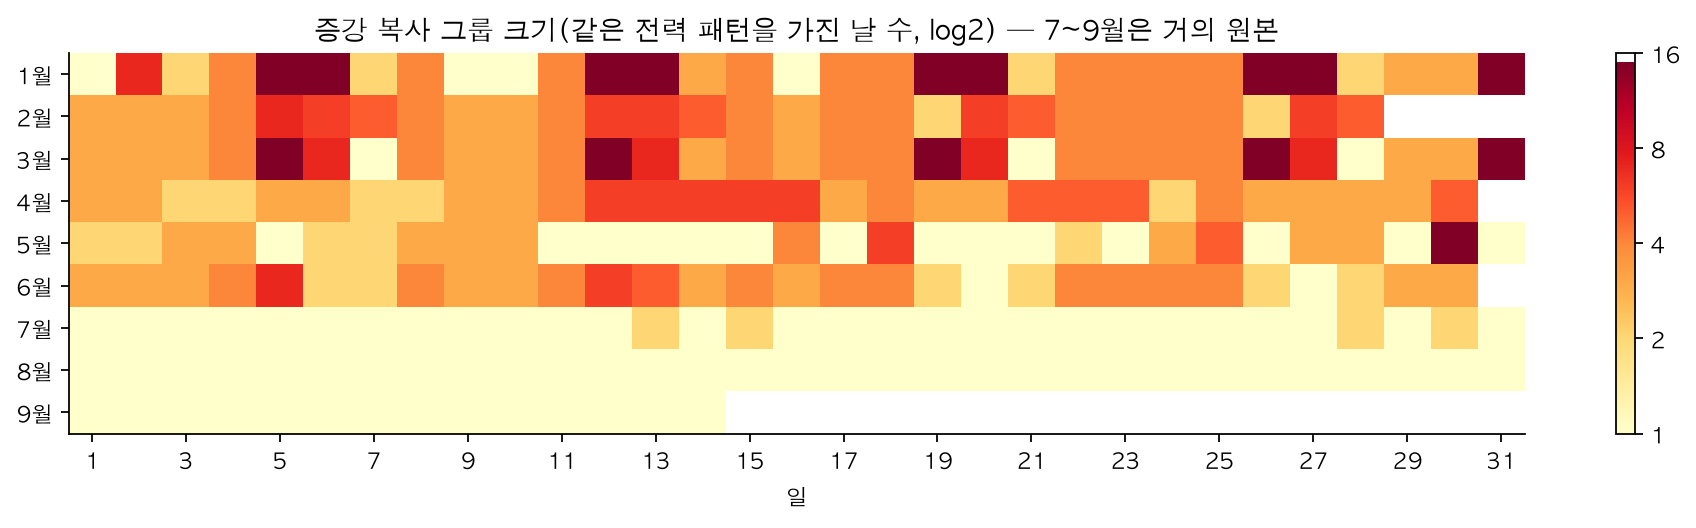

In [16]:
day = hourly.groupby("date").agg(복사그룹=("aug_group", "first"), 그룹크기=("aug_size", "first"))
print("복사일 수:", int((day["그룹크기"] > 1).sum()), "/", len(day), "| 그룹 수:", day.loc[day["복사그룹"] >= 0, "복사그룹"].nunique())
m = day.assign(월=day.index.month)
display(m.groupby("월").agg(일수=("그룹크기", "size"), 복사일=("그룹크기", lambda s: (s > 1).sum())).T)
ex = day[day["복사그룹"] == day.loc["2021-01-29", "복사그룹"]]
print("예시 그룹(전력 96개 값이 모두 같은 날):", [f"{d:%m-%d %a}" for d in ex.index])
fig(S0 / "eda_augmentation_calendar.png")

**복사의 출처 확인.** "7~9월 데이터로 1~6월을 만들었는가?"를 직접 검증합니다.
1~6월의 각 날에 대해 7~9월에서 가장 비슷한 날을 찾고, 시간 단위(15분 값 4개 묶음)로도 일치 여부를 봅니다.

In [17]:
prof = L.pivot_table(index="date", columns="slot", values="kw").dropna()
early, late = prof[prof.index < "2021-07-01"], prof[prof.index >= "2021-07-01"]
nn = np.array([np.abs(late.values - a).mean(1).min() for a in early.values])
hq = hourly.dropna(subset=["avg"]); hq = hq[hq["avg"] > 60]
key = list(zip(hq["15분"], hq["30분"], hq["45분"], hq["60분"])); hq = hq.assign(key=key)
late_keys = set(hq.loc[hq["date"] >= "2021-07-01", "key"])
print(f"1~6월 {len(early)}일 중 7~9월과 완전히 같은 날: {(nn == 0).sum()}일, 가장 가까운 날과의 평균 차이 최소 {nn.min():.2f}kW")
print(f"1~6월 가동 시간 {int((hq['date'] < '2021-07-01').sum())}개 중 7~9월과 15분 값 4개가 모두 같은 시간: {int(hq.loc[hq['date'] < '2021-07-01', 'key'].isin(late_keys).sum())}개")

1~6월 181일 중 7~9월과 완전히 같은 날: 0일, 가장 가까운 날과의 평균 차이 최소 1.04kW
1~6월 가동 시간 2892개 중 7~9월과 15분 값 4개가 모두 같은 시간: 0개


**결론.** 1~6월은 **서로 복사해 늘린 데이터**(1월 → 2·3·6월, 4월 → 5월)이고, 7~9월은 복사가 거의 없는 원본 구간입니다.
7~9월을 가져다 1~6월을 만든 흔적은 없습니다. 이 사실이 뒤의 세 가지 결정을 좌우합니다.
1. 평가는 7~9월 원본 구간에서만 한다(복사본이 학습·평가에 동시에 들어가지 않게).
2. 조건별 집계에서는 복사일을 한 번만 센다.
3. 전날·전주 전력값은 입력으로 쓰지 않는다(복사일에서는 전날과 당일이 이어지지 않음).

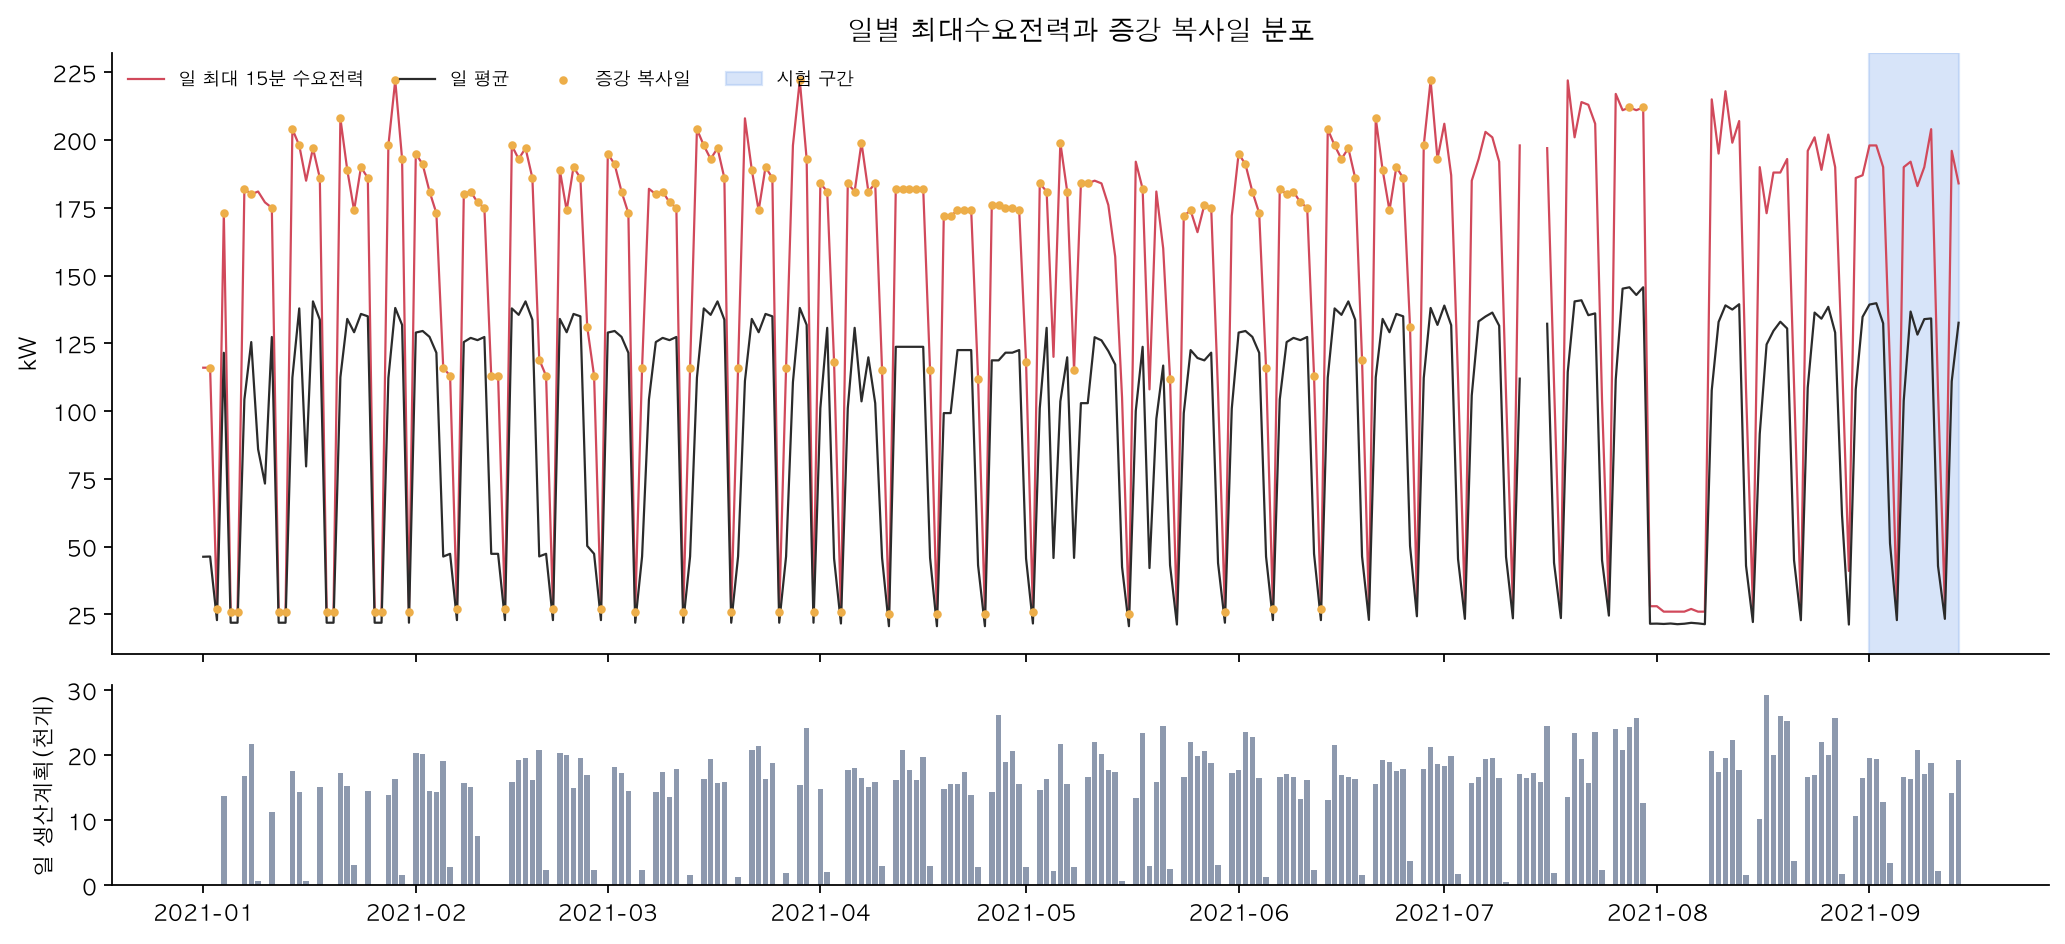

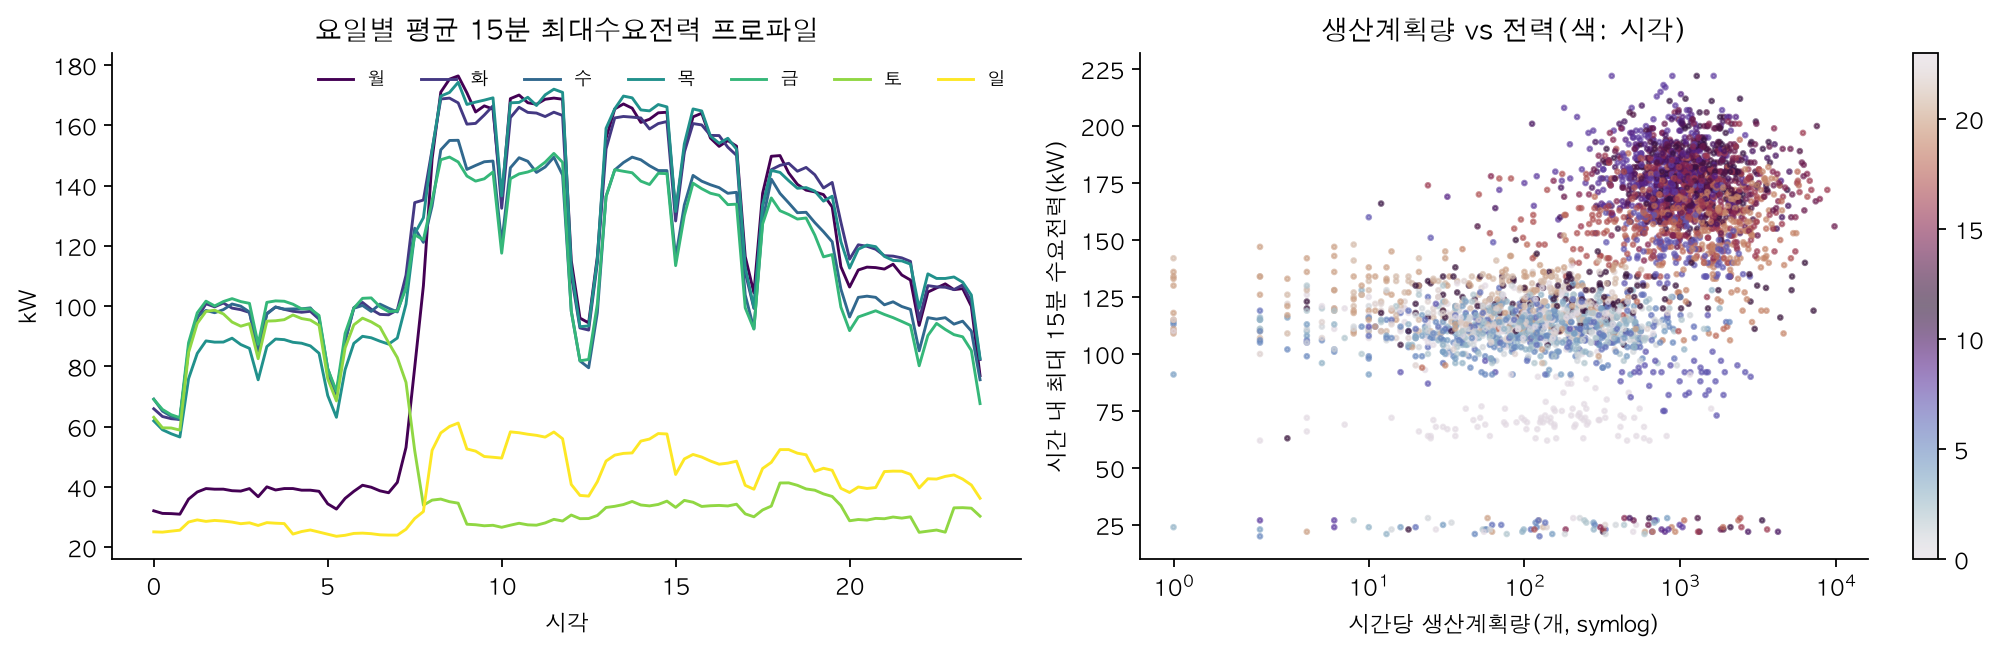

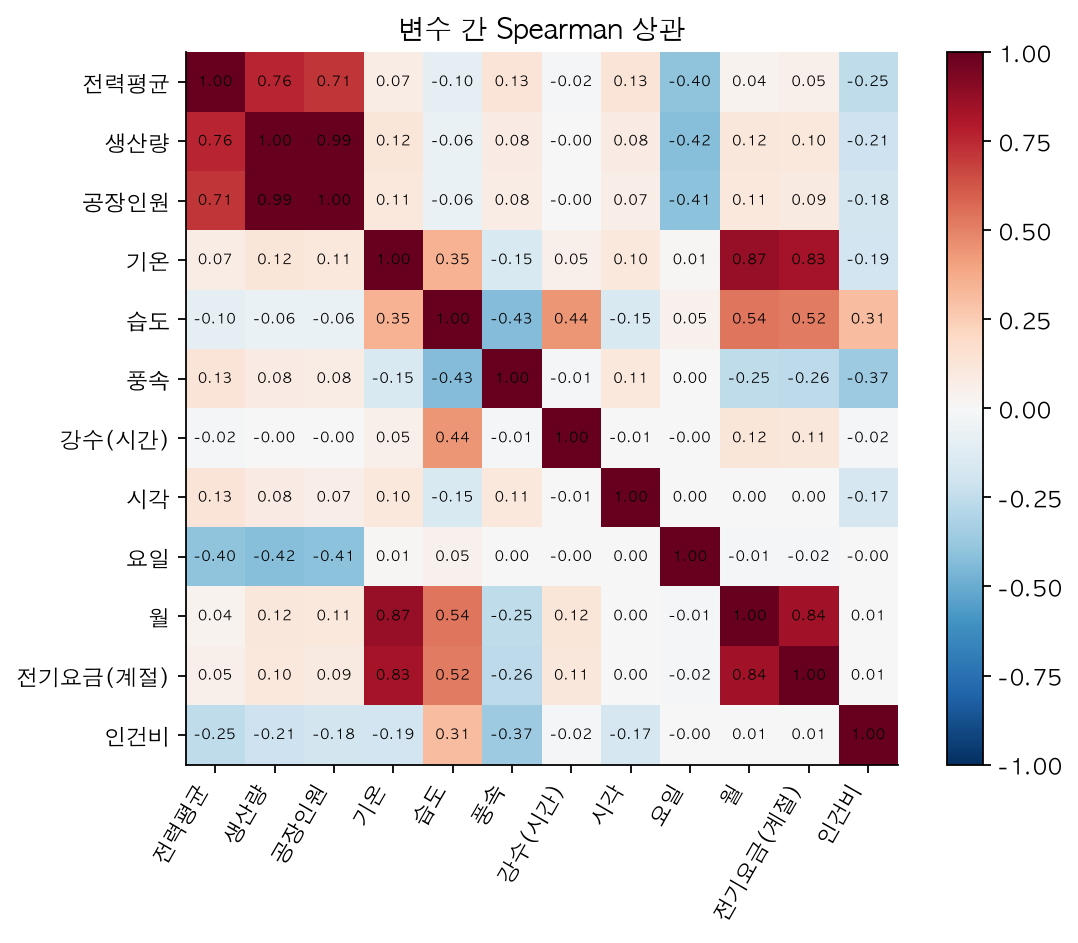

In [18]:
fig(S0 / "eda_daily_overview.png"); fig(S0 / "eda_profiles.png"); fig(S0 / "eda_corr.png", 650)

위 그림에서 읽을 수 있는 가동 패턴: 8시에 약 170kW로 오르고, 12시 점심에 약 95kW로 내려갔다가 13시에 다시 오릅니다.
화~금 새벽에는 약 100kW의 연속부하가 있고, 월요일 새벽은 약 40kW입니다.
마지막 상관행렬에서 전력은 생산량과 양의 상관을 보이고, 전기요금(계절)은 월과, 인건비는 시각과 사실상 같은 정보임을 확인할 수 있습니다. 공장인원은 생산량과 상관이 높은데, 그 정체는 0.4절에서 밝힙니다.

### 0.4 누수·중복 변수 제거

입력 변수 가운데 예측 대상(전력)에서 계산된 값이 섞여 있는지 확인합니다. **공장인원이 그런 변수였습니다.**

가이드북은 공장인원을 "해당 시점에 공장이 보유한 생산력"이라고만 설명합니다. 그런데 생산량을 공장인원으로 나눈 값이 그 시간의 전력과 완벽하게 같이 움직였고, 식을 맞춰 보니 다음과 같았습니다.

`공장인원 = 생산량 ÷ (15분 + 30분 + 45분 + 60분 전력의 합)`

In [19]:
m = (raw["생산량"] > 0) & (raw["공장인원"] > 0)
power_sum = raw.loc[m, P].sum(axis=1)
recon = raw.loc[m, "생산량"] / power_sum                      # 식으로 다시 계산한 공장인원
chk_tab = raw.loc[m, ["날짜", "시간", "생산량", "공장인원"]].assign(**{"4구간 전력 합": power_sum, "생산량÷전력합": recon}).head(6)
display(chk_tab)
print(f"생산이 있는 {int(m.sum()):,}행 전부에서 식과 실제 공장인원의 최대 차이: {(recon - raw.loc[m, '공장인원']).abs().max():.1e}")
print(f"거꾸로, 생산량÷공장인원÷4 로 역산한 평균 전력과 실제 평균 전력의 최대 차이: {((raw.loc[m, '생산량'] / raw.loc[m, '공장인원']) / 4 - raw.loc[m, P].mean(axis=1)).abs().max():.1e} kW")

,날짜,시간,생산량,공장인원,4구간 전력 합,생산량÷전력합
80,20210104,8,165,0.26,625,0.26
81,20210104,9,313,0.49,641,0.49
82,20210104,10,2757,4.40,626,4.40
83,20210104,11,983,1.65,595,1.65
84,20210104,12,96,0.27,357,0.27
85,20210104,13,791,1.27,621,1.27


생산이 있는 3,511행 전부에서 식과 실제 공장인원의 최대 차이: 4.9e-09
거꾸로, 생산량÷공장인원÷4 로 역산한 평균 전력과 실제 평균 전력의 최대 차이: 3.2e-05 kW


생산이 있는 모든 시간에서 식이 정확히 맞습니다. 즉 **생산량과 공장인원을 함께 넣으면 그 시간의 전력(정답)을 역산할 수 있습니다.** 실제 운영에서는 내일의 전력을 모르므로 이 값을 미리 알 수도 없습니다.
그래서 공장인원과 거기서 만든 파생 변수는 모든 모델 입력에서 제외했습니다.

참고로 공장인원을 넣으면 LightGBM의 Valid MAE가 8.19 → 7.73kW로, 피크 시간 MAE가 12.98 → 11.38kW로 좋아 보입니다. 이 차이가 누수로 부풀려진 몫입니다.
같은 방식으로 다른 컬럼과 컬럼 쌍(곱·비율)도 모두 확인했고, 전력을 역산할 수 있는 조합은 생산량과 공장인원뿐이었습니다.

In [20]:
XD = build_features(L, "day_ahead")     # 하루 전 예측용 피처
XH = build_features(L, "hour_ahead")    # 1시간 전 예측용(비교 실험)
split = split_table(XD)
chk = (hourly[P].mean(axis=1) - hourly["avg"]).abs().max()
print(f"'평균'과 4개 값 평균의 최대 차이: {chk:.2f}  → 목표값에서 계산되는 값")
print("전기요금(계절) 값:", sorted(raw["전기요금(계절)"].unique()), "| 인건비 값:", sorted(raw["인건비"].unique()))
display(table(S0 / "leakage_and_redundant_variables.csv"))

'평균'과 4개 값 평균의 최대 차이: 0.50  → 목표값에서 계산되는 값
전기요금(계절) 값: [np.float64(109.8), np.float64(167.2), np.float64(191.6)] | 인건비 값: [np.float64(1.0), np.float64(1.5)]


,변수,근거,처리
0,평균,예측 대상 4개 값의 평균(목표값 그 자체),제거
1,공장인원,"공장인원 = 생산량 / (15분+30분+45분+60분 전력 합). 생산이 있는 3,511행 모두에서 오차 1e-8 이하로 일치 -> 생산...",제거(파생 변수 포함)
2,15분/30분/45분/60분(같은 시각),예측 대상,"입력에서 제거, 목표값으로만 사용"
3,전기요금(계절),월만으로 결정(값 3개),제거(월과 중복)
4,인건비,"시각만으로 결정(9~17시 1.0, 그 외 1.5)",제거(시각과 중복)
5,시간(원본),"07-13, 07-15에 손상","행 순서로 재구성한 시각 사용, 두 날 전력은 제외"
6,전력 지연값(전일·전주 등),복사일이 날짜 간 연속성을 깨뜨림(백테스트 MAE 7.73 -> 11.99로 악화),최종 모델에서 제외


### 0.5 불균형 확인

예측 대상의 분포가 한쪽으로 쏠려 있는지 확인합니다. 피크(180kW 이상)는 전체의 5%뿐이고, 비가동 대기 상태가 3분의 1을 차지합니다.
평균 오차만 보면 피크를 못 맞혀도 드러나지 않으므로, 뒤에서 피크 전용 지표(F1, 일 최대 오차)와 불균형 가중 학습을 함께 씁니다.

kw,대기(40kW 미만),저부하(40~120),가동(120~180),피크(180kW 이상)
슬롯 비율 %,33.90,31.60,29.50,5.00


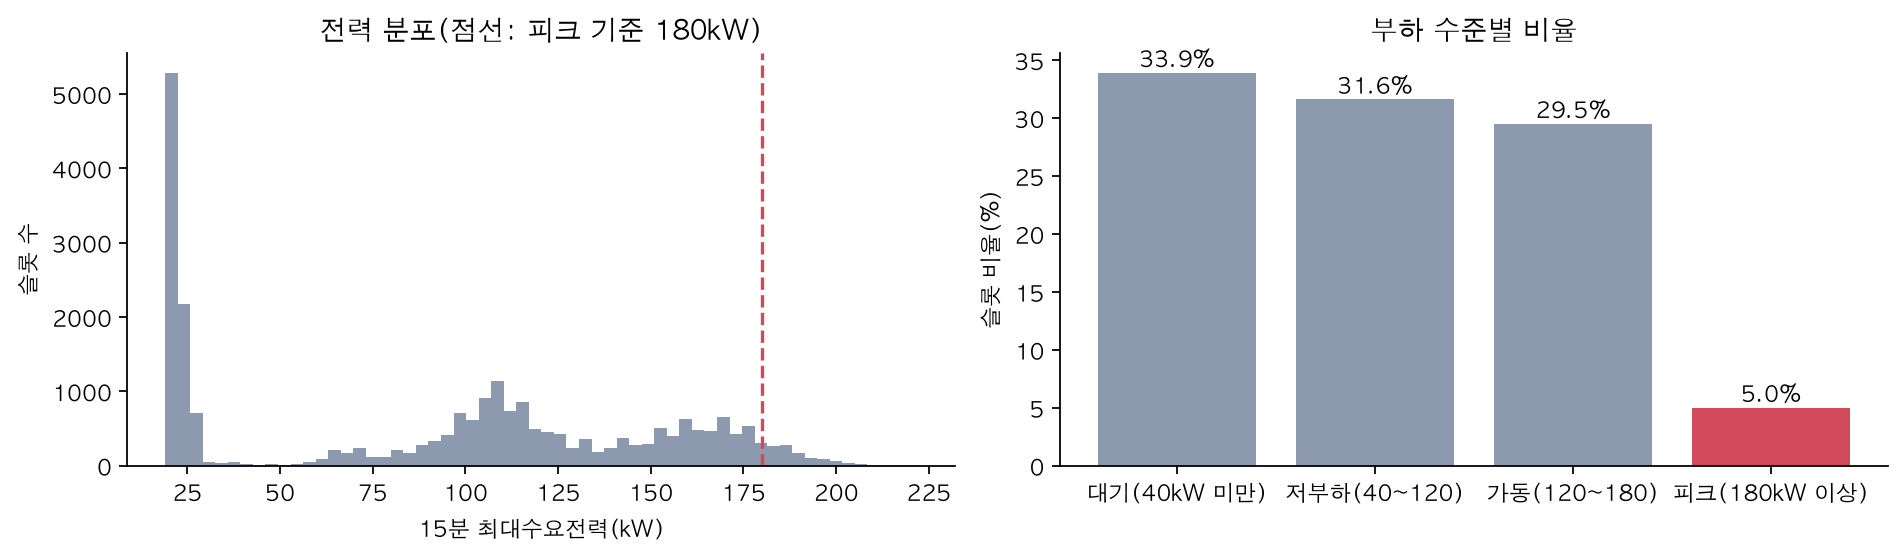

In [21]:
y = XD["kw"].dropna()
grp = pd.cut(y, [-1, 40, 120, 180, 1000], right=False, labels=["대기(40kW 미만)", "저부하(40~120)", "가동(120~180)", "피크(180kW 이상)"])
share = (grp.value_counts(normalize=True).sort_index() * 100).round(1)
display(share.to_frame("슬롯 비율 %").T)
f, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].hist(y, bins=60, color=C["muted"]); ax[0].axvline(PEAK_EVENT_KW, color=C["peak"], ls="--")
ax[0].set(xlabel="15분 최대수요전력(kW)", ylabel="슬롯 수", title="전력 분포(점선: 피크 기준 180kW)")
ax[1].bar(share.index.astype(str), share.values, color=[C["muted"]] * 3 + [C["peak"]])
for i, v in enumerate(share.values): ax[1].text(i, v + 0.5, f"{v}%", ha="center")
ax[1].set(ylabel="슬롯 비율(%)", title="부하 수준별 비율")
save(f, S0 / "imbalance.png"); fig(S0 / "imbalance.png", 950)

### 0.6 시간 순 Train / Valid / Test 분할

- **Test:** 2021-09-01~14. 모델 선택이 끝난 뒤 한 번만 평가
- **Valid:** 7월 5일부터 주 단위 8개 구간. 각 구간은 **그 이전 데이터로만** 학습(롤링 방식)
- 평가 구간 안에 복사일이 거의 없음을 표의 마지막 열로 확인합니다.

In [22]:
display(split)

,구분,학습 구간,학습 슬롯 수,평가 구간,평가 슬롯 수,평가 구간 내 복사일 수
0,Valid fold 1,2021-01-01 ~ 2021-07-04,17760,2021-07-05 ~ 2021-07-11,672,0
1,Valid fold 2,2021-01-01 ~ 2021-07-11,18432,2021-07-12 ~ 2021-07-18,480,0
2,Valid fold 3,2021-01-01 ~ 2021-07-18,18912,2021-07-19 ~ 2021-07-25,672,0
3,Valid fold 4,2021-01-01 ~ 2021-07-25,19584,2021-07-26 ~ 2021-08-01,672,2
4,Valid fold 5,2021-01-01 ~ 2021-08-08,20928,2021-08-09 ~ 2021-08-15,672,0
5,Valid fold 6,2021-01-01 ~ 2021-08-15,21600,2021-08-16 ~ 2021-08-22,672,0
6,Valid fold 7,2021-01-01 ~ 2021-08-22,22272,2021-08-23 ~ 2021-08-29,600,0
7,Valid fold 8,2021-01-01 ~ 2021-08-29,22872,2021-08-30 ~ 2021-09-05,672,0
8,Test(최종 1회),2021-01-01 ~ 2021-08-31,23064,2021-09-01 ~ 2021-09-14,1342,0


**무작위 분할을 쓰지 않는 근거.** 가이드북 실습처럼 무작위 70:30으로 나누면, 시험 표본 중 같은 패턴의 복사본이 학습셋에 들어 있는 비율이 얼마나 되는지 계산했습니다.

In [23]:
display(step_guidebook_replication(XD))

,검증 방식,MSE,RMSE,시험표본 중 학습셋에 동일패턴 복사본 존재 비율%
0,가이드북: 무작위 70:30 분할,106.76,10.33,58.34
1,시간 순 분할(9/1~9/14 시험),113.14,10.64,0.00


---
## 1단계. 전력 예측

### 1.1 예측 과제와 입력 변수

전날 24시에 다음 날 96개 15분 값을 예측합니다. 입력은 그 시점에 알 수 있는 정보만 씁니다.
- **생산계획 21개:** 당시간·전후 시간 계획량, 첫·마지막 생산 시각, 일 계획량, 재가동일(직전 정상 가동일과 2일 이상 떨어진 날) 등. 공장인원은 누수 변수라 쓰지 않음(0.4절)
- **달력 10개:** 시각, 15분 구간, 요일, 공휴일, 월 등
- **기상 8개:** 기온, 습도, 풍속, 강수, 냉방도·난방도, 일 최고·평균 기온

**함수 정의 — 모델 정의: 베이스라인 2종, Ridge, RandomForest, MLP, XGBoost, CatBoost, LightGBM**

In [24]:
N_JOBS = 4   # 스레드 고정(macOS에서 OpenMP 런타임 경합으로 인한 급격한 지연 방지, 재현성 확보)

LGB_PARAMS = dict(n_estimators=900, learning_rate=0.03, num_leaves=31, min_child_samples=30,
                  subsample=0.8, subsample_freq=1, colsample_bytree=0.8, reg_lambda=1.0,
                  random_state=SEED, verbose=-1, n_jobs=N_JOBS)


class NaiveSeasonal:
    """베이스라인1: 지난주 같은 요일·같은 15분 슬롯 값(계절성 naive)."""
    name = "Naive(지난주 동시각)"

    def fit(self, X, y, w=None):
        return self

    def predict(self, X):
        return X["lag672"].fillna(X["lag96"]).values


class LastWorkdayProfile:
    """베이스라인2: 생산계획 기반 규칙 — 가동일이면 직전 가동일 같은 슬롯, 비가동일이면 지난주 같은 슬롯."""
    name = "Rule(직전가동일 프로파일)"

    def fit(self, X, y, w=None):
        return self

    def predict(self, X):
        p = pd.Series(np.where(X["full_workday"] == 1, X["last_workday_slot"], X["lag672"]))
        for fb in ("lag672", "same_slot_7d_mean", "lag96"):      # 참조일 결측 슬롯 대체
            p = p.fillna(pd.Series(X[fb].values))
        return p.values


class SKWrap:
    def __init__(self, name, est, needs_impute=False):
        self.name, self.est, self.needs_impute = name, est, needs_impute

    def fit(self, X, y, w=None):
        kw = {}
        if w is not None:
            last = self.est.steps[-1][0] if hasattr(self.est, "steps") else None
            if last is None:
                kw["sample_weight"] = w
            elif last != "mlpregressor":
                kw[f"{last}__sample_weight"] = w
        self.est.fit(X, y, **kw)
        return self

    def predict(self, X):
        return self.est.predict(X)


def make_model(name):
    if name == "naive":
        return NaiveSeasonal()
    if name == "rule":
        return LastWorkdayProfile()
    if name == "rf":   # 가이드북 실습 모델(max_depth=20)
        return SKWrap("RandomForest(가이드북)", make_pipeline(SimpleImputer(strategy="median"),
                      RandomForestRegressor(n_estimators=300, max_depth=20, n_jobs=N_JOBS, random_state=SEED)))
    if name == "ridge":
        return SKWrap("Ridge", make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), Ridge(alpha=3.0)))
    if name == "mlp":
        return SKWrap("MLP(DNN)", make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                      MLPRegressor(hidden_layer_sizes=(128, 64), alpha=1e-3, learning_rate_init=1e-3,
                                   max_iter=300, early_stopping=True, random_state=SEED)))
    if name == "lgbm":
        return SKWrap("LightGBM", lgb.LGBMRegressor(objective="regression", **LGB_PARAMS))
    if name == "lgbm_l1":
        return SKWrap("LightGBM(L1)", lgb.LGBMRegressor(objective="l1", **LGB_PARAMS))
    if name == "xgb":
        return SKWrap("XGBoost", xgb.XGBRegressor(n_estimators=800, learning_rate=0.03, max_depth=6, subsample=0.8,
                      colsample_bytree=0.8, min_child_weight=5, random_state=SEED, n_jobs=N_JOBS))
    if name == "cat":
        return SKWrap("CatBoost", CatBoostRegressor(iterations=1500, learning_rate=0.05, depth=6, loss_function="RMSE",
                      random_seed=SEED, verbose=0, allow_writing_files=False,
                                                    thread_count=N_JOBS))
    raise ValueError(name)


def make_quantile(alpha):
    p = dict(LGB_PARAMS)
    return lgb.LGBMRegressor(objective="quantile", alpha=alpha, **p)

**함수 정의 — 평가지표와 학습 가중치**

In [25]:
def point_metrics(y, p):
    y, p = np.asarray(y, float), np.asarray(p, float)
    m = ~np.isnan(y) & ~np.isnan(p)
    y, p = y[m], p[m]
    e = p - y
    rmse = np.sqrt(np.mean(e ** 2))
    return {"MAE": np.mean(np.abs(e)), "RMSE": rmse, "CV(RMSE)%": 100 * rmse / np.mean(y),
            "NMAE%": 100 * np.mean(np.abs(e)) / np.mean(y), "Bias": np.mean(e)}


def peak_metrics(df, pred_col="pred", y_col="kw"):
    """일 최대수요전력(일 피크) 크기·시각 오차, 피크위험 이벤트(>=180kW) 분류 성능."""
    d = df.dropna(subset=[y_col])
    g = d.groupby("date")
    ymax, pmax = g[y_col].max(), g[pred_col].max()
    work = g["full_workday"].first() == 1
    t_true = g.apply(lambda x: x.loc[x[y_col].idxmax(), "slot"])
    t_pred = g.apply(lambda x: x.loc[x[pred_col].idxmax(), "slot"])
    ev_true = (d[y_col] >= PEAK_EVENT_KW).astype(int)
    ev_pred = (d[pred_col] >= PEAK_EVENT_KW).astype(int)
    return {
        "DailyPeak_MAE": np.mean(np.abs(pmax - ymax)),
        "DailyPeak_MAE(가동일)": np.mean(np.abs(pmax - ymax)[work]),
        "PeakTime_within1h%": 100 * np.mean((np.abs(t_true - t_pred) <= 4)[work]),
        "PeriodPeak_err": pmax.max() - ymax.max(),
        "PeakEvent_F1": f1_score(ev_true, ev_pred, zero_division=0),
        "PeakEvent_Precision": precision_score(ev_true, ev_pred, zero_division=0),
        "PeakEvent_Recall": recall_score(ev_true, ev_pred, zero_division=0),
    }


def all_metrics(df, pred_col="pred"):
    out = point_metrics(df["kw"], df[pred_col])
    w = df["is_prod_hour"] == 1
    out["MAE(생산시간)"] = point_metrics(df.loc[w, "kw"], df.loc[w, pred_col])["MAE"]
    out.update(peak_metrics(df, pred_col))
    return out


def sample_weight(X, scheme):
    if scheme == "none":
        return np.ones(len(X))
    if scheme == "aug_inv":            # 증강 복사 그룹 크기의 역수: 같은 패턴이 n번 반복되면 각 1/n
        return 1.0 / X["aug_size"].values
    if scheme == "aug_inv_recent":     # + 최근(7월 이후 원본 구간) 2배
        return (1.0 / X["aug_size"].values) * np.where(X["ts"] >= "2021-07-01", 2.0, 1.0)
    raise ValueError(scheme)

**함수 정의 — 하이퍼파라미터 탐색과 앙상블 비교**

In [26]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
NJ = 4


def build(kind, p):
    if kind == "lgbm":
        return lgb.LGBMRegressor(random_state=SEED, verbose=-1, n_jobs=NJ, subsample_freq=1, **p)
    if kind == "xgb":
        return xgb.XGBRegressor(random_state=SEED, n_jobs=NJ, **p)
    if kind == "cat":
        return CatBoostRegressor(random_seed=SEED, verbose=0, allow_writing_files=False, thread_count=NJ, loss_function="RMSE", **p)
    if kind == "rf":
        return make_pipeline(SimpleImputer(strategy="median"), RandomForestRegressor(n_jobs=NJ, random_state=SEED, **p))
    if kind == "et":
        return make_pipeline(SimpleImputer(strategy="median"), ExtraTreesRegressor(n_jobs=NJ, random_state=SEED, **p))
    if kind == "hgb":
        return HistGradientBoostingRegressor(random_state=SEED, **p)
    if kind == "mlp":
        return make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                             MLPRegressor(max_iter=300, early_stopping=True, random_state=SEED, **p))
    raise ValueError(kind)


def cv_predict(X, feats, kind, p):
    """8개 구간 표본 외 예측(구간 순서대로 이어 붙인 배열)."""
    out = []
    for f0 in CV_FOLD_STARTS:
        s = pd.Timestamp(f0)
        e = s + pd.Timedelta(days=CV_FOLD_DAYS)
        tr = X[(X["ts"] < s) & X["kw"].notna()]
        te = X[(X["ts"] >= s) & (X["ts"] < e)]
        out.append(np.clip(build(kind, p).fit(tr[feats], tr["kw"]).predict(te[feats]), 0, None))
    return np.concatenate(out)


def cv_frame(X):
    parts = []
    for f0 in CV_FOLD_STARTS:
        s = pd.Timestamp(f0)
        e = s + pd.Timedelta(days=CV_FOLD_DAYS)
        parts.append(X[(X["ts"] >= s) & (X["ts"] < e)].assign(fold=f0))
    return pd.concat(parts)


SPACES = {
    "lgbm": lambda t: dict(n_estimators=t.suggest_int("n_estimators", 300, 1500, step=100),
                           learning_rate=t.suggest_float("learning_rate", 0.01, 0.1, log=True),
                           num_leaves=t.suggest_int("num_leaves", 7, 63),
                           min_child_samples=t.suggest_int("min_child_samples", 10, 80),
                           subsample=t.suggest_float("subsample", 0.6, 1.0),
                           colsample_bytree=t.suggest_float("colsample_bytree", 0.5, 1.0),
                           reg_lambda=t.suggest_float("reg_lambda", 0.01, 10, log=True),
                           objective=t.suggest_categorical("objective", ["regression", "l1", "huber"])),
    "xgb": lambda t: dict(n_estimators=t.suggest_int("n_estimators", 300, 1500, step=100),
                          learning_rate=t.suggest_float("learning_rate", 0.01, 0.1, log=True),
                          max_depth=t.suggest_int("max_depth", 3, 8),
                          min_child_weight=t.suggest_int("min_child_weight", 1, 20),
                          subsample=t.suggest_float("subsample", 0.6, 1.0),
                          colsample_bytree=t.suggest_float("colsample_bytree", 0.5, 1.0),
                          reg_lambda=t.suggest_float("reg_lambda", 0.01, 10, log=True)),
    "cat": lambda t: dict(iterations=t.suggest_int("iterations", 500, 1500, step=250),
                          learning_rate=t.suggest_float("learning_rate", 0.03, 0.15, log=True),
                          depth=t.suggest_int("depth", 4, 8),
                          l2_leaf_reg=t.suggest_float("l2_leaf_reg", 1, 10, log=True)),
}
DEFAULTS = {
    "lgbm": dict(n_estimators=900, learning_rate=0.03, num_leaves=31, min_child_samples=30, subsample=0.8,
                 colsample_bytree=0.8, reg_lambda=1.0, objective="regression"),
    "xgb": dict(n_estimators=800, learning_rate=0.03, max_depth=6, subsample=0.8, colsample_bytree=0.8, min_child_weight=5),
    "cat": dict(iterations=1500, learning_rate=0.05, depth=6),
}
GRIDS = {
    "rf": [dict(n_estimators=300, max_depth=20), dict(n_estimators=300, max_depth=12, min_samples_leaf=5),
           dict(n_estimators=500, max_depth=None, min_samples_leaf=3, max_features=0.5)],
    "et": [dict(n_estimators=300, max_depth=None, min_samples_leaf=3), dict(n_estimators=500, max_depth=20, min_samples_leaf=5, max_features=0.7)],
    "hgb": [dict(max_iter=600, learning_rate=0.05, max_leaf_nodes=31), dict(max_iter=1000, learning_rate=0.03, max_leaf_nodes=15, l2_regularization=1.0)],
    "mlp": [dict(hidden_layer_sizes=(128, 64), alpha=1e-3, learning_rate_init=1e-3),
            dict(hidden_layer_sizes=(64, 32), alpha=1e-2, learning_rate_init=1e-3),
            dict(hidden_layer_sizes=(256, 128, 64), alpha=1e-3, learning_rate_init=5e-4)],
}
NAMES = {"lgbm": "LightGBM", "xgb": "XGBoost", "cat": "CatBoost", "rf": "RandomForest", "et": "ExtraTrees",
         "hgb": "HistGradientBoosting", "mlp": "MLP"}


# 아래 탐색(search)으로 찾은 최적 설정의 기록(반올림 없이 그대로: CatBoost는 학습률 소수 넷째 자리 차이에도 MAE가 0.3kW 달라짐).
# 기본 실행은 이 설정으로 학습만 하고, 탐색을 다시 하려면 search()를 호출
TUNED = {'lgbm': {'n_estimators': 300, 'learning_rate': 0.09330606024425668, 'num_leaves': 54, 'min_child_samples': 25, 'subsample': 0.6727299868828402, 'colsample_bytree': 0.5917022549267169, 'reg_lambda': 0.08179499475211674, 'objective': 'regression'}, 'xgb': {'n_estimators': 1200, 'learning_rate': 0.010530955003248244, 'max_depth': 8, 'min_child_weight': 3, 'subsample': 0.649207772328176, 'colsample_bytree': 0.7280595244346797, 'reg_lambda': 0.7202519832502359}, 'cat': {'iterations': 1250, 'learning_rate': 0.031010530712092203, 'depth': 8, 'l2_leaf_reg': 6.798962421591129}, 'rf': {'n_estimators': 500, 'max_depth': None, 'min_samples_leaf': 3, 'max_features': 0.5}, 'et': {'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 3}, 'hgb': {'max_iter': 600, 'learning_rate': 0.05, 'max_leaf_nodes': 31}, 'mlp': {'hidden_layer_sizes': (256, 128, 64), 'alpha': 0.001, 'learning_rate_init': 0.0005}}

# 최종 전력량 예측 모델은 이름을 고정하지 않고, run()에서 백테스트 MAE가 가장 낮은 후보로 자동 선정한다.


def tuning_search(X, n_trials=None, log=print):
    """하이퍼파라미터 탐색(약 30분). 부스팅 3종은 Optuna, 나머지 4종은 격자. 시도 기록을 tuning_trials.csv로 저장."""
    n_trials = n_trials or {"lgbm": 30, "xgb": 30, "cat": 15}
    feats = feature_list("day_ahead", weather=True, lags=False)
    V = cv_frame(X)
    y = V["kw"].values
    ok = ~np.isnan(y)
    mae = lambda p: float(np.mean(np.abs(p[ok] - y[ok])))
    trials, best = [], {}
    for kind in ("lgbm", "xgb", "cat"):       # 기본값을 첫 시도로 넣어 '기본값보다 나빠지는 일'을 방지
        t0 = time.time()

        def obj(t, kind=kind):
            return mae(cv_predict(X, feats, kind, SPACES[kind](t)))

        st = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
        st.enqueue_trial({k: v for k, v in DEFAULTS[kind].items()})
        st.optimize(obj, n_trials=n_trials[kind])
        for t in st.trials:
            trials.append({"모델": NAMES[kind], "시도": t.number, "MAE": t.value, "기본값": int(t.number == 0), **{f"p_{k}": v for k, v in t.params.items()}})
        best[kind] = st.best_params
        log(f"  {NAMES[kind]}: 기본값 MAE {st.trials[0].value:.3f} -> 탐색 최적 {st.best_value:.3f} ({n_trials[kind]}회, {time.time() - t0:.0f}s)")
    for kind, grid in GRIDS.items():
        res = []
        for i, p in enumerate(grid):
            res.append((mae(cv_predict(X, feats, kind, p)), i))
            trials.append({"모델": NAMES[kind], "시도": i, "MAE": res[-1][0], "기본값": int(i == 0), "p_설정": str(p)})
        best[kind] = grid[min(res)[1]]
        log(f"  {NAMES[kind]}: 격자 {len(grid)}개 중 최적 MAE {min(res)[0]:.3f}")
    pd.DataFrame(trials).to_csv(S1 / "tuning_trials.csv", index=False, encoding="utf-8-sig")
    return best


def tuning_run(X, best=None, log=print):
    """탐색된 설정(best, 기본은 TUNED)으로 7종 모델을 백테스트·시험 평가하고 앙상블 5종을 비교."""
    best = best or TUNED
    feats = feature_list("day_ahead", weather=True, lags=False)
    V = cv_frame(X)
    y = V["kw"].values
    ok = ~np.isnan(y)
    oos = {}
    for kind in ("lgbm", "xgb", "cat"):
        oos[NAMES[kind] + "(기본값)"] = cv_predict(X, feats, kind, DEFAULTS[kind])
    for kind in best:
        t0 = time.time()
        oos[NAMES[kind] + "(탐색)"] = oos[NAMES[kind] + "(기본값)"] if best[kind] == DEFAULTS.get(kind) else cv_predict(X, feats, kind, best[kind])
        log(f"  {NAMES[kind]}(탐색 설정): 백테스트 MAE {np.mean(np.abs(oos[NAMES[kind] + '(탐색)'][ok] - y[ok])):.3f} ({time.time() - t0:.0f}s)")

    # ---- (3) 앙상블(구간 교차 방식으로 가중치·메타모델 추정) ----
    base = [n for n in oos if n.endswith("(탐색)")]
    P = np.column_stack([oos[n] for n in base])
    boost = [base.index(NAMES[k] + "(탐색)") for k in ("lgbm", "xgb", "cat")]
    fold = V["fold"].values
    ens = {"앙상블: 부스팅 3종 평균": P[:, boost].mean(1), "앙상블: 전체 7종 평균": P.mean(1), "앙상블: 전체 7종 중앙값": np.median(P, 1)}
    w_nn, st_pred = np.zeros(len(y)), np.zeros(len(y))
    for f in np.unique(fold):
        tr, te = (fold != f) & ok, fold == f
        w, _ = nnls(P[tr], y[tr])
        w = w / w.sum()
        w_nn[te] = P[te] @ w
        st_pred[te] = Ridge(alpha=10.0).fit(P[tr], y[tr]).predict(P[te])
    ens["앙상블: 비음수 가중 평균(NNLS)"] = w_nn
    ens["앙상블: 스태킹(Ridge 메타모델)"] = np.clip(st_pred, 0, None)
    w_full, _ = nnls(P[ok], y[ok])
    w_full = w_full / w_full.sum()
    meta = Ridge(alpha=10.0).fit(P[ok], y[ok])
    W = pd.Series(w_full, index=[b.replace("(탐색)", "") for b in base], name="가중치").round(3)
    W.to_csv(S1 / "ensemble_weights.csv", encoding="utf-8-sig")

    # ---- (4) 시험 구간: 9/1 이전 전체로 학습 ----
    tr = X[(X["ts"] < TEST_START) & X["kw"].notna()]
    te = X[X["ts"] >= TEST_START].copy()
    tp = {}
    for kind in ("lgbm", "xgb", "cat"):
        tp[NAMES[kind] + "(기본값)"] = np.clip(build(kind, DEFAULTS[kind]).fit(tr[feats], tr["kw"]).predict(te[feats]), 0, None)
    for kind in best:
        tp[NAMES[kind] + "(탐색)"] = np.clip(build(kind, best[kind]).fit(tr[feats], tr["kw"]).predict(te[feats]), 0, None)
    PT = np.column_stack([tp[n] for n in base])
    tp["앙상블: 부스팅 3종 평균"] = PT[:, boost].mean(1)
    tp["앙상블: 전체 7종 평균"] = PT.mean(1)
    tp["앙상블: 전체 7종 중앙값"] = np.median(PT, 1)
    tp["앙상블: 비음수 가중 평균(NNLS)"] = PT @ w_full
    tp["앙상블: 스태킹(Ridge 메타모델)"] = np.clip(meta.predict(PT), 0, None)

    # ---- (5) 결과표: 백테스트·시험, 구간별 MAE 표준편차 ----
    rows = []
    allcv = {**oos, **ens}
    for n in allcv:
        m = all_metrics(V.assign(pred=allcv[n]))
        fm = [np.mean(np.abs(allcv[n][(fold == f) & ok] - y[(fold == f) & ok])) for f in np.unique(fold)]
        mt = all_metrics(te.assign(pred=tp[n]))
        base_fm = [np.mean(np.abs(oos["LightGBM(기본값)"][(fold == f) & ok] - y[(fold == f) & ok])) for f in np.unique(fold)]
        rows.append({"모델": n, "백테스트 MAE": m["MAE"], "백테스트 RMSE": m["RMSE"], "구간별 MAE 표준편차": np.std(fm),
                     "LightGBM 기본값보다 나은 구간 수(8개 중)": int(np.sum(np.array(fm) < np.array(base_fm) - 1e-9)),
                     "백테스트 일최대 MAE(가동일)": m["DailyPeak_MAE(가동일)"], "시험 MAE": mt["MAE"], "시험 RMSE": mt["RMSE"],
                     "시험 일최대 MAE(가동일)": mt["DailyPeak_MAE(가동일)"]})
    RES = pd.DataFrame(rows).sort_values("백테스트 MAE").reset_index(drop=True)
    RES.round(3).to_csv(S1 / "tuning_and_ensemble_comparison.csv", index=False, encoding="utf-8-sig")
    FINAL_NAME = RES.iloc[0]["모델"]            # 선정 규칙: 백테스트(Valid) MAE 최저. 시험 성적은 선정에 쓰지 않음
    BP = pd.DataFrame([{"모델": NAMES[k], "최적 설정": str({a: (round(b, 4) if isinstance(b, float) else b) for a, b in v.items()})} for k, v in best.items()])
    BP.to_csv(S1 / "tuning_best_params.csv", index=False, encoding="utf-8-sig")

    # ---- 그림: 탐색 과정(시도 기록이 있을 때) / 모델·앙상블 비교 ----
    tfile = S1 / "tuning_trials.csv"
    fig, ax = plt.subplots(1, 2, figsize=(15, 4.8), gridspec_kw={"width_ratios": [1, 1.25]})
    if tfile.exists():
        TR = pd.read_csv(tfile)
        for kind, colr in (("lgbm", C["pred"]), ("xgb", C["good"]), ("cat", C["accent"])):
            q = TR[TR["모델"] == NAMES[kind]].sort_values("시도")
            ax[0].scatter(q["시도"], q["MAE"], s=12, color=colr, alpha=.5)
            ax[0].plot(q["시도"], q["MAE"].cummin(), color=colr, lw=1.6, label=f"{NAMES[kind]} (기본값 {q['MAE'].iloc[0]:.2f} → 최적 {q['MAE'].min():.2f})")
        ax[0].set(xlabel="탐색 시도 번호(0 = 기본값)", ylabel="백테스트 MAE(kW)", title="하이퍼파라미터 탐색 과정(선: 그때까지의 최적)")
        ax[0].set_ylim(TR[TR["모델"].isin(["LightGBM", "XGBoost", "CatBoost"])]["MAE"].min() - .1, 9.2)
        ax[0].legend(frameon=False, fontsize=8)
    else:
        TR = None
        ax[0].axis("off")
        ax[0].text(.5, .5, "탐색 시도 기록(tuning_trials.csv) 없음\nsearch()를 실행하면 생성됩니다", ha="center", va="center")
    r = RES.sort_values("백테스트 MAE", ascending=False)
    yy = np.arange(len(r))
    ax[1].barh(yy + .2, r["백테스트 MAE"], .4, color=C["muted"], label="백테스트(7~8월)")
    ax[1].barh(yy - .2, r["시험 MAE"], .4, color=[C["peak"] if n == FINAL_NAME else C["pred"] for n in r["모델"]], label="시험(9/1~14)")
    ax[1].set_yticks(yy, r["모델"], fontsize=8)
    ax[1].set(xlabel="MAE(kW)", title="탐색 모델과 앙상블 비교(붉은색: 최종 선정)", xlim=(5.5, max(r["백테스트 MAE"].max(), r["시험 MAE"].max()) + .3))
    ax[1].legend(frameon=False, fontsize=8)
    save(fig, S1 / "tuning_and_ensemble.png")
    final = {"name": FINAL_NAME, "cv_pred": pd.Series(allcv[FINAL_NAME], index=V.index), "test_pred": pd.Series(tp[FINAL_NAME], index=te.index),
             "members": [b.replace("(탐색)", "") for b in base] if FINAL_NAME.startswith("앙상블") else [FINAL_NAME.replace("(탐색)", "")]}
    return RES, TR, BP, W, final

**함수 정의 — 일 최대 전용 예측**

In [27]:
DAY_FEATS = ["day_prod", "day_prod_hours", "first_prod_hour", "restart_day", "days_since_workday",
             "full_workday", "dow", "holiday", "month", "temp_max", "temp_mean", "prev_day_prod"]


def day_frame(X):
    agg = {c: (c, "first") for c in DAY_FEATS + ["last_workday_max", "last_same_dow_max"]}
    agg["ymax"] = ("kw", "max")
    agg["n_obs"] = ("kw", "count")
    D = X.groupby("date").agg(**agg)
    D.loc[D["n_obs"] < 80, "ymax"] = np.nan    # 결측이 많은 날은 일 피크 목표에서 제외
    return D


class DailyPeakModel:
    """일 최대 15분 수요전력 = 0.5*LightGBM(일 단위 계획·달력·기상) + 0.5*규칙(가동일: 직전 가동일 최대값)."""

    def __init__(self, w_rule=0.5):
        self.w_rule = w_rule
        self.m = lgb.LGBMRegressor(n_estimators=400, learning_rate=0.03, num_leaves=8, min_child_samples=10,
                                   subsample=0.8, subsample_freq=1, random_state=SEED, verbose=-1, n_jobs=4)

    def fit(self, D):
        t = D.dropna(subset=["ymax"])
        self.m.fit(t[DAY_FEATS], t["ymax"])
        return self

    def predict(self, D):
        pm = self.m.predict(D[DAY_FEATS])
        rule = np.where(D["full_workday"] == 1, D["last_workday_max"], D["last_same_dow_max"])
        rule = np.where(np.isnan(rule), pm, rule)
        return pd.DataFrame({"dmax_model": pm, "dmax_rule": rule,
                             "dmax_pred": (1 - self.w_rule) * pm + self.w_rule * rule}, index=D.index)

**함수 정의 — 피크 발생 확률 예측(불균형 가중, 확률보정)**

In [28]:
CLF_PARAMS = dict(n_estimators=500, learning_rate=0.03, num_leaves=15, min_child_samples=40, subsample=0.8,
                  subsample_freq=1, colsample_bytree=0.8, random_state=SEED, verbose=-1, n_jobs=4)
PROB_MODELS = ["로지스틱 회귀(불균형 가중)", "LightGBM 분류", "LightGBM 분류(불균형 가중)"]


def _make(name, pos_ratio):
    if name == "로지스틱 회귀(불균형 가중)":
        return make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                             LogisticRegression(C=0.5, class_weight="balanced", max_iter=2000))
    if name == "LightGBM 분류":
        return lgb.LGBMClassifier(**CLF_PARAMS)
    return lgb.LGBMClassifier(scale_pos_weight=pos_ratio, **CLF_PARAMS)      # 피크:비피크 비율만큼 피크에 가중


def _fit_predict(name, tr, te, feats):
    y = (tr["kw"] >= PEAK_EVENT_KW).astype(int)
    m = _make(name, (y == 0).sum() / max((y == 1).sum(), 1))
    m.fit(tr[feats], y)
    return m, m.predict_proba(te[feats])[:, 1]


def _scores(y, p, thr):
    hat = (p >= thr).astype(int)
    return {"F1": f1_score(y, hat, zero_division=0), "정밀도": precision_score(y, hat, zero_division=0),
            "재현율": recall_score(y, hat, zero_division=0), "PR-AUC": average_precision_score(y, p),
            "ROC-AUC": roc_auc_score(y, p), "Brier": brier_score_loss(y, np.clip(p, 0, 1))}


def _best_thr(y, p, grid):
    f = [f1_score(y, (p >= t).astype(int), zero_division=0) for t in grid]
    return float(grid[int(np.argmax(f))])


def peak_prob_run(X, oos_reg, Xte_reg):
    """oos_reg: 백테스트의 전력량 예측(LightGBM 회귀), Xte_reg: 시험 구간 전력량 예측 프레임."""
    feats = feature_list("day_ahead", weather=True, lags=False)
    # ---- 백테스트(표본 외) 확률 ----
    parts = []
    for f0 in CV_FOLD_STARTS:
        s = pd.Timestamp(f0)
        e = s + pd.Timedelta(days=CV_FOLD_DAYS)
        tr = X[(X["ts"] < s) & X["kw"].notna()]
        te = X[(X["ts"] >= s) & (X["ts"] < e)].copy()
        for name in PROB_MODELS:
            te[name] = _fit_predict(name, tr, te, feats)[1]
        parts.append(te)
    cv = pd.concat(parts)
    cv["전력량 예측값 기준(회귀)"] = oos_reg["pred"].values
    cv["베이스라인1 지난주 같은 시각"] = cv["lag672"].fillna(cv["lag96"]).values
    b2 = pd.Series(np.where(cv["full_workday"] == 1, cv["last_workday_slot"], cv["lag672"]), index=cv.index)
    cv["베이스라인2 직전 가동일 프로파일"] = b2.fillna(cv["lag672"]).fillna(cv["same_slot_7d_mean"]).values

    # ---- 시험 구간: 9/1 이전 전체로 학습 ----
    tr = X[(X["ts"] < TEST_START) & X["kw"].notna()]
    te = X[X["ts"] >= TEST_START].copy()
    models = {}
    for name in PROB_MODELS:
        models[name], te[name] = _fit_predict(name, tr, te, feats)
    te["전력량 예측값 기준(회귀)"] = Xte_reg["pred"].values
    te["베이스라인1 지난주 같은 시각"] = te["lag672"].fillna(te["lag96"]).values
    b2 = pd.Series(np.where(te["full_workday"] == 1, te["last_workday_slot"], te["lag672"]), index=te.index)
    te["베이스라인2 직전 가동일 프로파일"] = b2.fillna(te["lag672"]).fillna(te["same_slot_7d_mean"]).values

    v, t = cv.dropna(subset=["kw"]), te.dropna(subset=["kw"])
    yv, yt = (v["kw"] >= PEAK_EVENT_KW).astype(int), (t["kw"] >= PEAK_EVENT_KW).astype(int)

    # ---- 확률보정(등위 회귀): 백테스트 표본 외 확률 -> 실제 발생 비율 ----
    iso, rows = {}, []
    for name in PROB_MODELS:
        iso[name] = IsotonicRegression(out_of_bounds="clip", y_min=0, y_max=1).fit(v[name], yv)
        for d in (cv, te, v, t):
            d[name + " [보정]"] = iso[name].predict(d[name])
    v, t = cv.dropna(subset=["kw"]), te.dropna(subset=["kw"])

    kw_grid = np.arange(160, 196, 1.0)
    p_grid = np.round(np.arange(0.05, 0.96, 0.01), 2)
    for name in ["베이스라인1 지난주 같은 시각", "베이스라인2 직전 가동일 프로파일", "전력량 예측값 기준(회귀)"]:
        base = name.startswith("베이스라인")
        thr = PEAK_EVENT_KW if base else _best_thr(yv, v[name].fillna(0).values, kw_grid)
        for seg, y, d in (("백테스트(7~8월)", yv, v), ("시험(9/1~14)", yt, t)):
            s = _scores(y, d[name].fillna(0).values, thr)
            s["Brier"] = np.nan                       # kW 값이라 확률 정확도(Brier)는 해당 없음
            rows.append({"모델": name, "구간": seg, "판정 기준": f"{thr:.0f}kW 이상", **s})
    for name in PROB_MODELS:
        for col, tag in ((name, name), (name + " [보정]", name + " + 확률보정")):
            thr = _best_thr(yv, v[col].values, p_grid)
            for seg, y, d in (("백테스트(7~8월)", yv, v), ("시험(9/1~14)", yt, t)):
                rows.append({"모델": tag, "구간": seg, "판정 기준": f"확률 {thr:.2f} 이상", **_scores(y, d[col].values, thr)})
    T = pd.DataFrame(rows)
    T.round(3).to_csv(S1 / "peak_probability_model_comparison.csv", index=False, encoding="utf-8-sig")

    # ---- 최종 확률 모델: 백테스트 PR-AUC가 가장 높은 분류 모델 + 확률보정 ----
    cvT = T[T["구간"] == "백테스트(7~8월)"].set_index("모델")
    best = max(PROB_MODELS, key=lambda n: cvT.loc[n, "PR-AUC"])
    final_col = best + " [보정]"
    thr = _best_thr(yv, v[final_col].values, p_grid)
    te["peak_prob"] = te[final_col]
    cv["peak_prob"] = cv[final_col]
    # 경보 규칙: '보정 확률 >= 기준'과 '전력량 예측값 >= 기준 kW' 중 백테스트 F1이 높은 쪽을 사용(시험 성적은 선택에 쓰지 않음)
    reg = "전력량 예측값 기준(회귀)"
    thr_kw = _best_thr(yv, v[reg].fillna(0).values, kw_grid)
    f1_prob = f1_score(yv, (v[final_col] >= thr).astype(int), zero_division=0)
    f1_reg = f1_score(yv, (v[reg].fillna(0) >= thr_kw).astype(int), zero_division=0)
    use_reg = f1_reg > f1_prob
    for d in (te, cv):
        d["peak_prob_alert"] = ((d[reg].fillna(0) >= thr_kw) if use_reg else (d[final_col] >= thr)).astype(int)
    alert_rule = f"전력량 예측값 {thr_kw:.0f}kW 이상" if use_reg else f"피크 확률 {thr:.2f} 이상"
    alert_test_f1 = float(f1_score(yt, te.loc[t.index, "peak_prob_alert"], zero_division=0))

    # 보정 전후 신뢰도표(시험)
    cal = []
    bins = [0, .05, .15, .3, .5, .7, 1.0001]
    for col, tag in ((best, "보정 전"), (final_col, "보정 후")):
        g = t.assign(b=pd.cut(t[col], bins, right=False), y=yt.values).groupby("b", observed=True)
        for b, x in g:
            cal.append({"구분": tag, "예측 확률 구간": f"{b.left:.2f}~{min(b.right, 1):.2f}", "슬롯 수": len(x),
                        "평균 예측 확률": x[col].mean(), "실제 피크 비율": x["y"].mean()})
    CAL = pd.DataFrame(cal)
    CAL.round(3).to_csv(S1 / "peak_probability_calibration.csv", index=False, encoding="utf-8-sig")

    # 그림: 모델별 F1(시험) / 신뢰도 곡선 / 시험 구간 확률과 실제 피크
    fig, ax = plt.subplots(1, 3, figsize=(16, 4.3), gridspec_kw={"width_ratios": [1.1, .8, 1.5]})
    tt = T[T["구간"] == "시험(9/1~14)"].set_index("모델")["F1"].sort_values()
    ax[0].barh(tt.index, tt.values, color=[C["peak"] if i == best + " + 확률보정" else C["muted"] for i in tt.index])
    for i, val in enumerate(tt.values):
        ax[0].text(val + .01, i, f"{val:.2f}", va="center", fontsize=8)
    ax[0].set(xlabel="F1(시험 구간)", title="피크 판정 F1 비교", xlim=(0, max(tt.values) + .12))
    ax[0].tick_params(axis="y", labelsize=8)
    for tag, colr in (("보정 전", C["muted"]), ("보정 후", C["peak"])):
        q = CAL[CAL["구분"] == tag]
        ax[1].plot(q["평균 예측 확률"], q["실제 피크 비율"], "o-", color=colr, label=tag)
    ax[1].plot([0, 1], [0, 1], ls=":", color="k", lw=.7)
    ax[1].set(xlabel="예측 확률", ylabel="실제 피크 비율", title="확률보정 전후(시험 구간)")
    ax[1].legend(frameon=False)
    ax[2].fill_between(te["ts"], 0, te["peak_prob"], color=C["peak"], alpha=.45, label="피크 발생 확률(보정)")
    ax[2].axhline(thr, ls="--", color=C["peak"], lw=.7)
    ax2 = ax[2].twinx()
    ax2.plot(te["ts"], te["kw"], color=C["actual"], lw=.6)
    ax2.axhline(PEAK_EVENT_KW, ls=":", color="k", lw=.6)
    ax2.set_ylabel("실측 kW")
    ax[2].set(ylabel="확률", ylim=(0, 1.05), title="시험 구간 피크 발생 확률과 실측 전력")
    ax[2].tick_params(axis="x", labelrotation=30, labelsize=8)
    ax[2].legend(frameon=False, loc="upper left", fontsize=8)
    save(fig, S1 / "peak_probability.png")

    # 점검 우선순위: 시험 구간 날짜별 '피크 확률이 높은 시간대' 상위
    pr = te.groupby(["date", "hour"])["peak_prob"].max().reset_index()
    top = pr.sort_values(["date", "peak_prob"], ascending=[True, False]).groupby("date").head(3)
    top = top[top["peak_prob"] >= 0.2].rename(columns={"date": "날짜", "hour": "시각", "peak_prob": "피크 확률(시간 내 최대)"})
    top.round(3).to_csv(S1 / "peak_probability_priority_hours_test.csv", index=False, encoding="utf-8-sig")

    info = {"alert_rule": alert_rule, "alert_rule_cv_F1": float(max(f1_reg, f1_prob)), "alert_rule_test_F1": alert_test_f1,
            "cv_F1_regression_threshold": float(f1_reg), "cv_F1_probability": float(f1_prob),
            "final_prob_model": best + " + 확률보정", "prob_threshold": thr,
            "cv_F1": float(T[(T["모델"] == best + " + 확률보정") & (T["구간"] == "백테스트(7~8월)")]["F1"].iloc[0]),
            "test_F1": float(T[(T["모델"] == best + " + 확률보정") & (T["구간"] == "시험(9/1~14)")]["F1"].iloc[0]),
            "test_Brier_raw": float(brier_score_loss(yt, t[best])), "test_Brier_calibrated": float(brier_score_loss(yt, t[final_col]))}
    return cv, te, T, CAL, top, info

**함수 정의 — 모델 비교 → 최종 학습 → 시험 예측 → 결과 저장·그림**

In [29]:
LOG = []

FEAT_KOR = {
    "hour": "시각", "quarter": "15분 구간", "slot": "하루 내 슬롯", "slot_sin": "슬롯(sin)", "slot_cos": "슬롯(cos)",
    "dow": "요일", "weekend": "주말", "holiday": "공휴일", "month": "월", "doy": "연중 일차",
    "prod": "생산계획량(당시간)", "staff": "공장인원(환산)", "prod_lag1h": "직전1h 생산계획", "prod_lag2h": "직전2h 생산계획",
    "prod_lead1h": "다음1h 생산계획", "prod_lead2h": "다음2h 생산계획", "staff_lead1h": "다음1h 공장인원",
    "is_prod_hour": "생산 시간 여부", "hours_from_first_prod": "첫 생산 후 경과h", "hours_to_last_prod": "마지막 생산까지 남은h",
    "prod_start_hour": "생산 시작 시간", "prod_share_day": "일 생산 중 비중", "lunch": "점심시간",
    "day_prod": "일 생산계획량", "day_prod_hours": "일 생산시간 수", "day_staff": "일 공장인원 합", "first_prod_hour": "첫 생산 시각",
    "last_prod_hour": "마지막 생산 시각", "workday": "생산일", "full_workday": "정상 가동일", "prev_day_prod": "전일 생산계획",
    "next_day_prod": "익일 생산계획", "days_since_workday": "직전 가동일 경과일", "restart_day": "재가동일",
    "temp": "기온", "humid": "습도", "wind": "풍속", "rain": "시간 강수량", "cdd": "냉방도(기온-24)", "hdd": "난방도(18-기온)",
    "temp_max": "일 최고기온", "temp_mean": "일 평균기온",
}


def log(msg):
    print(msg, flush=True)
    LOG.append(msg)


# --------------------------------------------------------------------------------------------
# 모델 비교 구성: (표시명, 모델키, 예측시점, 피처셋, 가중치)
#   피처셋 plan = 생산계획+달력+기상(전력 지연값 없음) / full = plan + 전력 지연값
# --------------------------------------------------------------------------------------------
COMPARE = [
    ("B1 Naive(지난주 동시각)", "naive", "day_ahead", "full", "none"),
    ("B2 규칙(직전 가동일 프로파일)", "rule", "day_ahead", "full", "none"),
    ("Ridge 회귀", "ridge", "day_ahead", "plan", "none"),
    ("RandomForest(가이드북 모델)", "rf", "day_ahead", "plan", "none"),
    ("MLP(심층신경망)", "mlp", "day_ahead", "plan", "none"),
    ("XGBoost", "xgb", "day_ahead", "plan", "none"),
    ("CatBoost", "cat", "day_ahead", "plan", "none"),
    ("LightGBM", "lgbm", "day_ahead", "plan", "none"),
    # 설계 검증(ablation)
    ("LightGBM + 전력지연값", "lgbm", "day_ahead", "full", "none"),
    ("LightGBM + 전력지연값 + 증강가중", "lgbm", "day_ahead", "full", "aug_inv"),
    ("LightGBM 1시간전(지연값 포함)", "lgbm", "hour_ahead", "full", "none"),
    ("LightGBM - 기상 제외", "lgbm", "day_ahead", "plan_noW", "none"),
    ("LightGBM + 증강가중", "lgbm", "day_ahead", "plan", "aug_inv"),
]


def feats_for(horizon, fs):
    if fs == "plan":
        return feature_list(horizon, weather=True, lags=False)
    if fs == "plan_noW":
        return feature_list(horizon, weather=False, lags=False)
    return feature_list(horizon, weather=True, lags=True)


def fit_pred(model_key, Xtr, Xte, feats, weight):
    tr = Xtr[Xtr["kw"].notna()]
    m = make_model(model_key)
    m.fit(tr[feats], tr["kw"].values, sample_weight(tr, weight))
    return m, np.clip(m.predict(Xte[feats]), 0, None)


def folds(X):
    for f0 in CV_FOLD_STARTS:
        s = pd.Timestamp(f0)
        e = s + pd.Timedelta(days=CV_FOLD_DAYS)
        yield f0, X["ts"] < s, (X["ts"] >= s) & (X["ts"] < e)


def step_compare(XD, XH):
    rows, oos = [], {}
    for name, key, hz, fs, w in COMPARE:
        t = time.time()
        X = XD if hz == "day_ahead" else XH
        feats = feats_for(hz, fs)
        parts = []
        for f0, trm, pm in folds(X):
            _, p = fit_pred(key, X[trm], X[pm], feats, w)
            parts.append(X.loc[pm].assign(pred=p, fold=f0))
        o = pd.concat(parts)
        oos[name] = o
        r = all_metrics(o)
        r.update({"모델": name, "예측시점": "하루 전" if hz == "day_ahead" else "1시간 전", "피처": fs, "가중치": w,
                  "학습·예측 시간(s)": round(time.time() - t, 1)})
        rows.append(r)
        log(f"  CV {name}: MAE={r['MAE']:.2f} RMSE={r['RMSE']:.2f} ({time.time() - t:.0f}s)")
    # 앙상블: LightGBM + CatBoost 평균
    ens = oos["LightGBM"].copy()
    ens["pred"] = 0.5 * oos["LightGBM"]["pred"].values + 0.5 * oos["CatBoost"]["pred"].values
    oos["앙상블(LightGBM+CatBoost)"] = ens
    r = all_metrics(ens)
    r.update({"모델": "앙상블(LightGBM+CatBoost)", "예측시점": "하루 전", "피처": "plan", "가중치": "none"})
    rows.append(r)
    R = pd.DataFrame(rows).set_index("모델")
    R.round(3).to_csv(S1 / "model_comparison_cv.csv", encoding="utf-8-sig")
    return R, oos


def step_final(XD, oos_cv, final=None):
    """최종 모델 학습(9/1 이전 전체) -> 시험 구간 예측. 예측구간은 CV 표본외 잔차로 컨포멀 보정."""
    feats = feats_for("day_ahead", "plan")
    trm, tem = XD["ts"] < TEST_START, XD["ts"] >= TEST_START
    Xtr, Xte = XD[trm & XD["kw"].notna()], XD[tem].copy()
    m_lgb = lgb.LGBMRegressor(**LGB_PARAMS).fit(Xtr[feats], Xtr["kw"])
    m_cat = make_model("cat").fit(Xtr[feats], Xtr["kw"].values)
    Xte["pred_lgb"] = np.clip(m_lgb.predict(Xte[feats]), 0, None)
    Xte["pred_cat"] = np.clip(m_cat.predict(Xte[feats]), 0, None)
    # 최종 점예측: 탐색·앙상블 비교(tuning.run)에서 선정된 앙상블. final이 없으면 LightGBM 단독
    Xte["pred"] = final["test_pred"].reindex(Xte.index).values if final is not None else Xte["pred_lgb"]
    qs = {}
    for q in (0.1, 0.5, 0.85, 0.9):
        qs[q] = lgb.LGBMRegressor(objective="quantile", alpha=q, **LGB_PARAMS).fit(Xtr[feats], Xtr["kw"])
        Xte[f"q{int(q * 100)}"] = qs[q].predict(Xte[feats])

    # --- CV에서 분위수 표본외 예측(컨포멀 보정·경보 임계값 선택용) ---
    parts = []
    for f0, trm_, pm_ in folds(XD):
        tr_ = XD[trm_ & XD["kw"].notna()]
        o = XD.loc[pm_].copy()
        for q in (0.1, 0.85, 0.9):
            o[f"q{int(q * 100)}"] = lgb.LGBMRegressor(objective="quantile", alpha=q, **LGB_PARAMS).fit(
                tr_[feats], tr_["kw"]).predict(o[feats])
        parts.append(o)
    cvq = pd.concat(parts)
    cvq["pred"] = final["cv_pred"].reindex(cvq.index).values if final is not None else oos_cv["LightGBM"]["pred"].values
    v = cvq.dropna(subset=["kw"])
    # CQR(Conformalized Quantile Regression): 80% 구간 [q10, q90]의 표본외 부적합 점수 분위수만큼 확장
    score = np.maximum(v["q10"] - v["kw"], v["kw"] - v["q90"])
    margin = float(np.quantile(score, 0.8))
    cov_raw = float(np.mean((v["kw"] >= v["q10"]) & (v["kw"] <= v["q90"])))
    Xte["lo80"] = np.clip(Xte["q10"] - margin, 0, None)
    Xte["hi80"] = Xte["q90"] + margin
    tv = Xte.dropna(subset=["kw"])
    cov_test_raw = float(np.mean((tv["kw"] >= tv["q10"]) & (tv["kw"] <= tv["q90"])))
    cov_test_cal = float(np.mean((tv["kw"] >= tv["lo80"]) & (tv["kw"] <= tv["hi80"])))

    # --- 피크위험 경보 임계값: CV에서 F1 최대가 되는 (분위수, 임계 kW) 선택 ---
    best = (None, None, -1)
    yt = (v["kw"] >= PEAK_EVENT_KW).astype(int)
    grid = []
    for qc in ("pred", "q85", "q90"):
        for thr in range(165, 196, 5):
            f1 = f1_score(yt, (v[qc] >= thr).astype(int))
            grid.append({"신호": qc, "임계kW": thr, "F1": f1})
            if f1 > best[2]:
                best = (qc, thr, f1)
    pd.DataFrame(grid).round(3).to_csv(S1 / "alert_threshold_grid_cv.csv", index=False, encoding="utf-8-sig")
    Xte["alert_signal"] = Xte[best[0]]
    Xte["pred_alert"] = np.where(Xte[best[0]] >= best[1], PEAK_EVENT_KW, 0)   # error_analysis에서 ev_pred 판단용
    Xte["peak_alert"] = (Xte[best[0]] >= best[1]).astype(int)
    v_alert = (v[best[0]] >= best[1]).astype(int)

    # --- 일 최대수요전력 예측 ---
    D = day_frame(XD)
    Dtr, Dte = D[D.index < TEST_START], D[D.index >= TEST_START]
    dpm = DailyPeakModel().fit(Dtr)
    dp = dpm.predict(Dte).join(Dte[["ymax", "full_workday"]])
    dp["slot_model_max"] = Xte.groupby("date")["pred"].max()
    dp["q90_max"] = Xte.groupby("date")["q90"].max()
    # CV 일피크 성능
    dparts = []
    for f0 in CV_FOLD_STARTS:
        s = pd.Timestamp(f0)
        e = s + pd.Timedelta(days=CV_FOLD_DAYS)
        mdl = DailyPeakModel().fit(D[D.index < s])
        dparts.append(mdl.predict(D[(D.index >= s) & (D.index < e)]).join(D[["ymax", "full_workday"]]))
    dcv = pd.concat(dparts)
    dcv["slot_model_max"] = cvq.groupby("date")["pred"].max()
    dcv["q90_max"] = cvq.groupby("date")["q90"].max()

    def dscore(df, col):
        t = df.dropna(subset=["ymax"])
        w = t["full_workday"] == 1
        e = t[col] - t["ymax"]
        return {"MAE(전체일)": e.abs().mean(), "MAE(가동일)": e[w].abs().mean(), "Bias(가동일)": e[w].mean(),
                "MAPE%(가동일)": 100 * (e[w].abs() / t.loc[w, "ymax"]).mean()}

    names = {"slot_model_max": "15분 예측의 일 최대값(최종 모델)", "q90_max": "P90 분위수의 일 최대값",
             "dmax_rule": "규칙(직전 가동일 최대값)", "dmax_model": "일 단위 LightGBM", "dmax_pred": "피크 앙상블(제안)"}
    drows = []
    for col, nm in names.items():
        drows.append({"방법": nm, "구간": "CV(7~8월)", **dscore(dcv, col)})
        drows.append({"방법": nm, "구간": "시험(9/1~14)", **dscore(dp, col)})
    DP = pd.DataFrame(drows)
    DP.round(2).to_csv(S1 / "daily_peak_comparison.csv", index=False, encoding="utf-8-sig")

    # --- 시험 지표 ---
    test_rows = {}
    fname = "최종: " + final["name"] if final is not None else "LightGBM"
    if final is not None:
        test_rows[fname] = all_metrics(Xte)
    for col, nm in [("pred_lgb", "LightGBM(기본값)"), ("pred_cat", "CatBoost(기본값)")]:
        test_rows[nm] = all_metrics(Xte.assign(pred=Xte[col]))
    ens = Xte.assign(pred=0.5 * Xte["pred_lgb"] + 0.5 * Xte["pred_cat"])
    test_rows["앙상블(LightGBM+CatBoost, 기본값)"] = all_metrics(ens)
    test_rows["B1 Naive(지난주 동시각)"] = all_metrics(Xte.assign(pred=Xte["lag672"].fillna(Xte["lag96"])))
    rule = make_model("rule").predict(Xte)
    test_rows["B2 규칙(직전 가동일 프로파일)"] = all_metrics(Xte.assign(pred=rule))
    _, prf = fit_pred("rf", XD[trm], XD[tem], feats, "none")
    test_rows["RandomForest(가이드북 모델)"] = all_metrics(Xte.assign(pred=prf))
    T = pd.DataFrame(test_rows).T
    tv = Xte.dropna(subset=["kw"])
    ev = (tv["kw"] >= PEAK_EVENT_KW).astype(int)
    T["피크 판정 F1(전력량 예측값 기준선)"] = np.nan
    T.loc[T.index[0], "피크 판정 F1(전력량 예측값 기준선)"] = f1_score(ev, tv["peak_alert"])
    T.round(3).to_csv(S1 / "test_metrics.csv", encoding="utf-8-sig")

    # 특성 중요도(SHAP)
    import shap
    ex = shap.TreeExplainer(m_lgb)
    samp = Xtr[feats].sample(5000, random_state=SEED)
    sv = ex.shap_values(samp)
    imp = pd.Series(np.abs(sv).mean(0), index=feats).sort_values(ascending=False)
    imp.rename(index=FEAT_KOR).round(3).to_csv(S1 / "forecast_shap_importance.csv", encoding="utf-8-sig")
    fig, ax = plt.subplots(figsize=(7, 5))
    top = imp.head(15)[::-1]
    ax.barh([FEAT_KOR.get(i, i) for i in top.index], top.values, color=C["pred"])
    ax.set(xlabel="평균 |SHAP| (kW)", title="15분 전력 예측 주요 영향변수(LightGBM, 상위 15)")
    save(fig, S1 / "forecast_shap_importance.png")
    inter = ex.shap_interaction_values(samp.sample(1500, random_state=SEED))
    Mv = np.abs(inter).mean(0).copy()
    np.fill_diagonal(Mv, 0)
    M = pd.DataFrame(Mv, index=feats, columns=feats)
    pairs = M.where(np.triu(np.ones(M.shape), 1).astype(bool)).stack().sort_values(ascending=False).head(10)
    pairs.index = [f"{FEAT_KOR.get(a, a)} x {FEAT_KOR.get(b, b)}" for a, b in pairs.index]
    pairs.round(3).to_csv(S1 / "forecast_shap_interactions.csv", encoding="utf-8-sig")

    info = {"conformal_margin_kW": margin, "cv_coverage_raw_q10_q90": cov_raw,
            "test_coverage_raw": cov_test_raw, "test_coverage_conformal": cov_test_cal,
            "alert_signal": best[0], "alert_threshold_kW": best[1], "alert_cv_F1": best[2],
            "alert_test_F1": float(f1_score(ev, tv["peak_alert"]))}
    return Xte, cvq, dp, dcv, T, DP, imp, pairs, info, m_lgb


def step_probability(XD, oos, Xte, cvq):
    """피크 발생 확률 모델(peak_prob.run)을 돌리고, 최종 확률·경보를 시험/백테스트 프레임에 붙인다.
    이후 경보·놓친 피크·헛경보 분석은 모두 이 확률 경보 기준."""
    cvp, tep, PT, CAL, top, pinfo = peak_prob_run(XD, cvq, Xte)
    for d, src in ((Xte, tep), (cvq, cvp)):
        d["peak_prob"] = src["peak_prob"].values
        d["peak_alert"] = src["peak_prob_alert"].values
        d["pred_alert"] = np.where(d["peak_alert"] == 1, PEAK_EVENT_KW, 0)     # error_analysis의 경보 판정용
    return Xte, cvq, PT, CAL, top, pinfo


def step_save_predictions(Xte, dp):
    cols = {"ts": "일시(15분 시작)", "date": "날짜", "hour": "시간", "quarter": "15분구간(0~3)", "kw": "실측(kW)",
            "pred": "예측(kW)", "q10": "P10", "q90": "P90", "lo80": "80%구간 하한(보정)", "hi80": "80%구간 상한(보정)",
            "peak_prob": "피크 발생 확률(보정)", "peak_alert": "피크위험 경보(1=경보)"}
    out = Xte[list(cols)].rename(columns=cols).round(2)
    out.to_csv(PRED / "test_predictions_15min.csv", index=False, encoding="utf-8-sig")
    # 원본 포맷(1행=1시간, 15분/30분/45분/60분 + 평균)
    wide = Xte.pivot_table(index=["date", "hour"], columns="quarter", values="pred").round(2)
    wide.columns = ["15분", "30분", "45분", "60분"]
    wide["평균"] = wide.mean(axis=1).round(2)
    wide = wide.reset_index()
    wide.insert(0, "날짜", wide.pop("date").dt.strftime("%Y%m%d"))
    wide = wide.rename(columns={"hour": "시간"})
    wide.to_csv(PRED / "test_predictions_original_format.csv", index=False, encoding="utf-8-sig")
    d = dp.rename(columns={"ymax": "실측 일최대(kW)", "dmax_pred": "예측 일최대(kW, 피크앙상블)",
                           "dmax_model": "일단위모델", "dmax_rule": "규칙", "slot_model_max": "15분예측 최대",
                           "q90_max": "P90 최대"})
    d.round(2).to_csv(PRED / "test_daily_peak_predictions.csv", encoding="utf-8-sig")


def step_plots(Xte, R, dp):
    fig, ax = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
    ax[0].fill_between(Xte["ts"], Xte["lo80"], Xte["hi80"], color=C["band"], alpha=.5, label="80% 예측구간(컨포멀 보정)")
    ax[0].plot(Xte["ts"], Xte["kw"], color=C["actual"], lw=.8, label="실측")
    ax[0].plot(Xte["ts"], Xte["pred"], color=C["pred"], lw=.9, label="예측(하루 전, 최종 모델)")
    al = Xte[Xte["peak_alert"] == 1]
    ax[0].scatter(al["ts"], np.full(len(al), 228), marker="|", color=C["peak"], s=30, label="피크위험 경보")
    ax[0].axhline(PEAK_EVENT_KW, ls="--", color=C["peak"], lw=.7)
    ax[0].set(ylabel="kW", title="시험 구간(2021-09-01 ~ 09-14) 15분 최대수요전력: 실측 vs 하루 전 예측")
    ax[0].legend(frameon=False, ncol=4, fontsize=8, loc="lower left")
    ax[1].plot(Xte["ts"], Xte["pred"] - Xte["kw"], color=C["muted"], lw=.7)
    ax[1].axhline(0, color="k", lw=.5)
    ax[1].set(ylabel="오차(예측-실측, kW)")
    save(fig, S1 / "test_forecast.png")

    # 하루 확대
    day = Xte[Xte["date"] == "2021-09-06"]
    fig, ax = plt.subplots(figsize=(10, 3.6))
    ax.fill_between(day["slot"] / 4, day["lo80"], day["hi80"], color=C["band"], alpha=.5, label="80% 구간")
    ax.plot(day["slot"] / 4, day["kw"], color=C["actual"], marker=".", ms=3, lw=1, label="실측")
    ax.plot(day["slot"] / 4, day["pred"], color=C["pred"], lw=1.2, label="예측")
    ax.axhline(PEAK_EVENT_KW, ls="--", color=C["peak"], lw=.7)
    ax.set(xlabel="시각", ylabel="kW", title="2021-09-06(월, 재가동일) 하루 전 예측 상세")
    ax.legend(frameon=False)
    save(fig, S1 / "test_forecast_day.png")

    # 모델 비교 막대
    main = R.loc[[n for n, *_ in COMPARE[:8]] + ["앙상블(LightGBM+CatBoost)"]].sort_values("MAE")
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
    col = [C["pred"] if "LightGBM" == i else C["muted"] for i in main.index]
    ax[0].barh(main.index[::-1], main["MAE"][::-1], color=col[::-1])
    ax[0].set(xlabel="MAE(kW)", title="롤링 백테스트(7~8월 8주) MAE")
    ax[1].barh(main.index[::-1], main["DailyPeak_MAE(가동일)"][::-1], color=col[::-1])
    ax[1].set(xlabel="가동일 일피크 MAE(kW)", title="일 최대수요전력 오차")
    save(fig, S1 / "model_comparison.png")

    # 일 피크 예측
    t = dp.dropna(subset=["ymax"])
    fig, ax = plt.subplots(figsize=(10, 3.6))
    x = np.arange(len(t))
    ax.bar(x - 0.2, t["ymax"], 0.4, color=C["actual"], label="실측 일최대")
    ax.bar(x + 0.2, t["dmax_pred"], 0.4, color=C["peak"], label="피크 앙상블 예측")
    ax.plot(x, t["slot_model_max"], "o--", color=C["pred"], ms=3, lw=.8, label="15분 예측의 최대값")
    ax.set_xticks(x, [d.strftime("%m-%d") for d in t.index], rotation=45)
    ax.set(ylabel="kW", title="시험 구간 일 최대수요전력 예측", ylim=(0, 240))
    ax.legend(frameon=False, ncol=3, fontsize=8)
    save(fig, S1 / "test_daily_peak.png")

In [30]:
feats = feature_list("day_ahead", weather=True, lags=False)
print("최종 모델 입력 변수:", len(feats), "개")
print([FEAT_KOR.get(f, f) for f in feats])

최종 모델 입력 변수: 39 개
['시각', '15분 구간', '하루 내 슬롯', '슬롯(sin)', '슬롯(cos)', '요일', '주말', '공휴일', '월', '연중 일차', '생산계획량(당시간)', '직전1h 생산계획', '직전2h 생산계획', '다음1h 생산계획', '다음2h 생산계획', '생산 시간 여부', '첫 생산 후 경과h', '마지막 생산까지 남은h', '생산 시작 시간', '일 생산 중 비중', '점심시간', '일 생산계획량', '일 생산시간 수', '첫 생산 시각', '마지막 생산 시각', '생산일', '정상 가동일', '전일 생산계획', '익일 생산계획', '직전 가동일 경과일', '재가동일', '기온', '습도', '풍속', '시간 강수량', '냉방도(기온-24)', '난방도(18-기온)', '일 최고기온', '일 평균기온']


### 1.2 기본 설정 모델 비교(베이스라인 대 회귀·신경망·부스팅)

먼저 각 모델을 기본 설정으로 두고 8개 Valid 구간에서 같은 조건으로 비교합니다.
- **베이스라인 1:** 지난주 같은 요일·같은 시각 값
- **베이스라인 2:** 가동일이면 직전 가동일의 하루 모양을 그대로 사용
- Ridge, RandomForest(가이드북 설정), MLP, XGBoost, CatBoost, LightGBM

In [31]:
cache = OUT / "cache_cv.pkl"
t0 = time.time()
if REUSE_CV and cache.exists():
    R, oos = pd.read_pickle(cache)
    R.round(3).to_csv(S1 / "model_comparison_cv.csv", encoding="utf-8-sig")
    print("캐시된 비교 결과 사용")
else:
    R, oos = step_compare(XD, XH); pd.to_pickle((R, oos), cache)
print(f"{time.time() - t0:.0f}초")
cols = ["MAE", "RMSE", "CV(RMSE)%", "Bias", "DailyPeak_MAE(가동일)", "PeakEvent_F1", "PeakEvent_Precision", "PeakEvent_Recall"]
main = [n for n, *_ in COMPARE[:8]] + ["앙상블(LightGBM+CatBoost)"]
display(R.loc[main, cols].rename(columns={"DailyPeak_MAE(가동일)": "가동일 일최대 MAE", "PeakEvent_F1": "피크 F1", "PeakEvent_Precision": "피크 정밀도", "PeakEvent_Recall": "피크 재현율"}))

  CV B1 Naive(지난주 동시각): MAE=19.87 RMSE=40.61 (0s)


  CV B2 규칙(직전 가동일 프로파일): MAE=17.30 RMSE=30.37 (0s)


  CV Ridge 회귀: MAE=22.37 RMSE=28.16 (0s)


  CV RandomForest(가이드북 모델): MAE=9.33 RMSE=15.63 (59s)


  CV MLP(심층신경망): MAE=15.75 RMSE=24.03 (540s)


...

  CV LightGBM 1시간전(지연값 포함): MAE=8.44 RMSE=12.17 (14s)


  CV LightGBM - 기상 제외: MAE=9.51 RMSE=13.71 (12s)


  CV LightGBM + 증강가중: MAE=8.88 RMSE=14.05 (12s)


705초


,MAE,RMSE,CV(RMSE)%,Bias,가동일 일최대 MAE,피크 F1,피크 정밀도,피크 재현율
모델,,,,,,,,
B1 Naive(지난주 동시각),19.87,40.61,39.69,-10.36,33.71,0.50,0.55,0.46
B2 규칙(직전 가동일 프로파일),17.30,30.37,29.68,1.13,8.55,0.63,0.63,0.63
Ridge 회귀,22.37,28.16,27.51,-7.77,38.55,0.02,0.16,0.01
RandomForest(가이드북 모델),9.33,15.63,15.28,0.64,14.51,0.58,0.63,0.54
MLP(심층신경망),15.75,24.03,23.48,4.76,16.72,0.57,0.49,0.66
XGBoost,8.12,11.79,11.52,0.24,13.86,0.56,0.62,0.51
CatBoost,8.56,11.85,11.59,-0.27,14.69,0.52,0.63,0.44
LightGBM,8.19,11.92,11.65,0.05,14.55,0.54,0.61,0.48
앙상블(LightGBM+CatBoost),8.22,11.65,11.38,-0.11,14.76,0.54,0.64,0.48


부스팅 3종이 베이스라인 1보다 MAE를 약 58% 줄입니다(19.88 → 8.1~8.6kW). 다만 **일 최대는 베이스라인 2(규칙)가 더 잘 맞힙니다.**
회귀모델은 15분 단위 급등을 평균해 피크를 낮게 예측하기 때문이며, 이 약점은 1.7절과 1.8절에서 보완합니다.

### 1.3 입력 구성 검증

같은 LightGBM에서 입력 구성만 바꿔 본 결과입니다.

In [32]:
abl = ["LightGBM", "LightGBM + 전력지연값", "LightGBM + 전력지연값 + 증강가중", "LightGBM 1시간전(지연값 포함)", "LightGBM - 기상 제외", "LightGBM + 증강가중"]
display(R.loc[abl, ["예측시점", "피처", "가중치", "MAE", "RMSE", "DailyPeak_MAE(가동일)"]])

,예측시점,피처,가중치,MAE,RMSE,DailyPeak_MAE(가동일)
모델,,,,,,
LightGBM,하루 전,plan,none,8.19,11.92,14.55
LightGBM + 전력지연값,하루 전,full,none,12.93,18.35,19.88
LightGBM + 전력지연값 + 증강가중,하루 전,full,aug_inv,11.74,16.82,20.00
LightGBM 1시간전(지연값 포함),1시간 전,full,none,8.44,12.17,16.27
LightGBM - 기상 제외,하루 전,plan_noW,none,9.51,13.71,16.11
LightGBM + 증강가중,하루 전,plan,aug_inv,8.88,14.05,13.67


- **전날·전주 전력값을 넣으면 MAE가 8.19 → 12.93kW로 나빠집니다.** 0.3절의 복사일이 날짜 간 연속성을 끊어 놓았기 때문입니다.
- 직전 전력값을 쓸 수 있는 1시간 전 예측(8.44)도 하루 전 계획 기반 모델보다 나쁩니다.
- 기상을 빼면 9.51로, 기상의 기여는 약 1.3kW입니다(실제 운영에서 예보 오차가 있어도 영향은 이 범위 안).

따라서 입력은 **생산계획 + 달력 + 기상**으로 확정하고, 이 입력으로 모델 설정과 조합을 더 탐색합니다.

### 1.4 하이퍼파라미터 탐색

기본 설정 한 벌로 비교하면 모델 간 우열이 설정 운에 좌우될 수 있습니다. 그래서 설정을 바꿔 가며 총 85가지를 시험했습니다.

- **부스팅 3종(LightGBM 30회, XGBoost 30회, CatBoost 15회):** Optuna의 TPE 탐색. 나무 수, 학습률, 깊이·잎 수, 최소 표본 수, 행·열 표본 비율, 규제 강도, 손실함수를 탐색
- **RandomForest 3가지, ExtraTrees 2가지, HistGradientBoosting 2가지, MLP 3가지:** 격자 비교(MLP는 층 구성 64-32 / 128-64 / 256-128-64)
- **목적함수:** 8개 Valid 구간의 표본 외 MAE. 시험 구간은 탐색에 쓰지 않음
- 기본 설정을 첫 시도로 넣어, 탐색 결과가 기본 설정보다 나빠지지 않게 함

탐색은 약 30분이 걸려서, 찾은 최적 설정을 코드에 기록해 두고 기본 실행에서는 그 설정으로 학습만 합니다. `RUN_SEARCH = True`로 바꾸면 탐색부터 다시 합니다.

In [33]:
import shutil
RUN_SEARCH = False        # True: 하이퍼파라미터 탐색부터 다시 수행(약 30분)
rec = ROOT / "reference" / "tuning_trials.csv"          # 탐색 시도 기록(제출 폴더에 포함)
if not (S1 / "tuning_trials.csv").exists() and rec.exists():
    shutil.copy(rec, S1 / "tuning_trials.csv")

tcache = OUT / "cache_tuning.pkl"
t0 = time.time()
if RUN_SEARCH:
    best = tuning_search(XD)
    TRES, TR, BP, W, final = tuning_run(XD, best); pd.to_pickle((TRES, final), tcache)
elif REUSE_CV and tcache.exists():
    TRES, final = pd.read_pickle(tcache)
    TRES.round(3).to_csv(S1 / "tuning_and_ensemble_comparison.csv", index=False, encoding="utf-8-sig")
    print("캐시된 결과 사용")
else:
    TRES, TR, BP, W, final = tuning_run(XD); pd.to_pickle((TRES, final), tcache)
print(f"{time.time() - t0:.0f}초")

if (S1 / "tuning_trials.csv").exists():
    TR = table(S1 / "tuning_trials.csv")
    g = TR.groupby("모델")
    display(pd.DataFrame({"시도 수": g.size(), "기본 설정 MAE": TR[TR["기본값"] == 1].set_index("모델")["MAE"], "탐색 최적 MAE": g["MAE"].min(), "가장 나쁜 시도 MAE": g["MAE"].max()}))
print("기록된 최적 설정:")
for k, v in TUNED.items(): print(f"  {NAMES[k]:22s}", {a: (round(b, 4) if isinstance(b, float) else b) for a, b in v.items()})

  LightGBM(탐색 설정): 백테스트 MAE 8.165 (7s)


  XGBoost(탐색 설정): 백테스트 MAE 7.746 (15s)


  CatBoost(탐색 설정): 백테스트 MAE 8.200 (44s)


  RandomForest(탐색 설정): 백테스트 MAE 8.577 (47s)


  ExtraTrees(탐색 설정): 백테스트 MAE 7.361 (24s)


  HistGradientBoosting(탐색 설정): 백테스트 MAE 8.094 (7s)


  MLP(탐색 설정): 백테스트 MAE 12.645 (56s)


404초


,시도 수,기본 설정 MAE,탐색 최적 MAE,가장 나쁜 시도 MAE
모델,,,,
CatBoost,15,8.78,8.20,10.29
ExtraTrees,2,7.36,7.36,7.38
HistGradientBoosting,2,8.09,8.09,9.00
LightGBM,30,8.19,8.17,41.51
MLP,3,15.75,12.64,15.75
RandomForest,3,9.42,8.58,9.54
XGBoost,30,8.06,7.75,10.74


기록된 최적 설정:
  LightGBM               {'n_estimators': 300, 'learning_rate': 0.0933, 'num_leaves': 54, 'min_child_samples': 25, 'subsample': 0.6727, 'colsample_bytree': 0.5917, 'reg_lambda': 0.0818, 'objective': 'regression'}
  XGBoost                {'n_estimators': 1200, 'learning_rate': 0.0105, 'max_depth': 8, 'min_child_weight': 3, 'subsample': 0.6492, 'colsample_bytree': 0.7281, 'reg_lambda': 0.7203}
  CatBoost               {'iterations': 1250, 'learning_rate': 0.031, 'depth': 8, 'l2_leaf_reg': 6.799}
  RandomForest           {'n_estimators': 500, 'max_depth': None, 'min_samples_leaf': 3, 'max_features': 0.5}
  ExtraTrees             {'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 3}
  HistGradientBoosting   {'max_iter': 600, 'learning_rate': 0.05, 'max_leaf_nodes': 31}
  MLP                    {'hidden_layer_sizes': (256, 128, 64), 'alpha': 0.001, 'learning_rate_init': 0.0005}


- **LightGBM:** 30회 탐색으로 8.19 → 8.17kW. 거의 차이가 없어 처음 정한 설정이 이미 적절했습니다.
- **XGBoost:** 8.06 → 7.75kW(더 깊고 느리게 학습하는 설정). **CatBoost:** 8.78 → 8.20kW.
- **ExtraTrees**가 단일 모델 중 가장 좋았고(7.36kW), **MLP**는 층을 키워도 12.6kW로 이 데이터에는 맞지 않았습니다.
- 주의할 점: 탐색으로 얻은 개선 폭(0.02~0.6kW)은 Valid 구간 간 편차(구간별 MAE 표준편차 1.1~1.8kW)보다 작습니다. **단일 모델의 순위는 확정적이지 않으므로**, 다음 절에서 앙상블까지 함께 놓고 같은 규칙으로 최종 모델을 고릅니다.

### 1.5 앙상블 비교와 최종 모델 선정

탐색된 설정의 7개 모델로 다섯 가지 앙상블을 만들어 비교합니다.

| 앙상블 | 방법 |
|---|---|
| 부스팅 3종 평균 | LightGBM·XGBoost·CatBoost 예측의 평균 |
| 전체 7종 평균 | 7개 모델 예측의 평균 |
| 전체 7종 중앙값 | 7개 모델 예측의 가운데 값(한두 모델이 크게 틀려도 영향이 작음) |
| 비음수 가중 평균 | 오차가 최소가 되는 가중치(0 이상, 합 1)를 추정 |
| 스태킹 | 7개 예측을 입력으로 하는 Ridge 메타모델 |

가중치와 메타모델은 **해당 구간을 뺀 나머지 7개 구간**으로 구해 그 구간에 적용했으므로, Valid 수치가 부풀지 않습니다.

,모델,백테스트 MAE,백테스트 RMSE,구간별 MAE 표준편차,LightGBM 기본값보다 나은 구간 수(8개 중),백테스트 일최대 MAE(가동일),시험 MAE,시험 RMSE,시험 일최대 MAE(가동일)
0,ExtraTrees(탐색),7.36,10.88,1.06,6,14.65,6.47,8.91,14.70
1,앙상블: 비음수 가중 평균(NNLS),7.46,10.99,1.29,7,15.29,6.40,8.83,14.77
2,앙상블: 전체 7종 중앙값,7.62,11.18,1.49,7,14.75,6.46,8.90,14.51
3,XGBoost(탐색),7.75,11.37,1.46,6,14.10,6.67,9.22,14.89
4,앙상블: 스태킹(Ridge 메타모델),7.78,11.45,1.60,7,15.46,6.32,8.77,13.70
5,앙상블: 부스팅 3종 평균,7.84,11.30,1.57,7,14.93,6.57,9.06,14.11
6,앙상블: 전체 7종 평균,7.86,11.38,1.66,5,15.09,6.47,8.94,14.92
7,HistGradientBoosting(탐색),8.09,11.72,1.40,3,14.15,6.81,9.24,13.71
8,XGBoost(기본값),8.12,11.79,1.77,4,13.86,7.32,9.58,13.66
9,LightGBM(탐색),8.17,11.75,1.71,2,14.18,6.71,9.26,12.26


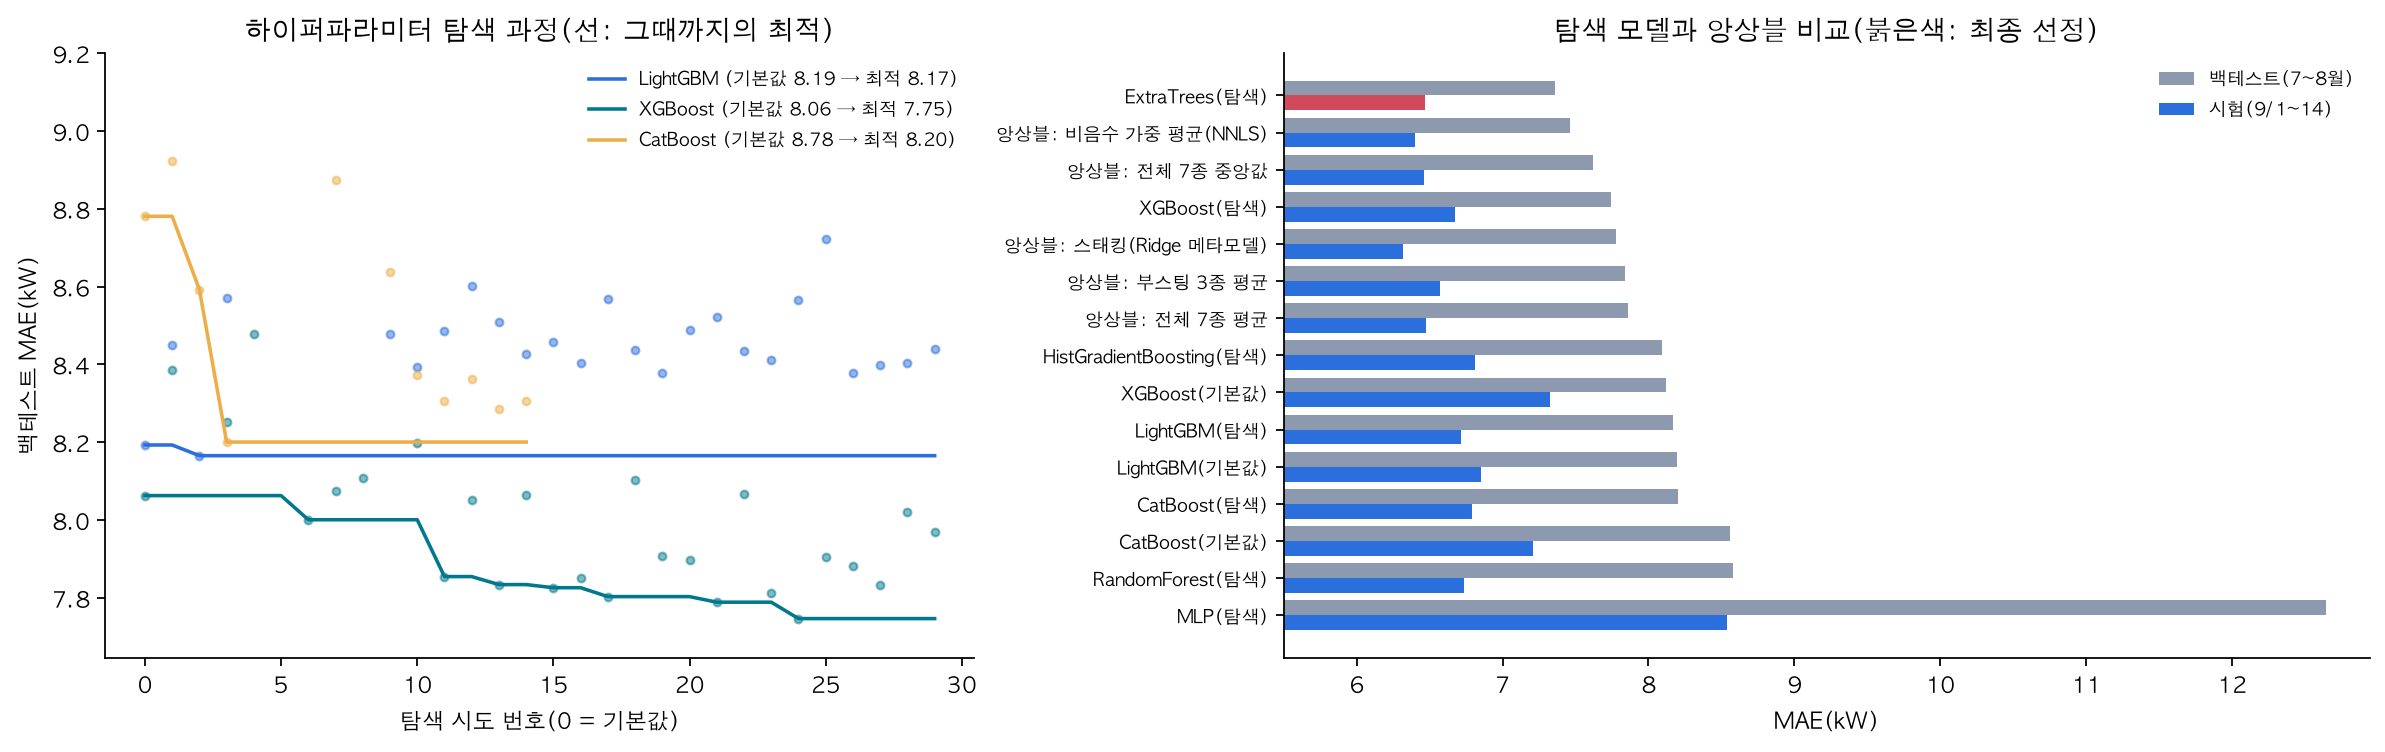

비음수 가중 평균의 가중치:


,LightGBM,XGBoost,CatBoost,RandomForest,ExtraTrees,HistGradientBoosting,MLP
가중치,0.00,0.00,0.21,0.00,0.75,0.03,0.01


최종 전력량 예측 모델: ExtraTrees(탐색) | 구성: ['ExtraTrees']


In [34]:
display(TRES)
fig(S1 / "tuning_and_ensemble.png", 1200)
print("비음수 가중 평균의 가중치:"); display(table(S1 / "ensemble_weights.csv", index_col=0).T)
print("최종 전력량 예측 모델:", final["name"], "| 구성:", final["members"])

**선정 규칙: Valid MAE가 가장 낮은 후보를 최종 모델로 한다(시험 성적은 선정에 쓰지 않음). → 최종 모델: ExtraTrees(탐색 설정).**
- Valid MAE가 7.36kW로 15개 후보 중 가장 낮고, 구간별 MAE 표준편차도 1.06kW로 가장 작아 구간에 따른 흔들림이 적습니다. 8개 구간 중 6개에서 LightGBM(8.19kW)보다 좋습니다.
- 시험 구간 MAE는 6.47kW로 LightGBM(6.85kW)보다 5.5% 낮습니다. 앙상블들의 시험 MAE(6.32~6.57kW)와는 사실상 같은 수준입니다.
- 앙상블 중에서는 비음수 가중 평균(7.46kW)이 가장 좋았는데, 가중치의 75%가 ExtraTrees에 몰려 사실상 같은 모델입니다. 7종 중앙값(7.62kW)과 평균(7.86kW)은 성능이 낮은 모델(MLP, RandomForest)에 끌려 내려갑니다.
- 스태킹은 시험에서 가장 좋았지만(6.32kW) Valid에서는 7.78kW로 낮습니다. 시험 성적으로 고르면 과적합이므로 선정 규칙을 그대로 지켰습니다.
- ExtraTrees 한 개 모델이라 학습이 25초로 빠르고 운영이 단순합니다.

### 1.6 시험 구간 결과

최종 모델을 9월 1일 이전 전체로 다시 학습한 뒤 시험 구간을 한 번 예측합니다. 이 셀에서 분위수 예측, 구간 보정, 일 최대 예측, 피크 발생 확률까지 함께 계산하고 예측 결과 파일을 저장합니다.

,MAE,RMSE,CV(RMSE)%,NMAE%,Bias,MAE(생산시간),DailyPeak_MAE(가동일)
최종: ExtraTrees(탐색),6.47,8.91,8.71,6.32,-1.47,8.08,14.70
LightGBM(기본값),6.85,9.33,9.12,6.69,0.24,8.27,13.08
CatBoost(기본값),7.21,9.65,9.43,7.04,0.70,8.50,13.32
"앙상블(LightGBM+CatBoost, 기본값)",6.95,9.38,9.16,6.79,0.47,8.30,13.61
B1 Naive(지난주 동시각),11.52,21.43,20.94,11.26,4.50,9.89,7.30
B2 규칙(직전 가동일 프로파일),19.56,34.50,33.71,19.11,5.49,14.68,7.10
RandomForest(가이드북 모델),6.93,9.61,9.39,6.77,-1.19,8.16,15.53


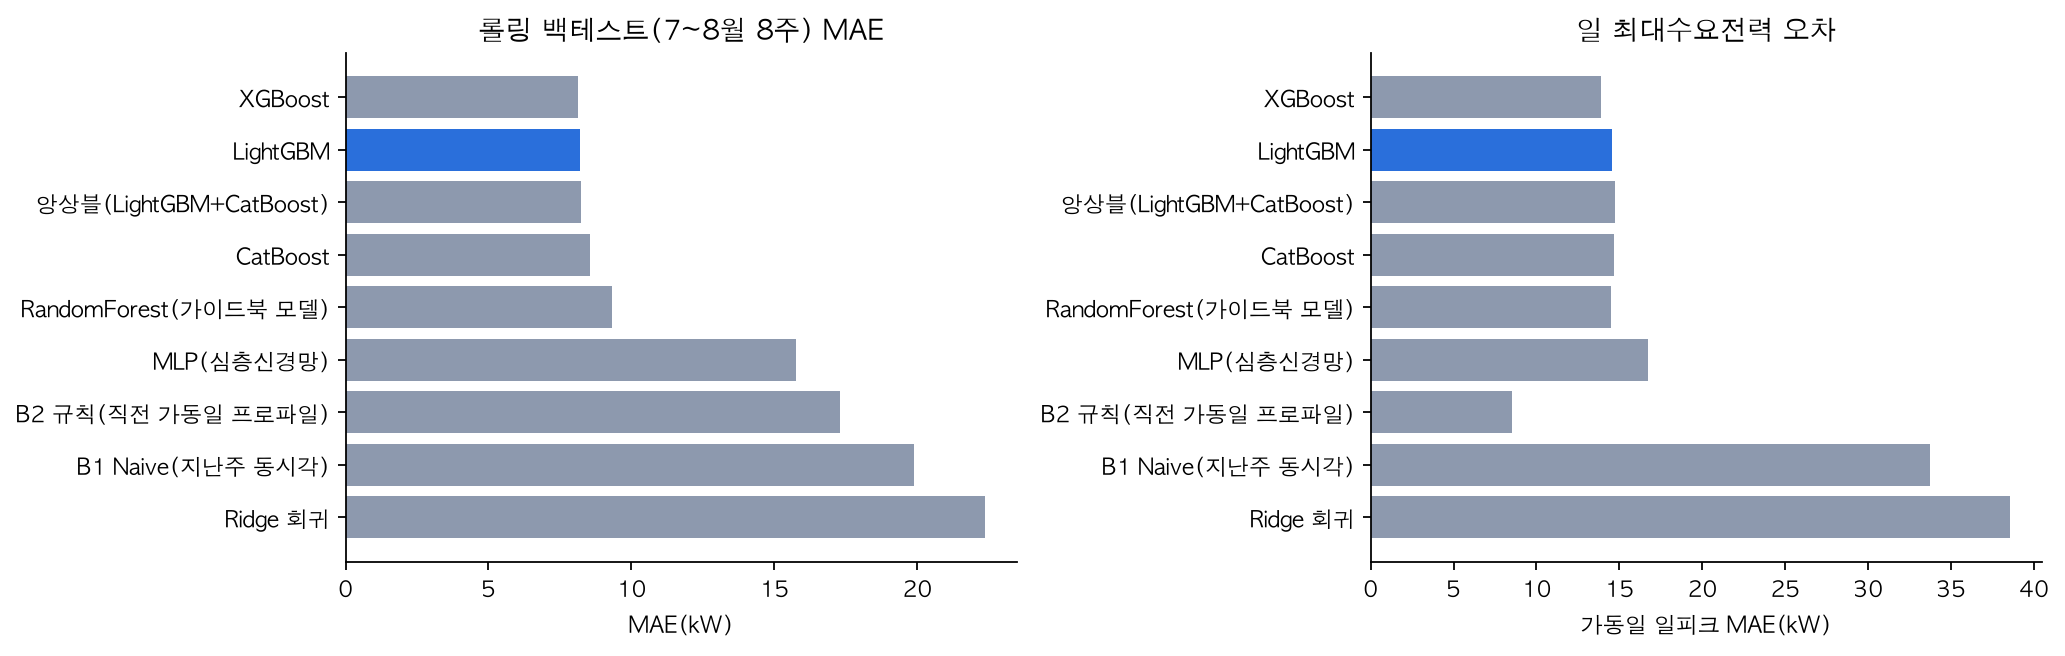

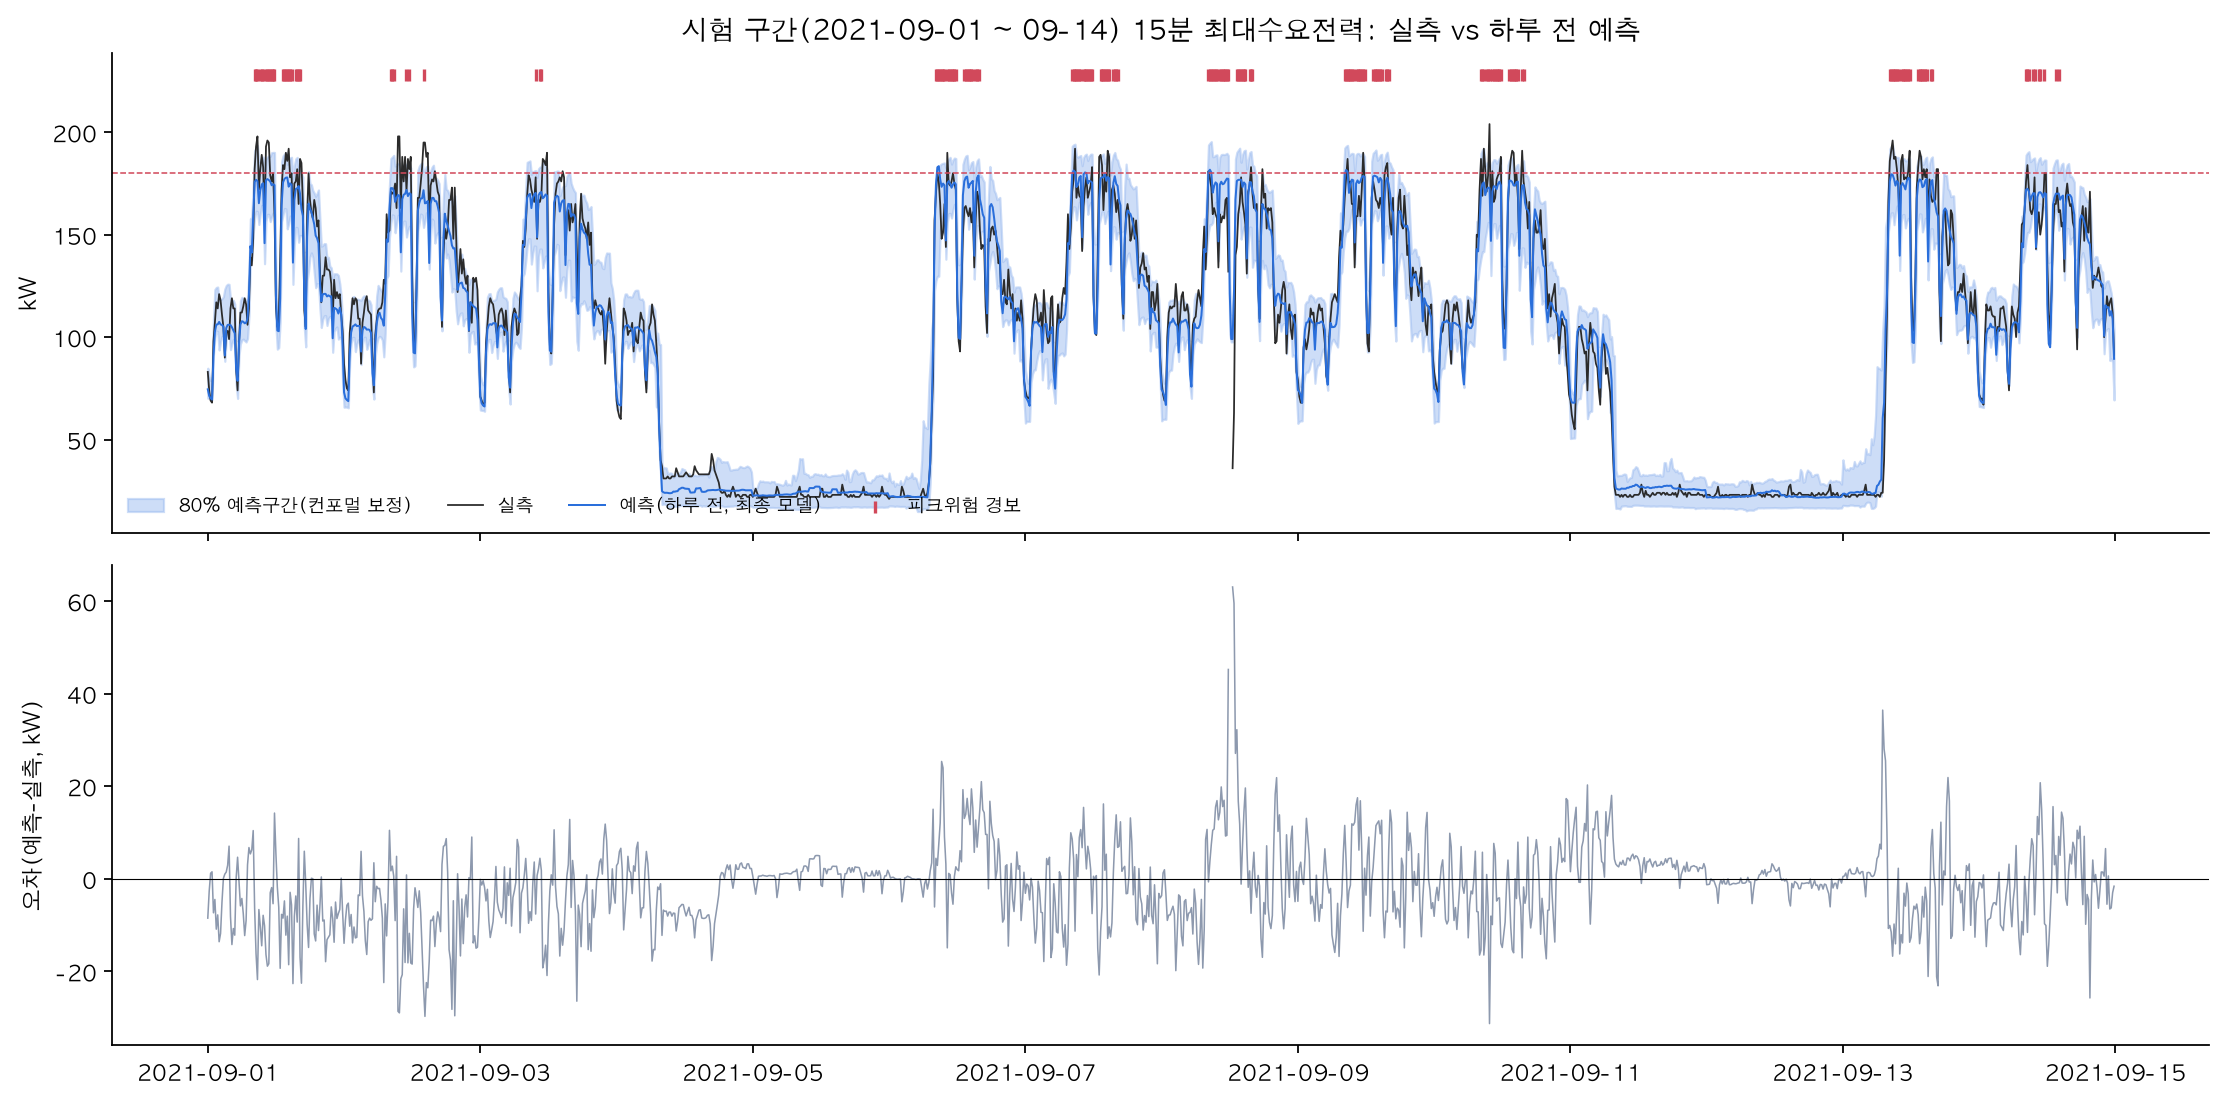

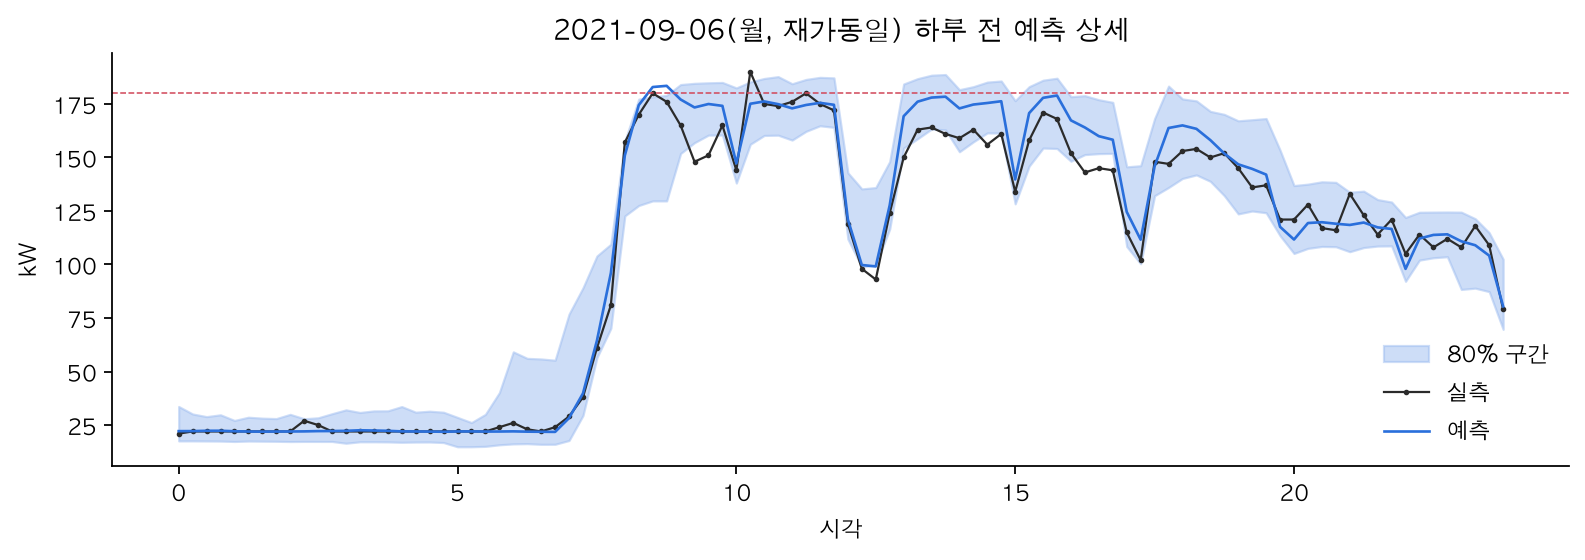

In [35]:
Xte, cvq, dp, dcv, T, DP, imp, pairs, info, model = step_final(XD, oos, final)
Xte, cvq, PT, CAL, top, pinfo = step_probability(XD, oos, Xte, cvq)     # 피크 발생 확률(1.8절에서 설명)
step_save_predictions(Xte, dp); step_plots(Xte, R, dp)
display(T[["MAE", "RMSE", "CV(RMSE)%", "NMAE%", "Bias", "MAE(생산시간)", "DailyPeak_MAE(가동일)"]])
fig(S1 / "model_comparison.png", 900)   # 1.2절 모델 비교 요약 그림
fig(S1 / "test_forecast.png"); fig(S1 / "test_forecast_day.png", 900)

시험 MAE 6.47kW, RMSE 8.91kW, CV(RMSE) 8.7%입니다. 베이스라인 1(11.52kW)보다 44% 낮습니다. 가장 큰 오차는 9월 8일 12시 계측 누락 직후의 재기동 구간입니다.

### 1.7 일 최대 전용 예측과 예측구간

**일 최대 예측.** 15분 예측의 최댓값은 실제 일 최대보다 약 15kW 낮습니다. 일 단위 모델과 "직전 가동일 최대값" 규칙을 반반 섞으면 오차가 가장 작습니다.

구간,CV(7~8월),시험(9/1~14)
방법,,
15분 예측의 일 최대값(최종 모델),14.65,14.70
P90 분위수의 일 최대값,9.87,6.72
규칙(직전 가동일 최대값),8.55,7.10
일 단위 LightGBM,10.67,7.94
피크 앙상블(제안),8.04,5.82


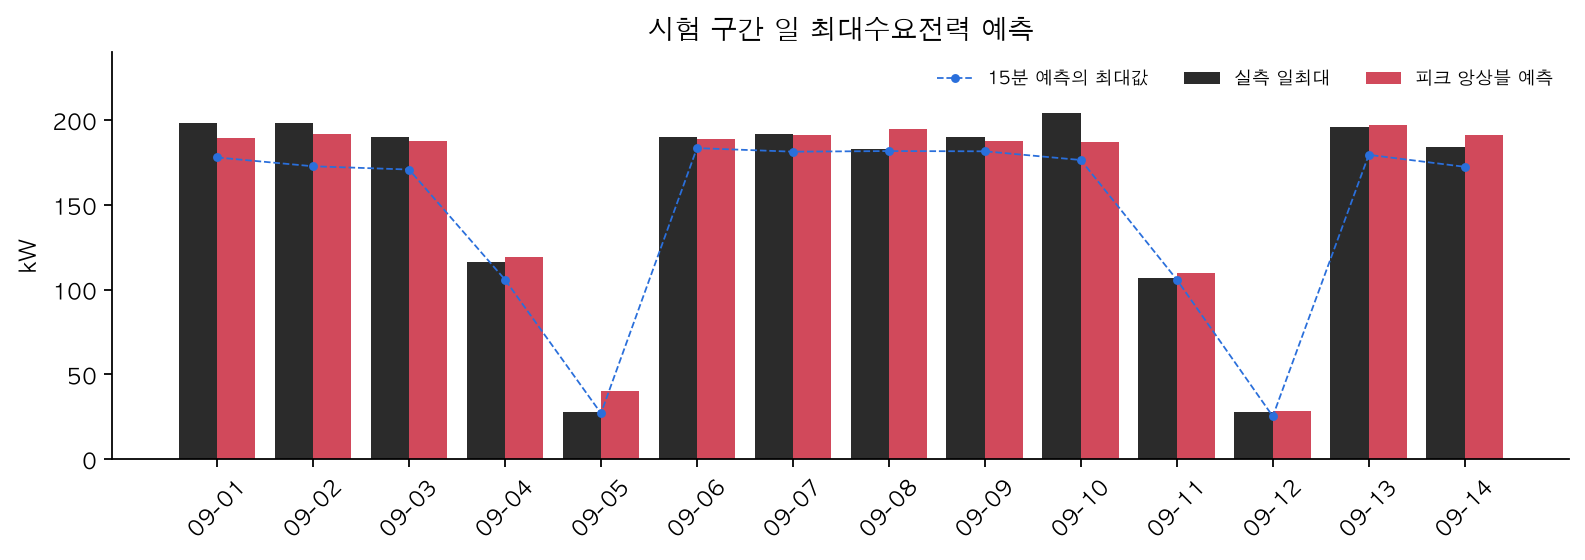

In [36]:
display(DP.pivot(index="방법", columns="구간", values="MAE(가동일)"))
fig(S1 / "test_daily_peak.png", 900)

**예측구간(불확실성 추정).** P10~P90 구간이 Valid에서 실측을 얼마나 포함했는지 확인하고, 부족한 만큼 Valid 잔차로 폭을 넓혔습니다(컨포멀 보정).

In [37]:
print(f"구간 보정 폭: ±{info['conformal_margin_kW']:.2f}kW")
print(f"80% 구간 실제 포함률 — Valid 보정 전 {info['cv_coverage_raw_q10_q90']:.1%} | 시험 보정 전 {info['test_coverage_raw']:.1%} → 보정 후 {info['test_coverage_conformal']:.1%}")
day0 = Xte[Xte["date"] == "2021-09-07"]
print("예시(09-07 오전): 예측과 보정된 80% 구간"); display(day0[day0["hour"].between(7, 9)][["ts", "kw", "pred", "lo80", "hi80"]].set_index("ts").T)

구간 보정 폭: ±3.38kW
80% 구간 실제 포함률 — Valid 보정 전 61.8% | 시험 보정 전 74.7% → 보정 후 85.7%
예시(09-07 오전): 예측과 보정된 80% 구간


ts,2021-09-07 07:00:00,2021-09-07 07:15:00,2021-09-07 07:30:00,2021-09-07 07:45:00,2021-09-07 08:00:00,2021-09-07 08:15:00,2021-09-07 08:30:00,2021-09-07 08:45:00,2021-09-07 09:00:00,2021-09-07 09:15:00,2021-09-07 09:30:00,2021-09-07 09:45:00
kw,121.00,137.00,160.00,143.00,153.00,171.00,177.00,192.00,168.00,174.00,169.00,168.00
pred,111.11,118.33,145.86,145.32,162.96,179.59,181.35,180.70,173.26,174.47,177.93,178.65
lo80,91.68,103.15,129.67,131.77,152.65,160.11,163.66,163.45,157.21,161.92,165.88,165.61
hi80,116.43,130.00,156.12,156.77,175.13,193.20,193.87,194.18,188.48,187.80,188.32,188.68


### 1.8 피크 발생 확률 예측(불균형 학습, 확률보정)

전력량 예측과 별도로, 15분 슬롯마다 **"180kW 이상이 될 확률"** 을 직접 예측하는 모델을 만들었습니다. 피크는 전체의 5%뿐인 불균형 문제입니다.

- **비교 모델:** 베이스라인 2종, 전력량 예측값에 기준선을 긋는 방식, 로지스틱 회귀(불균형 가중), LightGBM 분류(가중 없음 / 불균형 가중)
- **불균형 학습:** 피크 슬롯에 비피크 대비 비율만큼 가중치를 줌
- **확률보정:** Valid의 표본 외 확률에 등위 회귀를 맞춰, 예측 확률이 실제 발생 비율과 같아지게 함
- **판정 기준:** Valid에서 F1이 최대인 확률 기준을 정해 시험에 그대로 적용

F1                PR-AUC           
구간                                    백테스트(7~8월) 시험(9/1~14) 백테스트(7~8월) 시험(9/1~14)
모델                         판정 기준                                                 
LightGBM 분류                확률 0.13 이상       0.66       0.45       0.62       0.36
LightGBM 분류 + 확률보정         확률 0.31 이상       0.66       0.44       0.61       0.33
LightGBM 분류(불균형 가중)        확률 0.28 이상       0.64       0.48       0.59       0.32
LightGBM 분류(불균형 가중) + 확률보정 확률 0.28 이상       0.65       0.48       0.59       0.34
로지스틱 회귀(불균형 가중)            확률 0.65 이상       0.60       0.43       0.56       0.33
로지스틱 회귀(불균형 가중) + 확률보정     확률 0.23 이상       0.60       0.43       0.56       0.32
베이스라인1 지난주 같은 시각           180kW 이상         0.50       0.37       0.48       0.31
베이스라인2 직전 가동일 프로파일         180kW 이상         0.63       0.39       0.69       0.33
전력량 예측값 기준(회귀)             170kW 이상         0.69       0.46       0.66       0.36

,판정 기준,F1,정밀도,재현율,PR-AUC,ROC-AUC,Brier
모델,,,,,,,
베이스라인1 지난주 같은 시각,180kW 이상,0.37,0.35,0.39,0.31,0.92,NaN
베이스라인2 직전 가동일 프로파일,180kW 이상,0.39,0.38,0.40,0.33,0.92,NaN
전력량 예측값 기준(회귀),170kW 이상,0.46,0.34,0.72,0.36,0.93,NaN
로지스틱 회귀(불균형 가중),확률 0.65 이상,0.43,0.34,0.59,0.33,0.92,0.08
로지스틱 회귀(불균형 가중) + 확률보정,확률 0.23 이상,0.43,0.34,0.57,0.32,0.92,0.05
LightGBM 분류,확률 0.13 이상,0.45,0.34,0.67,0.36,0.93,0.05
LightGBM 분류 + 확률보정,확률 0.31 이상,0.44,0.32,0.68,0.33,0.93,0.05
LightGBM 분류(불균형 가중),확률 0.28 이상,0.48,0.33,0.92,0.32,0.93,0.07
LightGBM 분류(불균형 가중) + 확률보정,확률 0.28 이상,0.48,0.33,0.92,0.34,0.93,0.05


최종 확률 모델: LightGBM 분류 + 확률보정 | 판정 기준: 확률 0.31 이상
경보 규칙(Valid F1이 높은 쪽 자동 선택): 전력량 예측값 170kW 이상 | Valid F1 0.69 → 시험 F1 0.46
Valid F1 0.66 → 시험 F1 0.44 | 시험 Brier: 보정 전 0.049 → 보정 후 0.047


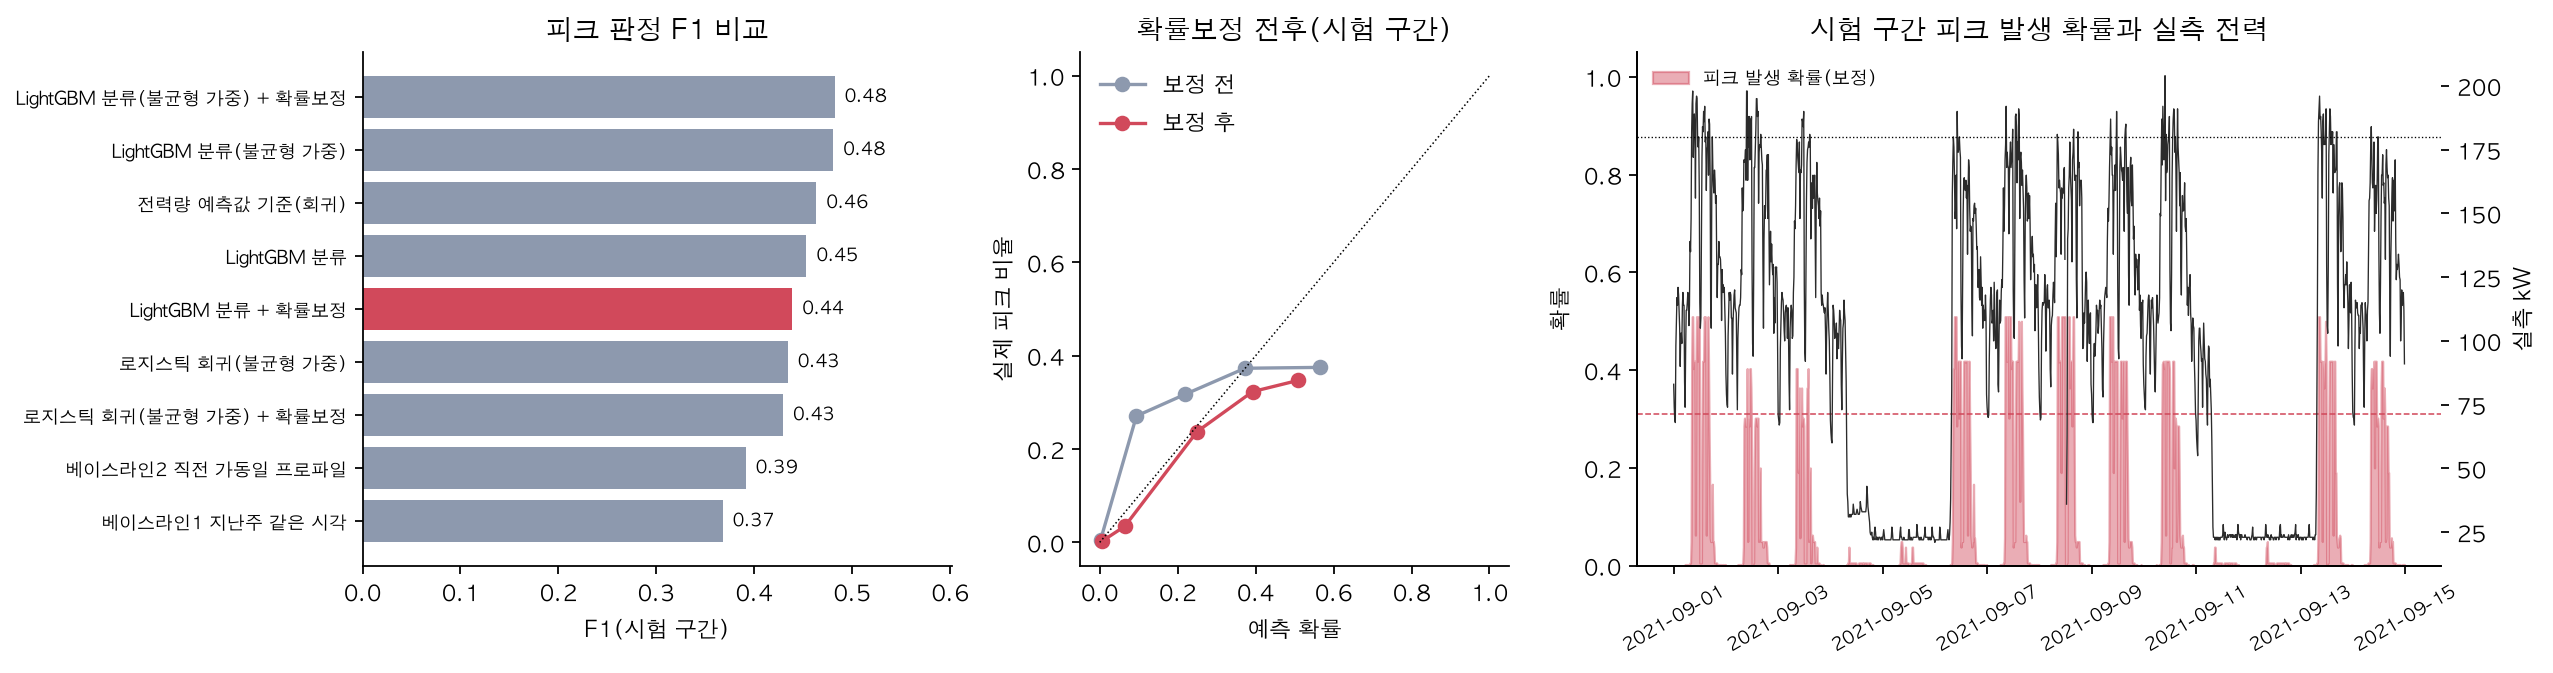

▶ 확률보정 전후: 예측 확률 구간별 실제 피크 비율(시험)


슬롯 수          평균 예측 확률      실제 피크 비율     
구분            보정 전     보정 후     보정 전 보정 후     보정 전 보정 후
예측 확률 구간                                               
0.00~0.05 1,086.00 1,044.00     0.00 0.01     0.01 0.00
0.05~0.15    96.00    29.00     0.09 0.06     0.27 0.03
0.15~0.30    85.00    59.00     0.22 0.25     0.32 0.24
0.30~0.50    67.00   161.00     0.37 0.39     0.37 0.32
0.50~0.70     8.00    49.00     0.56 0.51     0.38 0.35

In [38]:
show = PT.pivot_table(index=["모델", "판정 기준"], columns="구간", values=["F1", "PR-AUC"]).round(3)
display(show)
display(PT[PT["구간"] == "시험(9/1~14)"].set_index("모델")[["판정 기준", "F1", "정밀도", "재현율", "PR-AUC", "ROC-AUC", "Brier"]])
print("최종 확률 모델:", pinfo["final_prob_model"], "| 판정 기준: 확률", pinfo["prob_threshold"], "이상")
print("경보 규칙(Valid F1이 높은 쪽 자동 선택):", pinfo["alert_rule"], f"| Valid F1 {pinfo['alert_rule_cv_F1']:.2f} → 시험 F1 {pinfo['alert_rule_test_F1']:.2f}")
print(f"Valid F1 {pinfo['cv_F1']:.2f} → 시험 F1 {pinfo['test_F1']:.2f} | 시험 Brier: 보정 전 {pinfo['test_Brier_raw']:.3f} → 보정 후 {pinfo['test_Brier_calibrated']:.3f}")
fig(S1 / "peak_probability.png", 1200)
print("▶ 확률보정 전후: 예측 확률 구간별 실제 피크 비율(시험)"); display(CAL.pivot(index="예측 확률 구간", columns="구분", values=["슬롯 수", "평균 예측 확률", "실제 피크 비율"]))

- **확률 모델: LightGBM 분류 + 확률보정.** 확률을 내는 세 모델 중 Valid PR-AUC(0.62)가 가장 높습니다. Valid F1 0.66, 시험 F1 0.44입니다(베이스라인 시험 F1 0.37, 0.39).
- **경보는 더 단순한 방식이 낫습니다.** "전력량 예측값이 170kW 이상이면 경보"가 Valid F1 0.69, 시험 F1 0.46으로 확률 모델보다 높습니다. 그래서 경보 규칙은 Valid F1이 높은 쪽을 자동으로 고르게 했고, 지금은 전력량 예측값 기준입니다.
- **불균형 가중의 효과:** LightGBM에 가중을 주면 재현율은 0.92로 오르지만 헛경보가 늘어 정밀도가 0.33에 그칩니다. 놓치면 안 되는 정도에 맞춰 써야 합니다.
- **확률보정 효과:** 보정 전에는 확률 0.05~0.15라고 한 슬롯의 실제 피크 비율이 27%로, 위험을 낮게 말하고 있었습니다. 보정 후에는 예측 확률과 실제 비율의 차이가 줄었습니다(Brier 0.049 → 0.047). 개선 폭은 크지 않습니다.

시험 F1이 0.44~0.48에 그치는 것은 15분 단위로 피크 여부를 맞히는 문제 자체가 어렵기 때문입니다. 그래서 운영에서는 15분 경보보다 1.7절의 일 최대 예측(오차 5.8kW)을 주된 판단 기준으로 씁니다.

이후의 경보, 놓친 피크·헛경보 분석은 Valid F1이 가장 높은 규칙(전력량 예측값 170kW 이상이면 경보)을 기준으로 하고, 확률 모델은 위험도 순위와 점검 우선순위에 씁니다.

**점검 우선순위로 활용.** 날짜별로 피크 확률이 높은 시간대를 뽑으면 다음 날 어느 시간을 먼저 챙길지 정할 수 있습니다(시험 구간 예시).

In [39]:
display(top.head(12))

,날짜,시각,피크 확률(시간 내 최대)
8,2021-09-01,8,0.51
10,2021-09-01,10,0.51
11,2021-09-01,11,0.51
33,2021-09-02,9,0.40
35,2021-09-02,11,0.40
32,2021-09-02,8,0.30
56,2021-09-03,8,0.40
61,2021-09-03,13,0.40
57,2021-09-03,9,0.36
129,2021-09-06,9,0.51


### 1.9 주요 영향변수와 상호작용

설명이 쉬운 LightGBM으로 영향변수를 봅니다. 최종 모델인 ExtraTrees와 같은 입력을 쓰는 나무 모델이라 경향은 같습니다.

SHAP 값으로 본 영향변수와 변수 간 상호작용입니다.

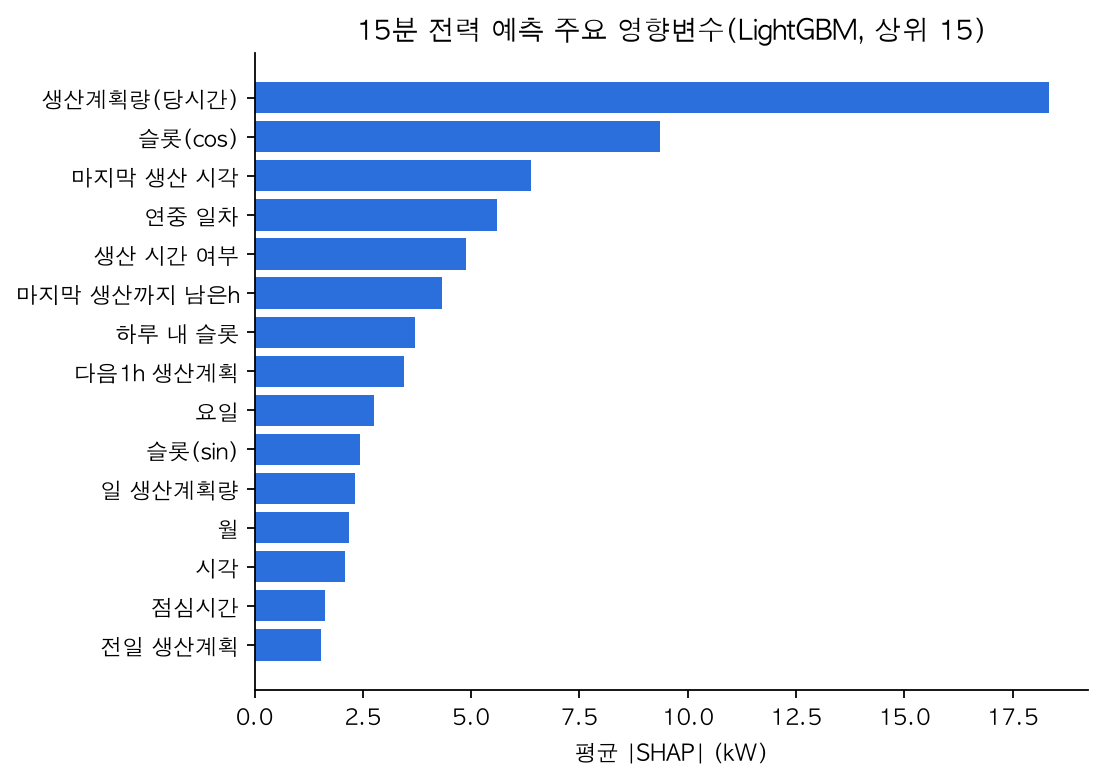

,변수 쌍,평균 상호작용(kW)
0,생산계획량(당시간) x 마지막 생산 시각,2.35
1,슬롯(cos) x 생산계획량(당시간),1.76
2,마지막 생산까지 남은h x 마지막 생산 시각,1.58
3,월 x 연중 일차,1.42
4,연중 일차 x 생산계획량(당시간),1.41
5,생산계획량(당시간) x 마지막 생산까지 남은h,1.23
6,월 x 마지막 생산 시각,0.96
7,하루 내 슬롯 x 마지막 생산 시각,0.93
8,슬롯(cos) x 마지막 생산 시각,0.80
9,연중 일차 x 마지막 생산까지 남은h,0.79


In [40]:
fig(S1 / "forecast_shap_importance.png", 700)
display(table(S1 / "forecast_shap_interactions.csv").set_axis(["변수 쌍", "평균 상호작용(kW)"], axis=1))

당시간 생산계획량이 가장 크고, 같은 생산량이라도 **그날 생산이 저녁까지 이어지는지(마지막 생산 시각)** 와 **몇 시인지**에 따라 전력이 달라집니다.

---
## 2단계. 예측오차 분석

분석 대상은 모델이 보지 못한 10주(Valid 8주 + Test 2주, 6,454슬롯)의 예측입니다.
피크 유형별 오차는 유형을 구분한 뒤 4단계 끝에서 이어서 봅니다.

**함수 정의 — 의사결정나무를 규칙표로 바꾸는 함수**

In [41]:
def tree_rules(tree, feat_names, X, y, w=None):
    t = tree.tree_
    leaves = tree.apply(X)
    w = np.ones(len(y)) if w is None else np.asarray(w)
    paths = {}

    def rec(node, conds):
        if t.children_left[node] == -1:
            paths[node] = conds
            return
        f, th = feat_names[t.feature[node]], t.threshold[node]
        rec(t.children_left[node], conds + [f"{f} <= {th:.1f}"])
        rec(t.children_right[node], conds + [f"{f} > {th:.1f}"])

    rec(0, [])
    rows = []
    y = np.asarray(y, float)
    for leaf, conds in paths.items():
        m = leaves == leaf
        rows.append({"조건": " & ".join(conds), "표본수": int(m.sum()),
                     "가중평균": float(np.sum(y[m] * w[m]) / np.sum(w[m])) if m.any() else np.nan})
    return pd.DataFrame(rows).sort_values("가중평균", ascending=False).reset_index(drop=True)


def fit_rules(X, y, feats, names, w=None, depth=3, min_leaf=150, classifier=True):
    Est = DecisionTreeClassifier if classifier else DecisionTreeRegressor
    tr = Est(max_depth=depth, min_samples_leaf=min_leaf, random_state=0)
    tr.fit(X[feats], y, sample_weight=w)
    return tree_rules(tr, names, X[feats], y, w)

**함수 정의 — 조건별 오차, 피크 시간 MAE, 놓친 피크·헛경보**

In [42]:
def add_conditions(df):
    d = df.copy()
    d["err"] = d["pred"] - d["kw"]
    d["abs_err"] = d["err"].abs()
    d["prod_bin"] = pd.cut(d["prod"], [-1, 0, 300, 1000, 2000, 1e9], labels=["0", "1-300", "300-1천", "1천-2천", "2천+"])
    d["temp_bin"] = pd.cut(d["temp"], [-20, 15, 22, 26, 40], labels=["<15", "15-22", "22-26", "26+"])
    d["phase"] = np.where(d["full_workday"] == 0, "비가동일", d["hour"].map(clock_state))
    return d


def group_table(d, col):
    g = d.groupby(col, observed=True)
    t = pd.DataFrame({"표본수": g.size(), "MAE": g["abs_err"].mean(), "RMSE": g["err"].apply(lambda e: np.sqrt(np.mean(e ** 2))),
                      "Bias": g["err"].mean(), "평균부하": g["kw"].mean()})
    t["오차 기여%"] = 100 * g["abs_err"].sum() / d["abs_err"].sum()
    return t.round(2)


def error_run(oos: pd.DataFrame, tag="oos"):
    d = add_conditions(oos.dropna(subset=["kw"]).reset_index(drop=True))
    tables = {}
    for col, name in [("phase", "운영상태"), ("hour", "시각"), ("prod_bin", "생산계획량"), ("temp_bin", "기온"),
                      ("restart_day", "재가동일"), ("dow", "요일")]:
        t = group_table(d, col)
        t.index.name = name
        t.to_csv(S2 / f"error_by_{col}_{tag}.csv", encoding="utf-8-sig")
        tables[col] = t

    # 피크 시간 MAE vs 전체 MAE (피크 구간 유형은 pipeline.step_error에서 슬롯에 붙임)
    if True:
        segs = [("전체", d), ("정상 가동일 08~17시", d[(d["full_workday"] == 1) & d["hour"].between(8, 16)]),
                ("피크 시간(실측 180kW 이상)", d[d["kw"] >= PEAK_EVENT_KW]), ("피크 아닌 시간", d[d["kw"] < PEAK_EVENT_KW])]
        if "peak_type" in d:      # 4단계의 피크 유형이 슬롯에 붙어 있으면 유형별 오차도 함께 계산
            segs += [("유형1 피크 구간(시작·재개 직후)", d[d["peak_type"] == 1]), ("유형2 피크 구간(가동 중)", d[d["peak_type"] == 2])]
        pk = pd.DataFrame([{"구간": n, "슬롯 수": len(x), "MAE": x["abs_err"].mean(), "RMSE": np.sqrt((x["err"] ** 2).mean()),
                            "Bias(예측-실측)": x["err"].mean(), "평균 실측(kW)": x["kw"].mean(),
                            "MAE/평균 실측 %": 100 * x["abs_err"].mean() / x["kw"].mean()} for n, x in segs])
        pk.round(2).to_csv(S2 / f"peak_time_mae_vs_overall_{tag}.csv", index=False, encoding="utf-8-sig")
        tables["peak_vs_overall"] = pk

    # 큰 오차(상위 10%) 규칙 추출
    thr = d["abs_err"].quantile(0.9)
    d["big_err"] = (d["abs_err"] >= thr).astype(int)
    feats = ["hour", "prod", "temp", "restart_day", "quarter", "day_prod"]
    names = ["시각", "생산계획량", "기온", "재가동일", "15분구간", "일생산계획"]
    dd = d.copy()
    rules = fit_rules(dd, dd["big_err"].values, feats, names, depth=3, min_leaf=60)
    rules = rules.rename(columns={"가중평균": "큰오차 비율"})
    rules["큰오차 비율"] = (rules["큰오차 비율"] * 100).round(1)
    rules.to_csv(S2 / f"error_rules_{tag}.csv", index=False, encoding="utf-8-sig")
    tables["rules"] = rules
    tables["big_err_threshold"] = thr

    # 피크위험 이벤트 FN / FP
    d["ev_true"] = (d["kw"] >= PEAK_EVENT_KW).astype(int)
    pcol = "pred_alert" if "pred_alert" in d else "pred"
    d["ev_pred"] = (d[pcol] >= PEAK_EVENT_KW).astype(int)
    d["cm"] = np.select([(d.ev_true == 1) & (d.ev_pred == 0), (d.ev_true == 0) & (d.ev_pred == 1),
                         (d.ev_true == 1) & (d.ev_pred == 1)], ["FN", "FP", "TP"], "TN")
    cm_phase = pd.crosstab(d["phase"], d["cm"])
    cm_hour = pd.crosstab(d["hour"], d["cm"])
    cm_temp = pd.crosstab(d["temp_bin"], d["cm"])
    cm_quarter = pd.crosstab([d["hour"].where(d["hour"].isin([8, 9, 13, 14]), -1), d["quarter"]], d["cm"])
    for k, v in [("phase", cm_phase), ("hour", cm_hour), ("temp", cm_temp), ("quarter", cm_quarter)]:
        v.to_csv(S2 / f"event_cm_by_{k}_{tag}.csv", encoding="utf-8-sig")
        tables[f"cm_{k}"] = v

    # 그림: 시각 x 요일 MAE 히트맵 + 운전구간별 MAE/기여도
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [1.5, 1]})
    hm = d.pivot_table(index="dow", columns="hour", values="abs_err", aggfunc="mean")
    im = ax[0].imshow(hm.values, aspect="auto", cmap="Reds")
    ax[0].set_yticks(range(len(hm.index)), ["월화수목금토일"[i - 1] for i in hm.index])
    ax[0].set_xticks(range(0, 24, 2), range(0, 24, 2))
    ax[0].set(xlabel="시각", title="시각 x 요일별 평균 절대오차(kW)")
    plt.colorbar(im, ax=ax[0])
    t = tables["phase"].sort_values("MAE")
    ax[1].barh(t.index, t["MAE"], color=C["pred"])
    for i, (m, s) in enumerate(zip(t["MAE"], t["오차 기여%"])):
        ax[1].text(m + 0.3, i, f"기여 {s:.0f}%", va="center", fontsize=8)
    ax[1].set(xlabel="MAE(kW)", title="운영상태별 오차")
    save(fig, S2 / f"error_heatmap_{tag}.png")
    return d, tables

In [43]:
oos_all = pd.concat([cvq, Xte])
err, et = error_run(oos_all, "oos")
print("표본 외 슬롯 수:", len(err))

표본 외 슬롯 수: 6454


### 2.1 피크 시간 MAE 대 전체 MAE

In [44]:
display(et["peak_vs_overall"])

,구간,슬롯 수,MAE,RMSE,Bias(예측-실측),평균 실측(kW),MAE/평균 실측 %
0,전체,6454,7.18,10.50,-0.77,102.33,7.01
1,정상 가동일 08~17시,1726,10.99,13.98,-1.58,168.23,6.53
2,피크 시간(실측 180kW 이상),678,12.54,15.91,-11.34,189.81,6.61
3,피크 아닌 시간,5776,6.55,9.67,0.47,92.06,7.11


피크 시간의 MAE는 전체의 약 1.7배이고, 편향이 약 −11kW로 **거의 전부 낮게 예측**합니다.
그래서 피크는 15분 예측 그대로 쓰지 않고, 1.7절의 일 최대 전용 예측과 1.8절의 피크 확률 모델로 보완했습니다.

### 2.2 시간대·생산조건·가동상태별 오차

▶ 운영상태


,표본수,MAE,RMSE,Bias,평균부하,오차 기여%
운영상태,,,,,,
비가동일,1848,3.05,4.82,0.20,33.90,12.16
새벽(0~7시),1344,5.68,7.58,-0.77,83.89,16.48
오전 가동 시작(7~9시),384,10.48,13.67,-1.35,148.92,8.69
오전 가동 중(9~12시),576,10.84,13.53,-1.48,178.40,13.48
오후 가동 중(14~17시),576,11.62,14.79,-2.05,170.59,14.45
저녁·야간(17시~),1344,9.07,12.76,-1.11,128.04,26.33
점심 정지·재개(12~14시),382,10.19,13.47,-0.64,143.40,8.40


▶ 시간 생산계획량


,표본수,MAE,RMSE,Bias,평균부하,오차 기여%
생산계획량,,,,,,
0,2112,3.28,6.57,-0.17,32.85,14.97
1-300,1702,7.64,10.59,-0.10,107.52,28.06
300-1천,1232,8.92,11.54,-1.69,142.89,23.72
1천-2천,964,10.98,13.82,-1.77,165.17,22.85
2천+,444,10.83,13.56,-1.45,163.95,10.38


▶ 기온


,표본수,MAE,RMSE,Bias,평균부하,오차 기여%
기온,,,,,,
15-22,1312,6.11,8.29,-1.27,97.52,17.32
22-26,3414,6.97,10.14,0.43,97.84,51.36
26+,1728,8.39,12.51,-2.76,114.85,31.32


▶ 재가동일 여부


,표본수,MAE,RMSE,Bias,평균부하,오차 기여%
재가동일,,,,,,
0,5494,6.98,10.04,-1.25,101.47,82.79
1,960,8.30,12.84,2.02,107.28,17.21


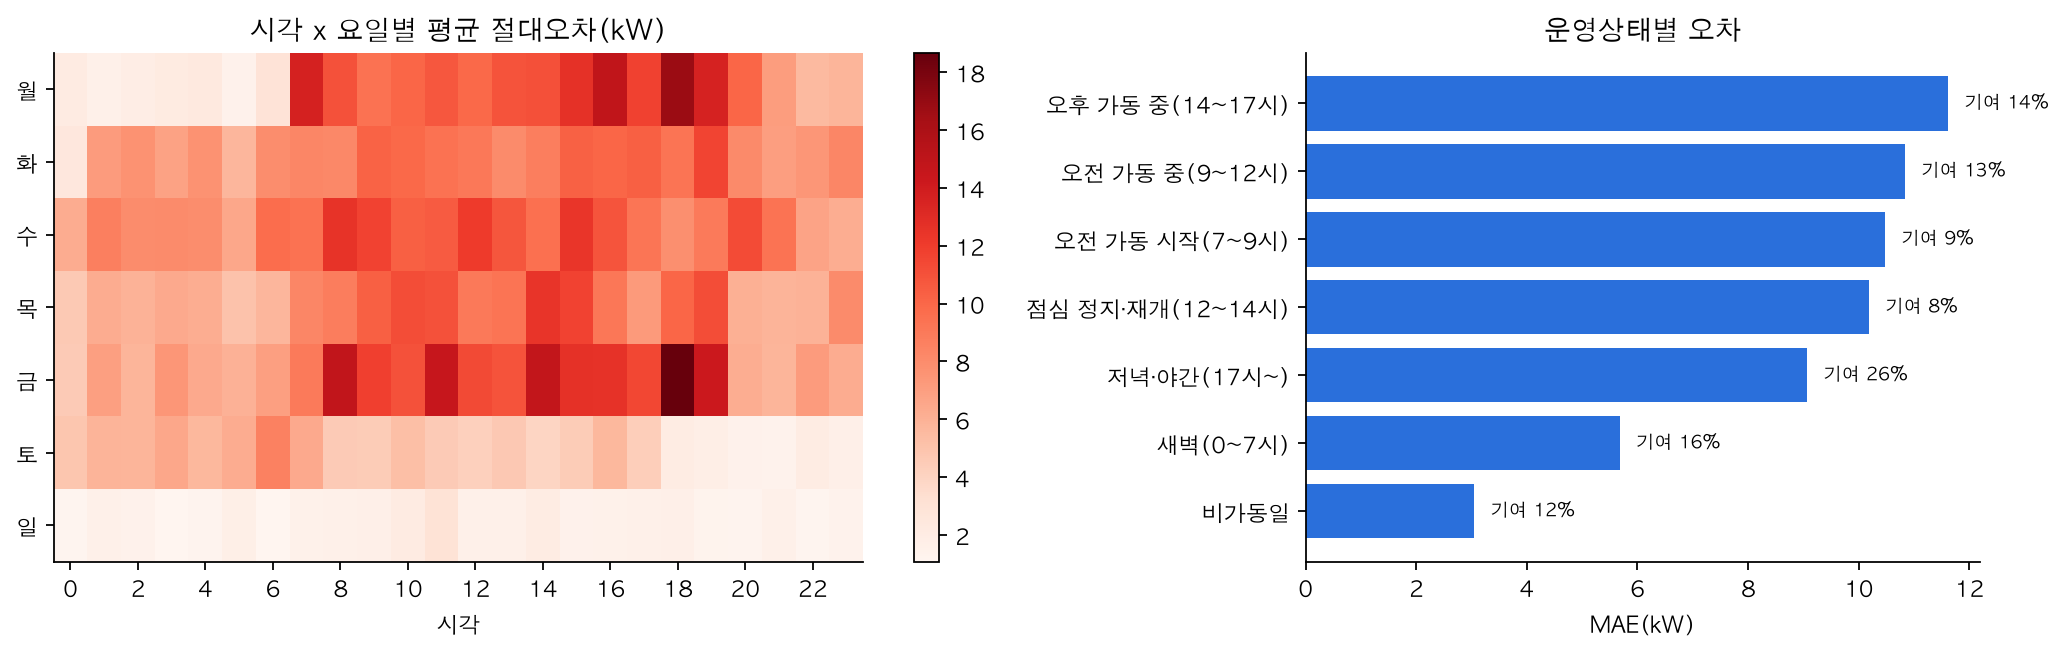

In [45]:
for k, name in [("phase", "운영상태"), ("prod_bin", "시간 생산계획량"), ("temp_bin", "기온"), ("restart_day", "재가동일 여부")]:
    print("▶", name); display(et[k])
fig(S2 / "error_heatmap_oos.png")

- 비가동일·새벽은 오차가 작고, 가동 시간대는 10~12kW입니다.
- **저녁·야간**은 슬롯이 많아 전체 오차의 26%를 차지합니다. 잔업 범위가 생산계획에 덜 드러나기 때문입니다.
- **재가동일**은 +2.0kW 높게, **26℃ 이상**은 −2.8kW 낮게 예측합니다.

### 2.3 큰 오차가 나는 조건

오차 상위 10%에 드는지를 의사결정나무로 설명하고, 가장 위험한 조건에 해당하는 날을 찾아봅니다.

In [46]:
print(f"큰 오차 기준: {et['big_err_threshold']:.1f}kW 이상"); display(et["rules"])
d = err[(err["day_prod"] > 7016) & (err["day_prod"] <= 12766)]
g = d.groupby("date").agg(요일=("dow", "first"), 일생산계획=("day_prod", "first"), 재가동일=("restart_day", "first"),
                          MAE=("abs_err", "mean"), Bias=("err", "mean"), 실측평균=("kw", "mean"), 예측평균=("pred", "mean"))
display(g)

큰 오차 기준: 16.8kW 이상


,조건,표본수,큰오차 비율
0,생산계획량 > 538.5 & 일생산계획 > 24153.5 & 기온 <= 28.4,236,37.30
1,생산계획량 > 538.5 & 일생산계획 <= 24153.5 & 일생산계획 <= 12766.5,152,36.20
2,생산계획량 <= 538.5 & 일생산계획 > 7016.0 & 일생산계획 <= 12766.5,188,28.20
3,생산계획량 > 538.5 & 일생산계획 > 24153.5 & 기온 > 28.4,92,22.80
4,생산계획량 > 538.5 & 일생산계획 <= 24153.5 & 일생산계획 > 12766.5,1604,15.80
5,생산계획량 <= 538.5 & 일생산계획 > 7016.0 & 일생산계획 > 12766.5,2386,6.50
6,생산계획량 <= 538.5 & 일생산계획 <= 7016.0 & 일생산계획 > 1664.0,598,2.70
7,생산계획량 <= 538.5 & 일생산계획 <= 7016.0 & 일생산계획 <= 1664.0,1198,0.30


,요일,일생산계획,재가동일,MAE,Bias,실측평균,예측평균
date,,,,,,,
2021-07-30,5,"12,688.00",0,20.41,-18.51,145.58,127.07
2021-08-16,1,"10,238.00",1,19.06,18.57,91.39,109.96
2021-08-30,1,"10,719.00",1,7.31,1.06,107.77,108.83


큰 오차는 두 경우에 몰립니다. 하나는 **생산이 아주 많은 날**(일 계획 2.4만 개 초과)의 고부하 시간이고, 다른 하나는 **평소보다 계획이 적은 날**(일 계획 1.3만 개 이하)입니다. 뒤쪽의 실체는 특수일입니다. **7월 30일(하계휴가 직전)** 은 계획이 적었지만 설비는 평소처럼 돌아 평균 18.5kW 낮게 예측했고,
**8월 16일(대체공휴일)** 은 부분 가동이라 평균 18.6kW 높게 예측했습니다. 생산계획이 설비 가동을 대표하지 못한 날입니다.
→ ERP에 "설비 가동시간"과 "특수일" 항목을 두면 줄일 수 있는 오차입니다.

### 2.4 놓친 피크와 헛경보

경보(전력량 예측값 170kW 이상)와 실제 피크(실측 180kW 이상)를 비교합니다. FN(False Negative) = 놓친 피크, FP(False Positive) = 헛경보.

In [47]:
cm = et["cm_phase"].copy()
cm["정밀도%"] = 100 * cm["TP"] / (cm["TP"] + cm["FP"]).replace(0, np.nan)
cm["재현율%"] = 100 * cm["TP"] / (cm["TP"] + cm["FN"]).replace(0, np.nan)
display(cm); display(et["cm_temp"])
fn = err[(err["cm"] == "FN") & (err["hour"] >= 17)].groupby("date").agg(놓친슬롯=("kw", "size"), 일최고기온=("temp_max", "first"))
print("저녁에 놓친 피크가 있었던 날:"); display(fn.T)

cm,FN,FP,TN,TP,정밀도%,재현율%
phase,,,,,,
비가동일,0,0,1848,0,NaN,NaN
새벽(0~7시),0,0,1344,0,NaN,NaN
오전 가동 시작(7~9시),9,47,239,89,65.44,90.82
오전 가동 중(9~12시),32,193,86,265,57.86,89.23
오후 가동 중(14~17시),49,168,218,141,45.63,74.21
저녁·야간(17시~),21,8,1312,3,27.27,12.50
점심 정지·재개(12~14시),7,62,251,62,50.00,89.86


cm,FN,FP,TN,TP
temp_bin,,,,
15-22,20,32,1245,15
22-26,43,271,2901,199
26+,55,175,1152,346


저녁에 놓친 피크가 있었던 날:


date,2021-07-19,2021-07-20,2021-07-27,2021-07-28,2021-07-29,2021-07-30,2021-08-11,2021-08-12,2021-08-18,2021-09-01,2021-09-08
놓친슬롯,2.00,1.00,2.00,3.00,2.00,4.00,2.00,1.00,1.00,2.00,1.00
일최고기온,29.80,31.70,30.70,31.00,31.60,33.20,29.40,28.80,24.90,27.90,26.50


- **놓친 피크(FN)** 118건은 오후 가동 중 49건, 오전 가동 중 32건, 저녁 21건에 몰립니다. 비율로는 **저녁**이 가장 나쁩니다(재현율 12%). 저녁 피크는 대부분 7월 하순 고온기의 잔업 시간입니다.
- **헛경보(FP)** 478건은 오전 가동 중 193건, 오후 가동 중 168건에 많습니다. 재현율을 높이려고 기준을 170kW로 낮춘 대가로, 오전에는 재현율 89~91%를 얻는 대신 정밀도가 58~65%입니다.
- 기온별로는 22~26℃에서 헛경보(271건)가, 26℃ 이상에서 놓친 피크(55건)가 가장 많습니다. 더운 날의 냉방 부하를 낮게 예측하는 2.2절의 결과와 같은 방향입니다.
- 개선 방향: 저녁 잔업 계획과 점심 정지 여부를 생산계획에 넣으면 두 구간의 오류를 줄일 수 있습니다.

---
## 3단계. 실제 피크 추출

**정의.** 15분 최대수요전력이 180kW 이상인 **연속 구간**을 피크 구간으로 봅니다. 15분 한 칸만 기준 아래로 내려갔다 다시 넘으면 한 구간으로 합칩니다.

**기준의 근거.** 180kW 이상인 슬롯은 전체 15분 슬롯의 5.0%입니다(상위 5%). 기준을 바꾸면 구간 수가 어떻게 달라지는지 함께 확인했습니다.

**함수 정의 — 피크 구간 추출 · 두 유형 구분 · 유형별 조건(3~5단계 공통)**

In [48]:
TYPE_NAME = {1: "유형1: 가동 시작·재개 직후 크게 오르는 피크", 2: "유형2: 가동 중 잠깐 더 오르는 피크"}
TYPE_SHORT = {1: "유형1(시작·재개 직후)", 2: "유형2(가동 중)"}
TYPE_COLOR = {1: C["peak"], 2: C["pred"]}


def unique_days(X):
    """복사 그룹마다 가장 이른 하루만 남긴 '고유한 날' 집합."""
    d = X.groupby("date")["aug_group"].first().reset_index()
    d["key"] = np.where(d["aug_group"] >= 0, d["aug_group"].astype(str), d["date"].astype(str))
    return set(d.drop_duplicates("key")["date"])


def extract_episodes(X, thr=PEAK_EVENT_KW):
    rows = []
    for d, g in X.groupby("date"):
        g = g.sort_values("slot")
        kw = g["kw"].interpolate(limit=2).values
        if np.isnan(kw).mean() > 0.2:
            continue
        hi = np.nan_to_num(kw) >= thr
        for i in range(1, 95):                      # 15분 한 칸짜리 끊김은 이어 붙임
            if not hi[i] and hi[i - 1] and hi[i + 1]:
                hi[i] = True
        i = 0
        while i < 96:
            if not hi[i]:
                i += 1
                continue
            j = i
            while j + 1 < 96 and hi[j + 1]:
                j += 1
            pre = np.nanmean(kw[max(0, i - 4):i]) if i > 0 else np.nan
            post = np.nanmean(kw[j + 1:j + 5]) if j < 95 else np.nan
            peak = np.nanmax(kw[i:j + 1])
            r = g.iloc[i]
            rows.append({
                "date": d, "start_slot": i, "end_slot": j, "start_hour": i // 4,
                "시작시각": f"{i // 4:02d}:{(i % 4) * 15:02d}", "지속시간(분)": (j - i + 1) * 15, "최대(kW)": peak,
                "직전1시간 평균(kW)": pre, "직후1시간 평균(kW)": post, "상승폭(kW)": peak - pre,
                "직전30분 상승(kW)": kw[i] - kw[max(i - 2, 0)],
                "생산계획량(시작 시간)": r["prod"], "직전 시간 생산계획량": r["prod_lag1h"],
                "생산계획 변화(개/h)": r["prod"] - (r["prod_lag1h"] if pd.notna(r["prod_lag1h"]) else 0),
                "일 생산계획량": r["day_prod"], "재가동일": r["restart_day"], "기온": r["temp"],
                "요일": r["dow"], "월": r["month"], "운영상태": clock_state(i // 4), "복사그룹크기": r["aug_size"],
            })
            i = j + 1
    return pd.DataFrame(rows)


def step3_extract(X):
    """3단계: 피크 구간 추출 + 기준값 근거."""
    y = X["kw"].dropna()
    rows = []
    for thr in (160, 170, 175, 180, 185, 190, 200):
        e = extract_episodes(X, thr)
        rows.append({"기준(kW)": thr, "기준 이상 슬롯 비율%": 100 * (y >= thr).mean(), "피크 구간 수": len(e),
                     "피크 발생일 수": e["date"].nunique() if len(e) else 0,
                     "구간 평균 지속(분)": e["지속시간(분)"].mean() if len(e) else np.nan})
    T = pd.DataFrame(rows)
    T.round(2).to_csv(S3 / "threshold_sensitivity.csv", index=False, encoding="utf-8-sig")
    E = extract_episodes(X, PEAK_EVENT_KW)
    E["고유일"] = E["date"].isin(unique_days(X)).astype(int)
    work_days = X[X["full_workday"] == 1].groupby("date")["kw"].count()
    work_days = set(work_days[work_days >= 77].index)
    summ = pd.Series({
        "기준(kW)": PEAK_EVENT_KW, "기준의 근거": "180kW 이상 슬롯이 전체 15분 슬롯의 5.0%(상위 5%)",
        "전체 피크 구간 수": len(E), "고유일 기준 피크 구간 수": int(E["고유일"].sum()),
        "피크 발생일 수(고유일)": E.loc[E["고유일"] == 1, "date"].nunique(),
        "7~9월 정상 가동일 수": len([d for d in work_days if d >= pd.Timestamp("2021-07-01")]),
        "7~9월 피크 발생일 수": E.loc[E["date"] >= "2021-07-01", "date"].nunique(),
        "구간 지속시간 중앙값(분)": E["지속시간(분)"].median(), "구간 최대값 평균(kW)": round(E["최대(kW)"].mean(), 1),
    }, name="값")
    summ.to_csv(S3 / "peak_extraction_summary.csv", encoding="utf-8-sig")

    # 그림: 7~9월 일 최대와 피크 구간 수, 예시일
    fig, ax = plt.subplots(1, 2, figsize=(13, 4), gridspec_kw={"width_ratios": [1.3, 1]})
    d0 = E[E["date"] >= "2021-07-01"].groupby("date").size().idxmax()
    g = X[X["date"] == d0].sort_values("slot")
    ax[0].plot(g["slot"] / 4, g["kw"], color=C["actual"], lw=1.2)
    for _, e in E[E["date"] == d0].iterrows():
        ax[0].axvspan(e["start_slot"] / 4, (e["end_slot"] + 1) / 4, color=C["peak"], alpha=.25)
    ax[0].axhline(PEAK_EVENT_KW, ls="--", color=C["peak"], lw=.8)
    ax[0].set(xlabel="시각", ylabel="kW", title=f"피크 구간 추출 예시({pd.Timestamp(d0):%m-%d}): 180kW 이상 연속 구간(붉은 띠)")
    ax[1].bar(T["기준(kW)"].astype(str), T["피크 구간 수"], color=[C["peak"] if t == PEAK_EVENT_KW else C["muted"] for t in T["기준(kW)"]])
    ax[1].set(xlabel="기준(kW)", ylabel="피크 구간 수", title="기준값에 따른 피크 구간 수(채택: 180kW)")
    save(fig, S3 / "peak_extraction.png")
    return E, T, summ


CL_FEATS = ["상승폭(kW)", "지속시간(분)", "직전1시간 평균(kW)"]


def _design(E):
    F = E[CL_FEATS].copy()
    F["지속시간(분)"] = np.log(F["지속시간(분)"])      # 15~240분으로 치우친 분포 -> 로그
    return F.fillna(F.median())


def step4_types(E, X):
    """4단계: 두 유형 구분."""
    U = E[E["고유일"] == 1]
    sc = StandardScaler().fit(_design(U))
    Z = sc.transform(_design(U))
    sil = []
    for k in (2, 3, 4, 5, 6):
        km = KMeans(k, n_init=20, random_state=SEED).fit(Z)
        sil.append({"묶음 수": k, "실루엣 점수": silhouette_score(Z, km.labels_), "묶음별 구간 수": str(sorted(np.bincount(km.labels_), reverse=True))})
    SIL = pd.DataFrame(sil)
    SIL.round(3).to_csv(S4 / "cluster_count_selection.csv", index=False, encoding="utf-8-sig")
    km = KMeans(2, n_init=20, random_state=SEED).fit(Z)
    lab = km.predict(sc.transform(_design(E)))
    big = int(np.argmax(sc.inverse_transform(km.cluster_centers_)[:, 0]))   # 상승폭이 큰 묶음 = 유형1
    E = E.copy()
    E["유형"] = np.where(lab == big, 1, 2)
    E.to_csv(S4 / "peak_episodes_typed.csv", index=False, encoding="utf-8-sig")

    U = E[E["고유일"] == 1]
    cols = ["지속시간(분)", "최대(kW)", "상승폭(kW)", "직전30분 상승(kW)", "직전1시간 평균(kW)", "직후1시간 평균(kW)"]
    prof = U.groupby("유형")[cols].agg(["mean", "median"]).round(1)
    prof.columns = [f"{a} {'평균' if b == 'mean' else '중앙값'}" for a, b in prof.columns]
    prof.insert(0, "구간 수", U.groupby("유형").size())
    prof.index = [TYPE_NAME[i] for i in prof.index]
    prof.T.to_csv(S4 / "type_profile.csv", encoding="utf-8-sig")
    # 유형 간 차이 검정
    tests = []
    for c in cols:
        a, b = U.loc[U["유형"] == 1, c].dropna(), U.loc[U["유형"] == 2, c].dropna()
        tests.append({"특성": c, "유형1 중앙값": a.median(), "유형2 중앙값": b.median(), "순위합 검정 p값": mannwhitneyu(a, b).pvalue})
    pd.DataFrame(tests).to_csv(S4 / "type_difference_tests.csv", index=False, encoding="utf-8-sig")

    # 그림1: 상승폭 x 직전 부하 산점도 / 그림2: 구간 시작 기준 정렬 평균 프로파일(전후 패턴)
    fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
    for t in (1, 2):
        u = U[U["유형"] == t]
        ax[0].scatter(u["직전1시간 평균(kW)"], u["상승폭(kW)"], s=8 + u["지속시간(분)"] / 3, color=TYPE_COLOR[t], alpha=.55, label=TYPE_SHORT[t])
    ax[0].set(xlabel="피크 직전 1시간 평균 부하(kW)", ylabel="상승폭(kW)", title="피크 구간의 상승폭과 직전 부하(점 크기=지속시간)")
    ax[0].legend(frameon=False, fontsize=8)
    daily = X.pivot_table(index="date", columns="slot", values="kw")
    rel = np.arange(-8, 13)
    for t in (1, 2):
        M = []
        for _, e in U[U["유형"] == t].iterrows():
            row = daily.loc[e["date"]].values
            M.append([row[e["start_slot"] + r] if 0 <= e["start_slot"] + r < 96 else np.nan for r in rel])
        M = np.array(M, float)
        ax[1].plot(rel * 15, np.nanmean(M, 0), color=TYPE_COLOR[t], lw=1.8, label=TYPE_SHORT[t])
        ax[1].fill_between(rel * 15, np.nanpercentile(M, 25, 0), np.nanpercentile(M, 75, 0), color=TYPE_COLOR[t], alpha=.15)
    ax[1].axvline(0, color="k", lw=.6, ls=":")
    ax[1].axhline(PEAK_EVENT_KW, color="k", lw=.6, ls="--")
    ax[1].set(xlabel="피크 구간 시작 기준 경과(분)", ylabel="kW", title="피크 전후 평균 부하(띠: 25~75%)")
    ax[1].legend(frameon=False, fontsize=8)
    bins = [15, 30, 45, 60, 90, 120, 180, 241]
    lbl = ["15", "30", "45", "60~75", "90~105", "120~165", "180+"]
    for k, t in enumerate((1, 2)):
        h = pd.cut(U.loc[U["유형"] == t, "지속시간(분)"], bins=bins, right=False, labels=lbl).value_counts().reindex(lbl)
        ax[2].bar(np.arange(len(lbl)) + (k - .5) * .4, h.values, .4, color=TYPE_COLOR[t], label=TYPE_SHORT[t])
    ax[2].set_xticks(range(len(lbl)), lbl, fontsize=8)
    ax[2].set(xlabel="지속시간(분)", ylabel="구간 수", title="유형별 지속시간 분포")
    ax[2].legend(frameon=False, fontsize=8)
    save(fig, S4 / "peak_types.png")
    return E, SIL, prof


def step5_conditions(E, X):
    """5단계: 유형별 발생조건."""
    U = E[E["고유일"] == 1]
    out = {}
    out["by_hour"] = pd.crosstab(U["start_hour"], U["유형"]).rename(columns=TYPE_SHORT)
    st = pd.crosstab(U["운영상태"], U["유형"]).rename(columns=TYPE_SHORT)
    st_pct = (st / st.sum() * 100).round(1).add_suffix(" 비중%")
    out["by_state"] = st.join(st_pct)
    num = ["생산계획량(시작 시간)", "직전 시간 생산계획량", "생산계획 변화(개/h)", "일 생산계획량", "기온", "재가동일"]
    rows = []
    for c in num:
        a, b = U.loc[U["유형"] == 1, c].dropna(), U.loc[U["유형"] == 2, c].dropna()
        rows.append({"조건": c, "유형1 평균": a.mean(), "유형1 중앙값": a.median(), "유형2 평균": b.mean(), "유형2 중앙값": b.median(),
                     "순위합 검정 p값": mannwhitneyu(a, b).pvalue})
    out["numeric"] = pd.DataFrame(rows).round(3)
    U2 = U.assign(변화구간=pd.cut(U["생산계획 변화(개/h)"], [-1e9, -300, 300, 1e9], labels=["300개 이상 감소", "변화 작음(±300개)", "300개 이상 증가"]),
                  기온구간=pd.cut(U["기온"], [-30, 15, 22, 26, 50], labels=["15도 미만", "15~22도", "22~26도", "26도 이상"]))
    out["by_prod_change"] = pd.crosstab(U2["변화구간"], U2["유형"]).rename(columns=TYPE_SHORT)
    out["by_temp"] = pd.crosstab(U2["기온구간"], U2["유형"]).rename(columns=TYPE_SHORT)

    # 가동일당 발생 빈도: 재가동일 여부 x 유형, 일 최고기온 구간 x 유형 (고유한 정상 가동일 기준)
    days = X[(X["full_workday"] == 1) & X["date"].isin(unique_days(X))].groupby("date").agg(
        restart=("restart_day", "first"), tmax=("temp_max", "first"), n=("kw", "count"))
    days = days[days["n"] >= 77]
    cnt = U.groupby(["date", "유형"]).size().unstack(fill_value=0).reindex(days.index, fill_value=0)
    for t in (1, 2):
        if t not in cnt:
            cnt[t] = 0
    days = days.join(cnt)
    days["재가동일 여부"] = np.where(days["restart"] == 1, "재가동일", "일반 가동일")
    days["일 최고기온"] = pd.cut(days["tmax"], [-30, 20, 27, 50], labels=["20도 미만", "20~27도", "27도 이상"])

    def rate(by):
        g = days.groupby(by, observed=True)
        return pd.DataFrame({"가동일 수": g.size(), "유형1 발생일 비율%": g[1].apply(lambda s: 100 * (s > 0).mean()),
                             "유형1 일평균 구간 수": g[1].mean(), "유형2 발생일 비율%": g[2].apply(lambda s: 100 * (s > 0).mean()),
                             "유형2 일평균 구간 수": g[2].mean()}).round(2)
    out["rate_by_restart"] = rate("재가동일 여부")
    out["rate_by_tmax"] = rate("일 최고기온")
    for k, v in out.items():
        v.to_csv(S5 / f"type_conditions_{k}.csv", index=(k != "numeric"), encoding="utf-8-sig")

    fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
    hh = out["by_hour"].reindex(range(7, 20), fill_value=0)
    for k, t in enumerate((1, 2)):
        ax[0].bar(hh.index + (k - .5) * .4, hh[TYPE_SHORT[t]], .4, color=TYPE_COLOR[t], label=TYPE_SHORT[t])
    ax[0].set(xlabel="피크 구간 시작 시각", ylabel="구간 수", title="유형별 시작 시각")
    ax[0].legend(frameon=False, fontsize=8)
    for t in (1, 2):
        u = U[U["유형"] == t]
        ax[1].scatter(u["직전 시간 생산계획량"] + 1, u["생산계획량(시작 시간)"] + 1, s=10, color=TYPE_COLOR[t], alpha=.5, label=TYPE_SHORT[t])
    ax[1].plot([1, 1e4], [1, 1e4], color="k", lw=.5, ls=":")
    ax[1].set(xscale="log", yscale="log", xlabel="직전 시간 생산계획량(개)", ylabel="피크 시작 시간 생산계획량(개)",
              title="생산계획 변화(대각선 위 = 증가)")
    ax[1].legend(frameon=False, fontsize=8)
    r = out["rate_by_tmax"]
    xx = np.arange(len(r))
    ax[2].bar(xx - .2, r["유형1 일평균 구간 수"], .4, color=TYPE_COLOR[1], label=TYPE_SHORT[1])
    ax[2].bar(xx + .2, r["유형2 일평균 구간 수"], .4, color=TYPE_COLOR[2], label=TYPE_SHORT[2])
    ax[2].set_xticks(xx, r.index)
    ax[2].set(xlabel="일 최고기온", ylabel="가동일당 평균 피크 구간 수", title="기온과 유형별 발생 빈도")
    ax[2].legend(frameon=False, fontsize=8)
    save(fig, S5 / "type_conditions.png")
    return out

180kW 이상 슬롯 비율: 5.0% | 95번째 백분위수: 179kW


,기준(kW),기준 이상 슬롯 비율%,피크 구간 수,피크 발생일 수,구간 평균 지속(분)
0,160,17.29,625,167,110.26
1,170,10.47,599,165,70.49
2,175,7.66,534,147,57.36
3,180,5.00,426,132,46.80
4,185,3.17,281,97,44.95
5,190,1.87,200,76,35.77
6,200,0.49,68,28,26.91


,값
기준(kW),180.00
기준의 근거,180kW 이상 슬롯이 전체 15분 슬롯의 5.0%(상위 5%)
전체 피크 구간 수,426
고유일 기준 피크 구간 수,267
피크 발생일 수(고유일),78
7~9월 정상 가동일 수,47
7~9월 피크 발생일 수,46
구간 지속시간 중앙값(분),30.00
구간 최대값 평균(kW),188.70


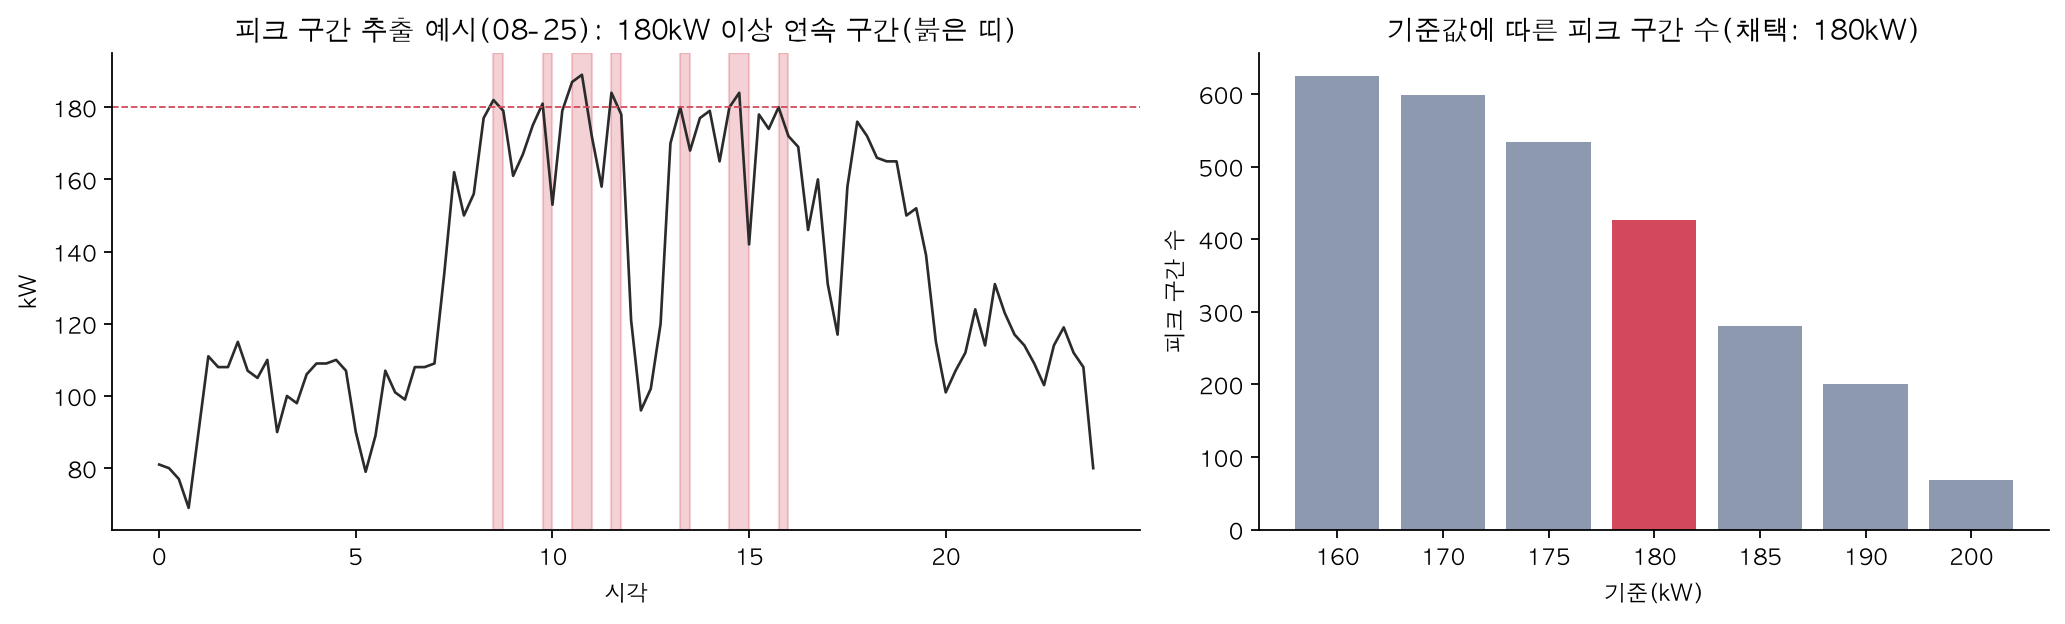

In [49]:
E, thr_tab, ext_summ = step3_extract(XD)
y = XD["kw"].dropna(); print(f"180kW 이상 슬롯 비율: {(y >= 180).mean():.1%} | 95번째 백분위수: {y.quantile(0.95):.0f}kW")
display(thr_tab); display(ext_summ.to_frame())
fig(S3 / "peak_extraction.png")

170kW로 낮추면 가동 시간 대부분이 포함되고, 190kW로 올리면 구간이 절반 이하로 줄어 유형 비교가 어렵습니다.
복사일을 한 번만 세면 **267개 구간(78일)** 이고, 7~9월 정상 가동일 47일 중 46일에 피크 구간이 있습니다.
구간마다 아래 특성을 계산했습니다.

In [50]:
display(E[["date", "시작시각", "지속시간(분)", "최대(kW)", "직전1시간 평균(kW)", "직후1시간 평균(kW)", "상승폭(kW)", "생산계획량(시작 시간)", "직전 시간 생산계획량", "재가동일", "기온"]].head(8))

,date,시작시각,지속시간(분),최대(kW),직전1시간 평균(kW),직후1시간 평균(kW),상승폭(kW),생산계획량(시작 시간),직전 시간 생산계획량,재가동일,기온
0,2021-01-07,08:30,30,182.00,119.25,166.00,62.75,538.00,"2,841.00",1,-8.60
1,2021-01-07,13:30,15,182.00,144.25,174.00,37.75,"1,293.00",797.00,1,-6.70
2,2021-01-07,14:30,15,180.00,174.50,163.25,5.50,"2,314.00","1,293.00",1,-6.30
3,2021-01-08,15:45,15,180.00,160.25,158.00,19.75,"3,947.00","1,270.00",0,-5.00
4,2021-01-09,13:45,15,181.00,154.50,22.50,26.50,0.00,0.00,0,-3.70
5,2021-01-14,08:30,45,204.00,128.00,171.25,76.00,844.00,280.00,1,0.30
6,2021-01-14,09:45,60,180.00,184.25,179.25,-4.25,"1,104.00",844.00,1,5.90
7,2021-01-14,11:15,30,190.00,175.00,127.50,15.00,"1,465.00",498.00,1,9.00


---
## 4단계. 피크 두 유형 구분

구간의 **상승폭, 지속시간, 직전 1시간 부하 수준**을 표준화해 K-means로 묶었습니다.
복사일이 같은 구간을 여러 번 넣지 않도록 고유한 날의 267개 구간으로만 학습했습니다.

**몇 개로 나눌 것인가.** 묶음 수 2~6개의 실루엣 점수(묶음이 얼마나 잘 갈리는지)를 비교합니다.

In [51]:
E, sil, type_prof = step4_types(E, XD)
display(sil)

,묶음 수,실루엣 점수,묶음별 구간 수
0,2,0.51,"[np.int64(181), np.int64(86)]"
1,3,0.42,"[np.int64(153), np.int64(59), np.int64(55)]"
2,4,0.41,"[np.int64(124), np.int64(64), np.int64(45), np.int64(34)]"
3,5,0.42,"[np.int64(105), np.int64(53), np.int64(49), np.int64(47), np.int64(13)]"
4,6,0.41,"[np.int64(88), np.int64(49), np.int64(49), np.int64(46), np.int64(23), np.in..."


2개일 때 점수가 가장 높습니다. 두 묶음의 특성은 다음과 같습니다.

,유형1: 가동 시작·재개 직후 크게 오르는 피크,유형2: 가동 중 잠깐 더 오르는 피크
구간 수,86.00,181.00
지속시간(분) 평균,96.80,31.90
지속시간(분) 중앙값,90.00,30.00
최대(kW) 평균,195.60,186.80
최대(kW) 중앙값,194.50,185.00
상승폭(kW) 평균,70.30,21.40
상승폭(kW) 중앙값,64.50,19.20
직전30분 상승(kW) 평균,58.40,23.10
직전30분 상승(kW) 중앙값,53.00,17.00
직전1시간 평균(kW) 평균,125.40,165.40


,특성,유형1 중앙값,유형2 중앙값,순위합 검정 p값
0,지속시간(분),90.00,30.00,0.00
1,최대(kW),194.50,185.00,0.00
2,상승폭(kW),64.50,19.25,0.00
3,직전30분 상승(kW),53.00,17.00,0.00
4,직전1시간 평균(kW),127.88,167.50,0.00
5,직후1시간 평균(kW),167.50,162.25,0.00


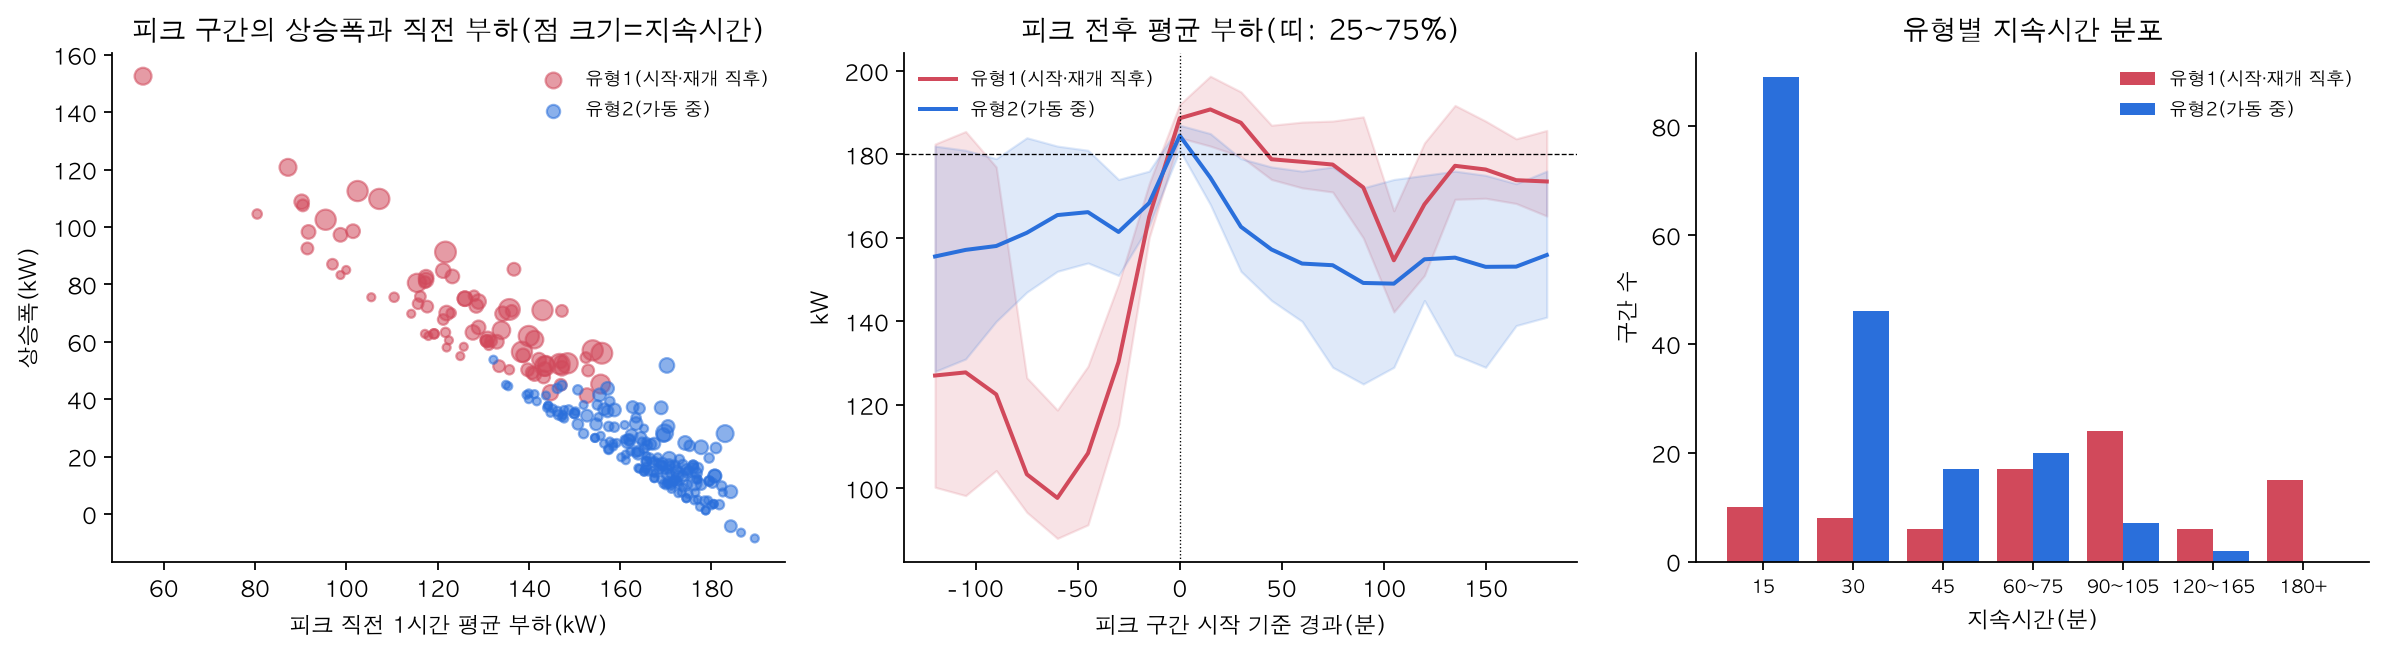

In [52]:
display(type_prof.T)
display(table(S4 / "type_difference_tests.csv"))
fig(S4 / "peak_types.png")

- **유형1 — 시작·재개 직후 크게 오르는 피크:** 직전 부하가 낮고(약 128kW), 약 65kW 급등하며, 90분가량 이어집니다. 최대값도 더 높습니다.
- **유형2 — 가동 중 잠깐 더 오르는 피크:** 이미 높은 부하(약 168kW) 위에서 약 19kW 더 오르고, 30분 안에 내려옵니다.

여섯 특성 모두 두 유형의 차이가 통계적으로 유의합니다(순위합 검정 p < 0.001).
가운데 그림이 전후 패턴입니다. 유형1은 100kW 부근에서 올라와 높은 수준이 유지되고, 유형2는 뾰족하게 솟았다 내려옵니다.

**유형별 예측오차.** 2.1절의 피크 시간 오차를 두 유형으로 나눠 보면, 두 유형 모두 약 10~12kW 낮게 예측합니다.

In [53]:
err["peak_type"] = 0
for _, e in E.iterrows():
    m = (err["date"] == e["date"]) & (err["slot"] >= e["start_slot"]) & (err["slot"] <= e["end_slot"])
    err.loc[m, "peak_type"] = int(e["유형"])
g = err[err["peak_type"] > 0].groupby("peak_type")
display(pd.DataFrame({"슬롯 수": g.size(), "MAE": g["abs_err"].mean(), "Bias(예측-실측)": g["err"].mean(), "평균 실측(kW)": g["kw"].mean()}).rename(index=TYPE_SHORT))

,슬롯 수,MAE,Bias(예측-실측),평균 실측(kW)
peak_type,,,,
유형1(시작·재개 직후),479,11.73,-9.79,188.67
유형2(가동 중),277,12.81,-11.53,185.78


---
## 5단계. 유형별 발생조건

각 유형이 어떤 **시각, 생산량, 생산량 변화, 운영상태**에서 생기는지 비교합니다.

**함수 정의 — 15분 슬롯 단위 피크 조건(보조 분석)**

In [54]:
warnings.filterwarnings("ignore", category=UserWarning)


PEAK_FEATS = ["hour", "quarter", "dow", "restart_day", "days_since_workday", "prod", "prod_lag1h", "prod_lead1h",
              "hours_from_first_prod", "prod_start_hour", "day_prod", "temp", "humid", "month", "lunch"]
KOR = {"hour": "시각", "quarter": "15분 구간", "dow": "요일", "restart_day": "재가동일(주말·휴무 후)",
       "days_since_workday": "직전 가동일 경과일", "prod": "생산계획량(당시간)", "prod_lag1h": "직전시간 생산량",
       "prod_lead1h": "다음시간 생산량", "staff": "공장인원(환산)", "hours_from_first_prod": "첫 생산 후 경과시간",
       "prod_start_hour": "생산 시작 시간", "day_prod": "일 생산계획량", "temp": "기온", "humid": "습도",
       "month": "월", "lunch": "점심시간"}


def wrate(df, by):
    w = 1 / df["aug_size"]
    g = df.assign(w=w, ev=df["event"] * w).groupby(by)
    return (g["ev"].sum() / g["w"].sum() * 100).rename("이벤트율%")


def peak_condition_run(X: pd.DataFrame):
    d = X[X["kw"].notna()].copy()
    d["event"] = (d["kw"] >= PEAK_EVENT_KW).astype(int)
    d["temp_bin"] = pd.cut(d["temp"], [-20, 5, 15, 22, 26, 40], labels=["<5", "5-15", "15-22", "22-26", "26+"])
    out = {}

    # (1) 조건별 발생률
    out["by_hour_restart"] = wrate(d, ["hour", "restart_day"]).unstack()
    out["by_month"] = wrate(d, "month")
    out["by_tempbin_work"] = wrate(d[d.full_workday == 1], "temp_bin")
    out["by_quarter_work"] = wrate(d[(d.full_workday == 1) & d.hour.isin([8, 13])], ["hour", "quarter"]).unstack()
    out["by_dow"] = wrate(d, "dow")
    share = d[d.event == 1].assign(w=1 / d["aug_size"]).groupby("hour")["w"].sum()
    out["event_share_by_hour"] = (share / share.sum() * 100).rename("이벤트 비중%")
    for k, v in out.items():
        v.round(2).to_csv(S5 / f"peak_{k}.csv", encoding="utf-8-sig")

    # 그림: 시각 x 재가동일 이벤트율 / 시각별 평균 프로파일(재가동일 vs 일반 가동일)
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
    r = out["by_hour_restart"].fillna(0)
    ax[0].bar(r.index - 0.2, r.get(0, 0), 0.4, label="일반 가동일", color=C["muted"])
    ax[0].bar(r.index + 0.2, r.get(1, 0), 0.4, label="재가동일(주말·휴무 다음날)", color=C["peak"])
    ax[0].set(xlabel="시각", ylabel="180kW 이상 15분 슬롯 비율(%)", title="시각별 피크위험 이벤트 발생률")
    ax[0].legend(frameon=False)
    wd = d[d.full_workday == 1]
    prof = wd.groupby(["restart_day", "slot"])["kw"].mean().unstack(0)
    ax[1].plot(prof.index / 4, prof[0], color=C["muted"], label="일반 가동일")
    ax[1].plot(prof.index / 4, prof[1], color=C["peak"], label="재가동일")
    ax[1].axhline(PEAK_EVENT_KW, ls="--", color="k", lw=0.8)
    ax[1].text(0.3, PEAK_EVENT_KW + 2, "피크위험 기준 180kW", fontsize=8)
    ax[1].set(xlabel="시각", ylabel="평균 15분 최대수요전력(kW)", title="가동일 평균 부하 프로파일")
    ax[1].legend(frameon=False)
    save(fig, S5 / "peak_hour_restart.png")

    # (2) 설명용 분류모델(가동일만) + SHAP
    wd = d[d.full_workday == 1].copy()
    clf = lgb.LGBMClassifier(n_estimators=400, learning_rate=0.03, num_leaves=15, min_child_samples=40,
                             subsample=0.8, subsample_freq=1, colsample_bytree=0.8, random_state=SEED, verbose=-1, n_jobs=4)
    clf.fit(wd[PEAK_FEATS], wd["event"], sample_weight=1 / wd["aug_size"])
    expl = shap.TreeExplainer(clf)
    sv = expl.shap_values(wd[PEAK_FEATS])
    sv = sv[1] if isinstance(sv, list) else sv
    imp = pd.Series(np.abs(sv).mean(0), index=PEAK_FEATS).sort_values(ascending=False)
    imp.rename(index=KOR).round(4).to_csv(S5 / "peak_shap_importance.csv", encoding="utf-8-sig")
    out["shap_importance"] = imp
    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    top = imp.head(10)[::-1]
    ax.barh([KOR[i] for i in top.index], top.values, color=C["peak"])
    ax.set(xlabel="평균 |SHAP| (log-odds)", title="피크위험 이벤트 주요 영향요인(가동일)")
    save(fig, S5 / "peak_shap_importance.png")

    # 상호작용: 시각 x 재가동일, 시각 x 기온
    inter = expl.shap_interaction_values(wd[PEAK_FEATS].sample(4000, random_state=SEED))
    inter = inter[1] if isinstance(inter, list) else inter
    Mv = np.abs(inter).mean(0).copy()
    np.fill_diagonal(Mv, 0)
    M = pd.DataFrame(Mv, index=PEAK_FEATS, columns=PEAK_FEATS)
    pairs = M.where(np.triu(np.ones(M.shape), 1).astype(bool)).stack().sort_values(ascending=False).head(10)
    pairs.index = [f"{KOR[a]} x {KOR[b]}" for a, b in pairs.index]
    pairs.round(4).to_csv(S5 / "peak_shap_interactions.csv", encoding="utf-8-sig")
    out["shap_interactions"] = pairs

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    for i, (feat, col) in enumerate([("hour", "restart_day"), ("temp", "hour")]):
        j = PEAK_FEATS.index(feat)
        sc = ax[i].scatter(wd[feat] + (np.random.RandomState(0).uniform(-.3, .3, len(wd)) if feat == "hour" else 0),
                           sv[:, j], c=wd[col], s=3, cmap="coolwarm", alpha=0.5)
        ax[i].set(xlabel=KOR[feat], ylabel=f"SHAP({KOR[feat]})", title=f"{KOR[feat]} 효과 (색: {KOR[col]})")
        plt.colorbar(sc, ax=ax[i])
    save(fig, S5 / "peak_shap_dependence.png")

    # (3) 의사결정나무 규칙(현장 공유용)
    tf = ["hour", "restart_day", "temp", "prod", "hours_from_first_prod", "quarter"]
    rules = fit_rules(wd, wd["event"].values, tf, [KOR[f] for f in tf], w=(1 / wd["aug_size"]).values,
                      depth=3, min_leaf=150)
    rules = rules.rename(columns={"가중평균": "피크위험 이벤트율"})
    rules["피크위험 이벤트율"] = (rules["피크위험 이벤트율"] * 100).round(1)
    rules.to_csv(S5 / "peak_tree_rules.csv", index=False, encoding="utf-8-sig")
    out["tree_rules"] = rules

    # (4) 월별 최대피크 사례
    mp = d.loc[d.groupby("month")["kw"].idxmax(), ["month", "ts", "kw", "dow", "restart_day", "hour", "prod", "temp", "aug_size"]]
    mp.to_csv(S5 / "peak_monthly_max.csv", index=False, encoding="utf-8-sig")
    out["monthly_max"] = mp
    return out

▶ 시작 시각


start_hour,8,9,10,11,13,14,15,16,17,18,19
유형,,,,,,,,,,,
유형1(시작·재개 직후),43,0,0,0,41,0,0,0,1,1,0
유형2(가동 중),18,15,19,34,11,26,35,7,7,6,3


▶ 운영상태


유형,유형1(시작·재개 직후),유형2(가동 중),유형1(시작·재개 직후) 비중%,유형2(가동 중) 비중%
운영상태,,,,
오전 가동 시작(7~9시),43,18,50.00,9.90
오전 가동 중(9~12시),0,68,0.00,37.60
오후 가동 중(14~17시),0,68,0.00,37.60
저녁·야간(17시~),2,16,2.30,8.80
점심 정지·재개(12~14시),41,11,47.70,6.10


▶ 생산량·생산량 변화·기온(유형 간 차이 검정 포함)


...

유형,유형1(시작·재개 직후),유형2(가동 중)
변화구간,,
300개 이상 감소,18,61
변화 작음(±300개),22,55
300개 이상 증가,46,65


▶ 재가동일 여부별 발생 빈도(고유한 정상 가동일 기준)


,가동일 수,유형1 발생일 비율%,유형1 일평균 구간 수,유형2 발생일 비율%,유형2 일평균 구간 수
재가동일 여부,,,,,
일반 가동일,59,55.93,0.88,74.58,1.92
재가동일,25,72.00,1.04,72.00,1.92


▶ 일 최고기온별 발생 빈도


,가동일 수,유형1 발생일 비율%,유형1 일평균 구간 수,유형2 발생일 비율%,유형2 일평균 구간 수
일 최고기온,,,,,
20도 미만,29,51.72,0.66,62.07,1.55
20~27도,31,41.94,0.65,67.74,1.87
27도 이상,24,95.83,1.62,95.83,2.42


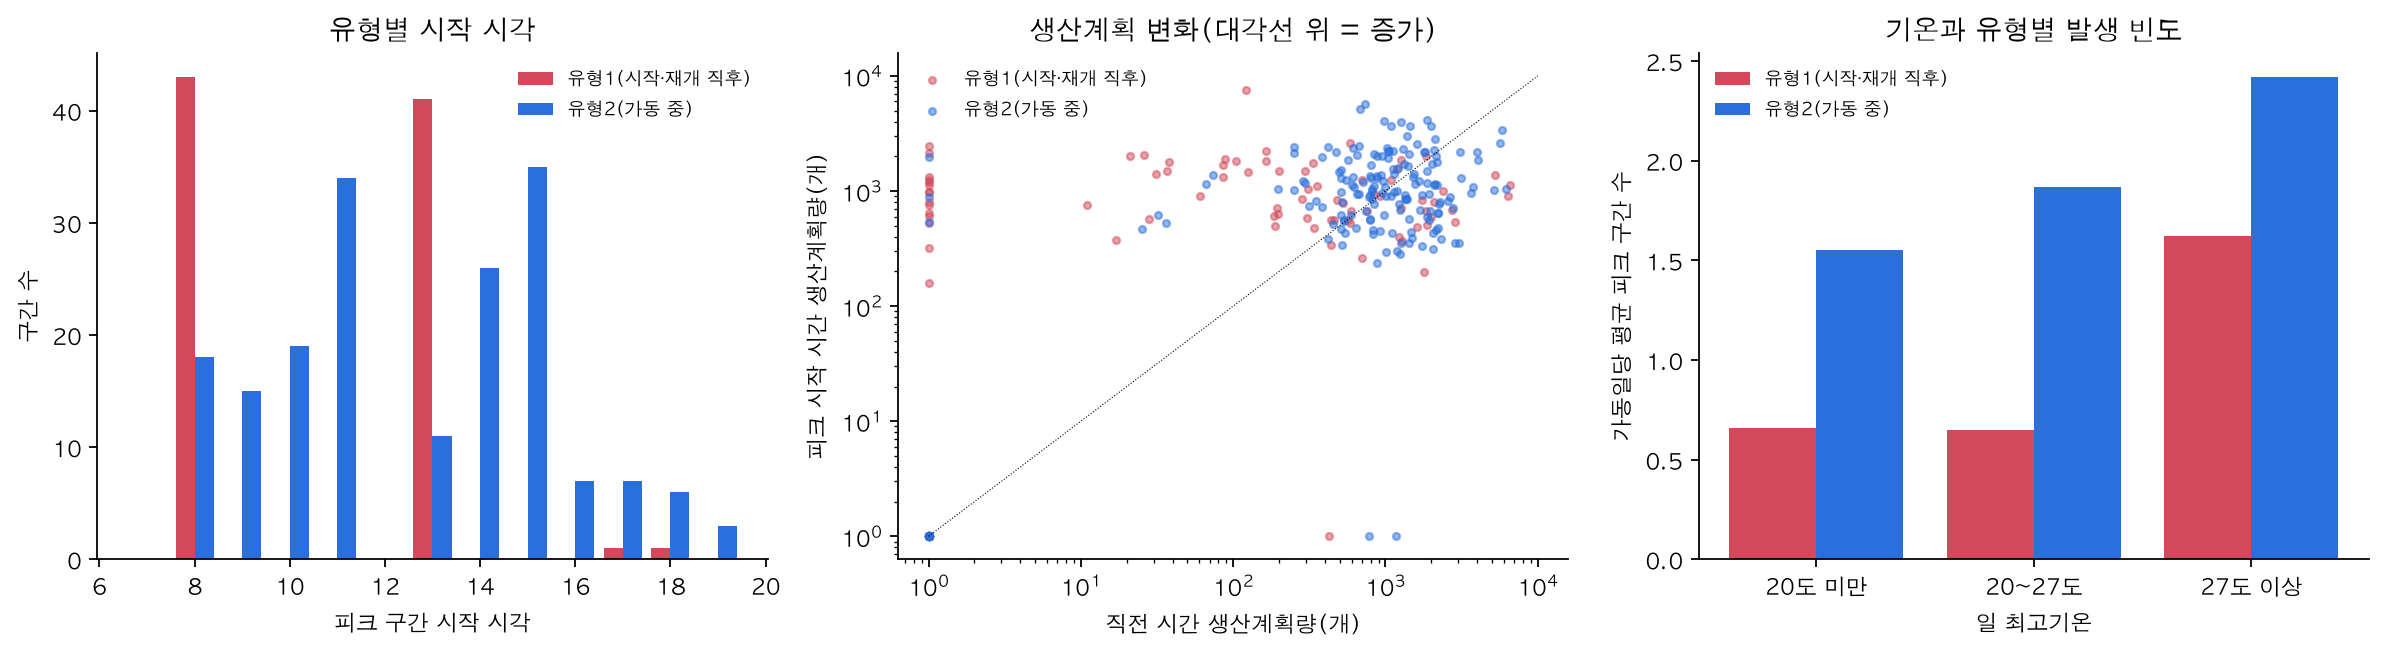

In [55]:
cond = step5_conditions(E, XD)
print("▶ 시작 시각"); display(cond["by_hour"].T)
print("▶ 운영상태"); display(cond["by_state"])
print("▶ 생산량·생산량 변화·기온(유형 간 차이 검정 포함)"); display(cond["numeric"])
print("▶ 생산계획 변화 구간"); display(cond["by_prod_change"])
print("▶ 재가동일 여부별 발생 빈도(고유한 정상 가동일 기준)"); display(cond["rate_by_restart"])
print("▶ 일 최고기온별 발생 빈도"); display(cond["rate_by_tmax"])
fig(S5 / "type_conditions.png")

| 조건 | 유형1 | 유형2 |
|---|---|---|
| 시각 | 8시대와 13시대가 98% | 9~11시, 14~16시 |
| 직전 시간 생산계획 | 적음(중앙값 198개) | 많음(946개) |
| 생산계획 변화 | 늘어나는 시점(+359개/시간) | 변화 없음 |
| 운영상태 | 아침 시작, 점심 후 재개 | 가동 중 |
| 재가동일 | 더 자주 발생(72% 대 56%) | 무관 |
| 기온 | 27℃ 이상인 날 급증 | 27℃ 이상인 날 급증 |

**해석.** 유형1은 설비가 쉬다가 **한꺼번에 켜질 때**, 유형2는 **생산이 많은 시간이 이어질 때** 생깁니다. 원인이 다르므로 대책도 달라야 합니다.

**보조 분석(15분 슬롯 단위).** 구간이 아니라 슬롯 하나하나가 피크인지를 설명하는 모델로도 같은 결론을 확인했습니다.

,조건,표본수,피크위험 이벤트율
0,기온 > 27.7 & 시각 <= 11.5,268,70.70
1,기온 > 27.7 & 시각 > 11.5 & 생산계획량(당시간) > 639.5,312,38.90
2,기온 <= 27.7 & 생산계획량(당시간) > 406.5 & 시각 <= 14.5,4060,18.80
3,기온 > 27.7 & 시각 > 11.5 & 생산계획량(당시간) <= 639.5,156,13.20
4,기온 <= 27.7 & 생산계획량(당시간) <= 406.5 & 생산계획량(당시간) > 257.0,1016,5.50
5,기온 <= 27.7 & 생산계획량(당시간) > 406.5 & 시각 > 14.5,2628,4.50
6,기온 <= 27.7 & 생산계획량(당시간) <= 406.5 & 생산계획량(당시간) <= 257.0,6534,0.20


hour,7,8,9,10,11,12,13,14,15,16,17,18,19
restart_day,,,,,,,,,,,,,
일반 가동일 %,0.00,22.40,18.93,14.55,22.48,0.00,16.64,18.81,9.61,7.22,1.45,2.08,0.65
재가동일 %,0.00,42.55,40.45,33.18,38.36,0.00,28.45,26.09,18.55,10.00,1.36,6.91,0.00


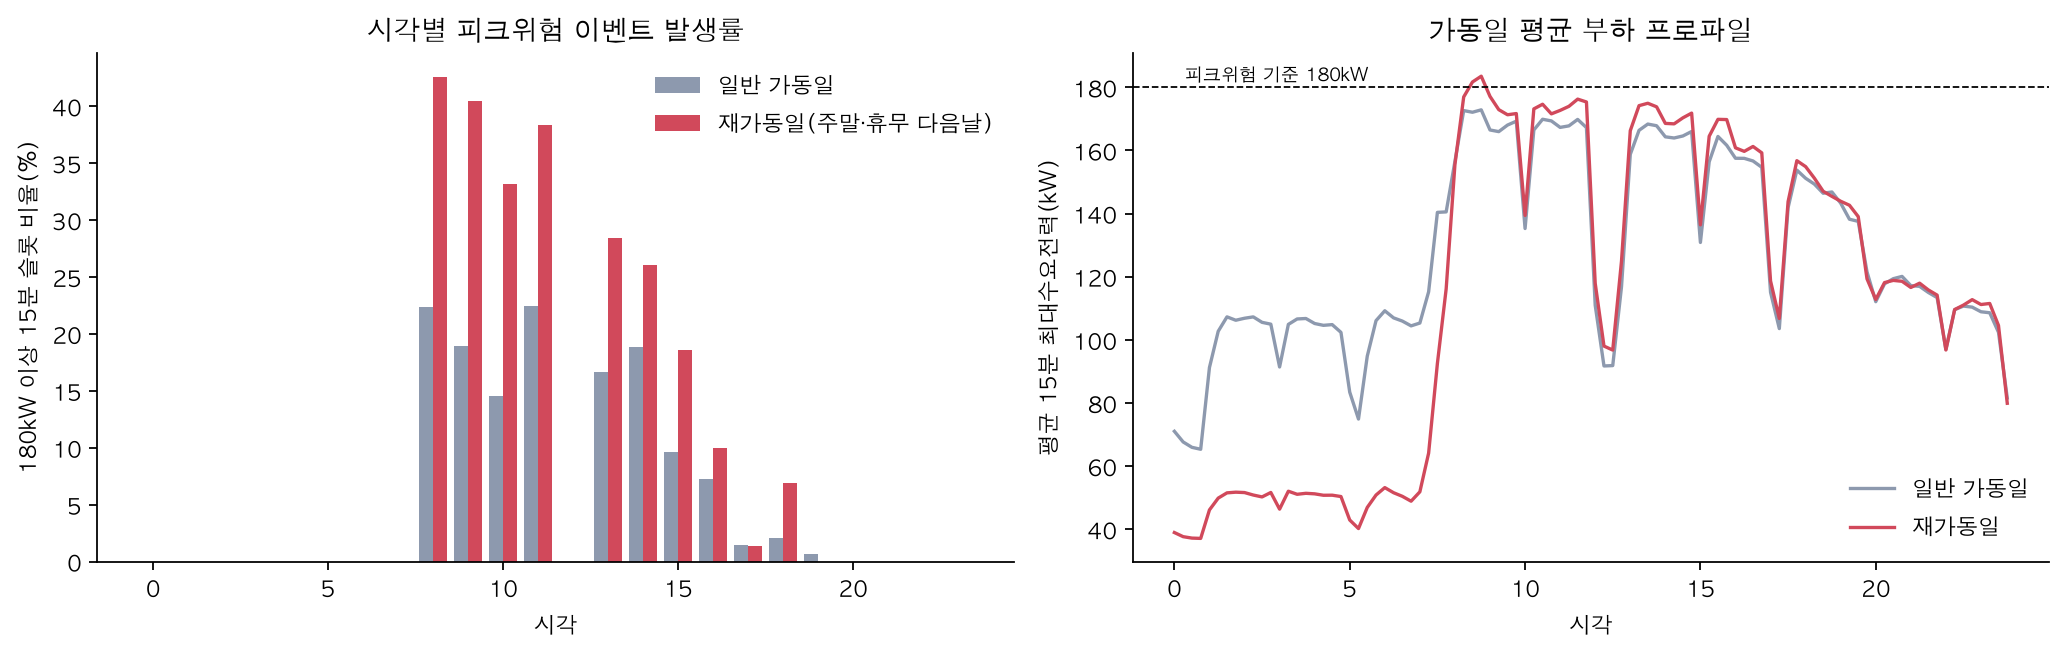

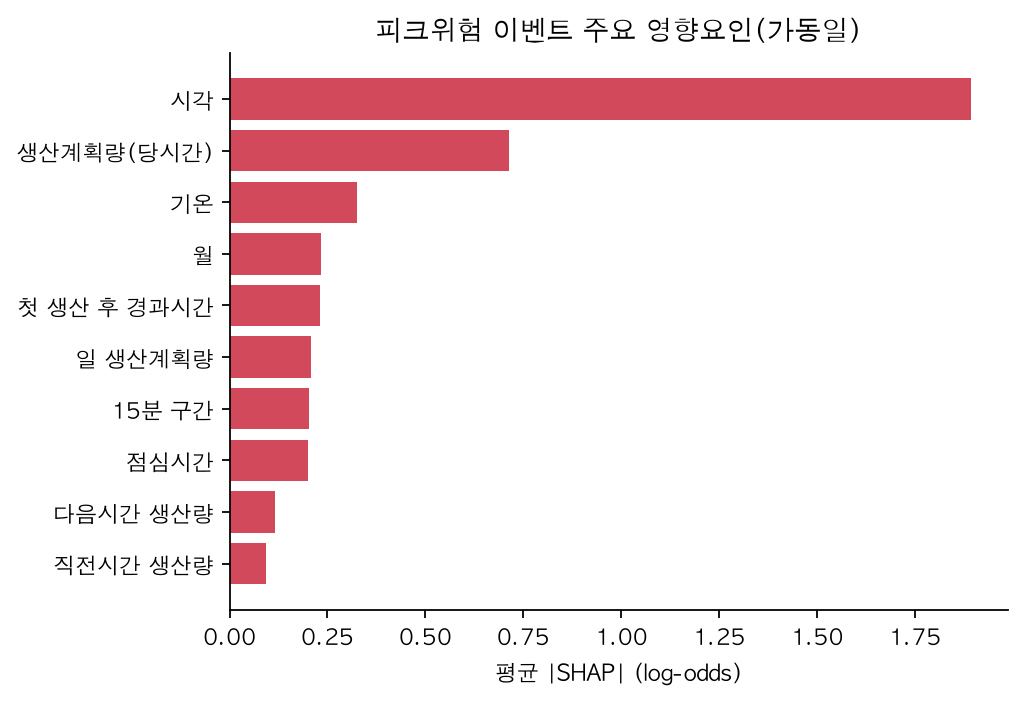

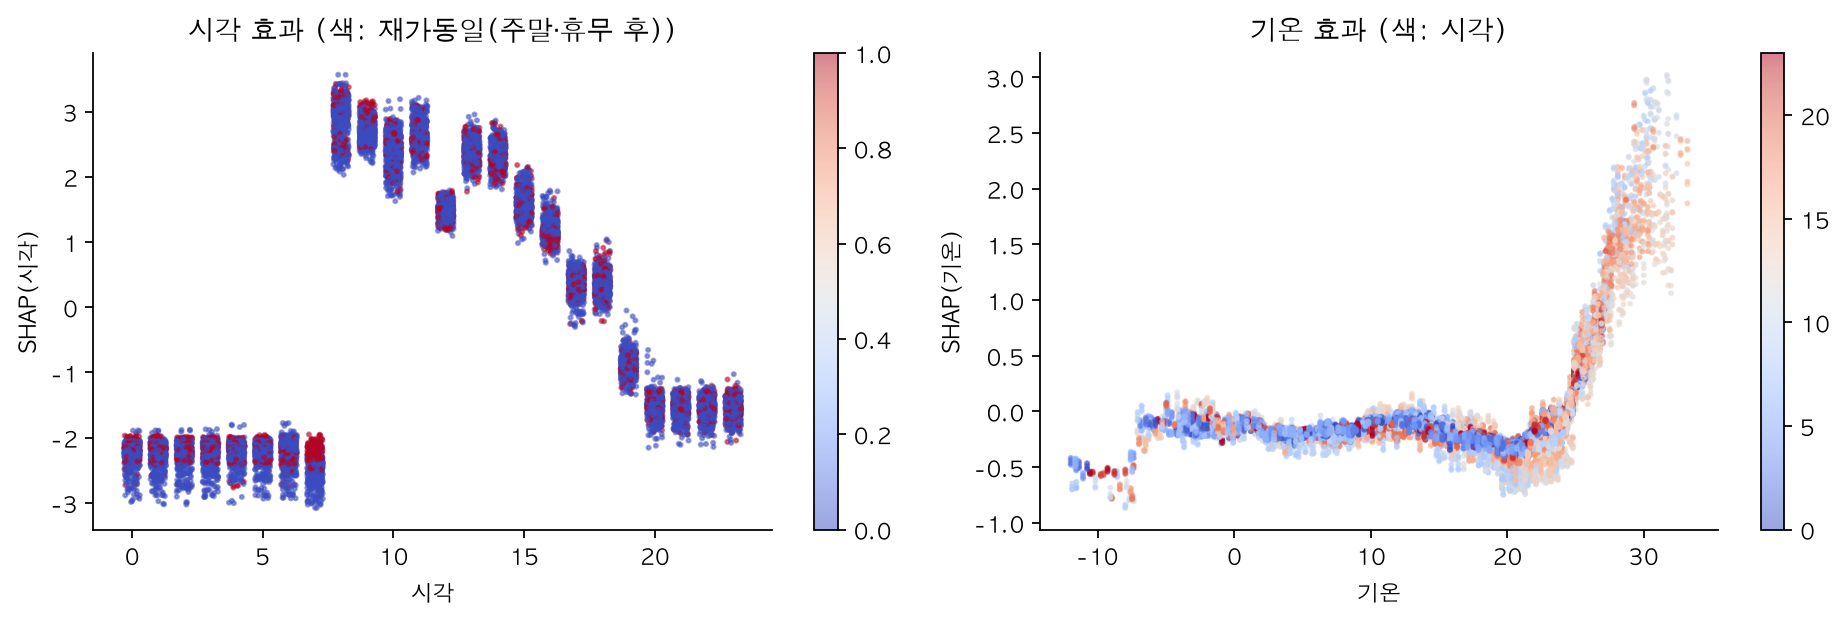

월별 최대 피크:


,month,ts,kw,dow,restart_day,hour,prod,temp,aug_size
2721,1,2021-01-29 08:15:00,222.00,5,0,8,364.00,-6.80,3
4354,2,2021-02-15 08:30:00,198.00,1,1,8,635.00,10.20,4
8385,3,2021-03-29 08:15:00,222.00,1,1,8,"1,644.00",14.00,3
9251,4,2021-04-07 08:45:00,199.00,3,0,8,669.00,13.60,2
12035,5,2021-05-06 08:45:00,199.00,4,1,8,424.00,14.60,2
17217,6,2021-06-29 08:15:00,222.00,2,0,8,893.00,23.30,3
19149,7,2021-07-19 11:15:00,222.00,1,1,11,"1,280.00",28.40,1
21346,8,2021-08-11 08:30:00,218.00,3,0,8,783.00,25.60,1
24231,9,2021-09-10 09:45:00,204.00,5,0,9,"1,038.00",21.80,1


In [56]:
pk = peak_condition_run(XD)
display(pk["tree_rules"]); display(pk["by_hour_restart"].loc[7:19].T.rename(index={0: "일반 가동일 %", 1: "재가동일 %"}))
fig(S5 / "peak_hour_restart.png"); fig(S5 / "peak_shap_importance.png", 650); fig(S5 / "peak_shap_dependence.png", 1000)
print("월별 최대 피크:"); display(pk["monthly_max"])

---
## 6단계. 저감방안

### 6.1 유형별 조치 시뮬레이션

7~9월 실측 하루 프로파일에 **전력량을 보존하는 부하 이동 선형계획**을 적용합니다.

- 기저부하(0~6시 중앙값)를 넘는 부하 중 비율 α만 가동 시점을 옮길 수 있다고 가정
- 옮길 수 있는 시간 범위를 유형에 맞춰 제한하고, 그 안에서 **그날의 최대값이 가장 낮아지도록** 최적화

| 조치 | 대상 | 내용 |
|---|---|---|
| A. 설비 가동시점 분산 | 유형1 | 시작·재개 후 2시간의 부하를 직전 2시간으로 앞당김(일부 설비를 먼저 켬) |
| B. 생산일정 이동 | 유형2 | 피크 구간의 생산을 같은 날 17~22시로 옮김 |
| A + B | 둘 다 | 두 조치 동시 적용 |
| 상한 | 전체 | 06~22시 모든 부하를 ±2시간 안에서 자유 이동(얻을 수 있는 최대치) |

**함수 정의 — 부하 이동 선형계획, 예측 연동 계획 규칙, 요금 계산**

In [57]:
MEASURES = {"A": "조치A 설비 가동시점 분산(유형1 대상)", "B": "조치B 생산일정 저녁 이동(유형2 대상)",
            "AB": "조치A+B 동시 적용", "UB": "상한: ±2시간 자유 이동"}


def moves_for(measure, episodes, W=8):
    """하루의 피크 구간 목록(episodes: start_slot, end_slot, 유형)으로 허용 이동 쌍 (from, to) 생성."""
    pairs = set()
    if measure == "UB":
        for t in range(24, 88):
            for s in range(max(24, t - W), min(88, t + W + 1)):
                if s != t:
                    pairs.add((t, s))
        return sorted(pairs)
    for e in episodes:
        st, en, ty = int(e["start_slot"]), int(e["end_slot"]), int(e["유형"])
        if ty == 1 and measure in ("A", "AB"):
            for t in range(st, min(en, st + 7) + 1):
                for s in range(max(st - 8, 0), st):
                    pairs.add((t, s))
        if ty == 2 and measure in ("B", "AB"):
            dst = range(68, 88) if en < 64 else range(min(en + 5, 95), 96)
            for t in range(max(st - 1, 0), min(en + 1, 95) + 1):
                for s in dst:
                    if s != t:
                        pairs.add((t, s))
    return sorted(pairs)


def shave_day(P, alpha, pairs, eps=1e-3):
    P = np.asarray(P, float)
    if np.isnan(P).any():
        return P.copy()
    base = np.median(P[:24])
    F = alpha * np.clip(P - base, 0, None)
    pairs = [(t, s) for t, s in pairs if F[t] > 0]
    if not pairs:
        return P.copy()
    n = len(pairs)
    c = np.r_[eps * np.array([abs(t - s) for t, s in pairs], float), 1.0]     # 변수: x_0..x_{n-1}, z
    A = lil_matrix((96 + 96, n + 1))
    b = np.zeros(96 + 96)
    for j, (t, s) in enumerate(pairs):
        A[t, j] -= 1          # Q_s <= z  ->  -(나간 양) + (들어온 양) - z <= -P_s
        A[s, j] += 1
        A[96 + t, j] = 1      # Σ_s x_{t,s} <= F_t
    A[:96, n] = -1
    b[:96] = -P
    b[96:] = F
    res = linprog(c, A_ub=A.tocsr(), b_ub=b, bounds=[(0, None)] * (n + 1), method="highs")
    if not res.success:
        return P.copy()
    Q = P.copy()
    for j, (t, s) in enumerate(pairs):
        Q[t] -= res.x[j]
        Q[s] += res.x[j]
    return Q


def fixed_evening_shift(P, alpha, src=(32, 68), dst=(68, 88)):
    """예측 기반 운영용 '고정 규칙'(실측 프로파일을 모르는 상태에서 적용 가능):
    주간(08~17시) 기저 초과부하의 alpha 비율을 같은 날 17~22시에 균등 배분(전력량 보존)."""
    P = np.asarray(P, float)
    if np.isnan(P).any():
        return P.copy()
    base = np.median(P[:24])
    Q = P.copy()
    take = alpha * np.clip(P[src[0]:src[1]] - base, 0, None)
    Q[src[0]:src[1]] -= take
    Q[dst[0]:dst[1]] += take.sum() / (dst[1] - dst[0])
    return Q


def planned_block_shift(P, F, delta, dmax_pred, src=(32, 68), dst=(68, 96)):
    """예측 기반 운영 규칙(실측을 모르는 상태에서 하루 전에 계획 가능):
    - 경보일에 주간(08~17시) 가동 설비 중 delta kW 상당의 블록(예: 1개 라인·보조설비)을 저녁(17~24시)으로 재배치
    - 줄이는 양은 예측 프로파일 F 기준으로 계획하고(실제 기저부하 아래로는 줄이지 않음),
      옮긴 전력량은 예측 프로파일상 여유(목표상한 C = 예측 일최대 - delta 와의 차이)에 비례해 저녁 슬롯에 배분
    - 계획을 실측 프로파일 P에 적용한 결과를 반환(전력량 보존)"""
    P, F = np.asarray(P, float), np.asarray(F, float)
    if np.isnan(P).any():
        return P.copy()
    base = np.median(P[:24])
    base_f = np.median(F[:24])
    Q = P.copy()
    s0, s1 = src
    plan = np.minimum(delta, np.clip(F[s0:s1] - base_f, 0, None))
    take = np.minimum(plan, np.clip(P[s0:s1] - base, 0, None))
    Q[s0:s1] -= take
    E = take.sum()
    C = dmax_pred - delta
    head = np.clip(C - F[dst[0]:dst[1]], 0, None)
    w = head / head.sum() if head.sum() > 0 else np.full(dst[1] - dst[0], 1 / (dst[1] - dst[0]))
    Q[dst[0]:dst[1]] += E * w
    return Q


def energy_cost(profile_kw, month, slots):
    kwh = np.asarray(profile_kw) * 0.25
    rates = np.array([ENERGY_RATE[season_of(month)][tou_band(month, s // 4)] for s in slots])
    return float(np.nansum(kwh * rates))


def shave_simulate(X, E, measures=("A", "B", "AB", "UB"), alphas=(0.1, 0.2, 0.3), months=(7, 8, 9)):
    """원본 구간(기본 7~9월)의 실측 프로파일에 유형별 조치를 적용. 일별 결과 R, 구간별 결과 EP, 프로파일 반환."""
    d = X[X["month"].isin(months)].copy()
    ok = d.groupby("date")["kw"].transform(lambda v: v.notna().mean() >= 0.8)   # 결측 20% 이상인 날 제외
    d = d[ok]
    ep_by_day = {k: g.to_dict("records") for k, g in E.groupby("date")}
    rows, ep_rows, profiles = [], [], {}
    for date, g in d.groupby("date"):
        g = g.sort_values("slot")
        P = pd.Series(g["kw"].values).interpolate(limit_direction="both").values   # 단발 결측 보간
        m = int(g["month"].iloc[0])
        eps_ = ep_by_day.get(date, [])
        types = {int(e["유형"]) for e in eps_}
        base = {"date": date, "month": m, "orig_peak": np.nanmax(P), "orig_cost": energy_cost(P, m, g["slot"]),
                "has_type1": int(1 in types), "has_type2": int(2 in types),
                "restart_day": int(g["restart_day"].iloc[0]), "temp_max": g["temp_max"].iloc[0],
                "full_workday": int(g["full_workday"].iloc[0])}
        for ms in measures:
            pairs = moves_for(ms, eps_)
            for a in alphas:
                Q = shave_day(P, a, pairs)
                rows.append(dict(base, measure=ms, alpha=a, new_peak=np.nanmax(Q), new_cost=energy_cost(Q, m, g["slot"])))
                profiles[(date, ms, a)] = Q
                for e in eps_:
                    sl = slice(int(e["start_slot"]), int(e["end_slot"]) + 1)
                    ep_rows.append({"date": date, "유형": int(e["유형"]), "measure": ms, "alpha": a,
                                    "구간 최대 전": np.nanmax(P[sl]), "구간 최대 후": np.nanmax(Q[sl]),
                                    "180kW 이상 슬롯 전": int((P[sl] >= 180).sum()), "180kW 이상 슬롯 후": int((Q[sl] >= 180).sum())})
    return pd.DataFrame(rows), pd.DataFrame(ep_rows), profiles


def shave_summarize(R, EP):
    """조치 x alpha 요약: 유형별 구간 최대 변화, 일 최대 변화, 기간 최대수요전력, 요금 환산."""
    out = []
    for (ms, a), g in R.groupby(["measure", "alpha"]):
        e = EP[(EP["measure"] == ms) & (EP["alpha"] == a)]
        mo = g.groupby("month").agg(orig=("orig_peak", "max"), new=("new_peak", "max"))
        pk = g[(g["has_type1"] + g["has_type2"]) > 0]
        row = {"조치": MEASURES[ms], "measure": ms, "alpha": a}
        for t in (1, 2):
            et = e[e["유형"] == t]
            row[f"유형{t} 구간 최대 평균 전(kW)"] = et["구간 최대 전"].mean()
            row[f"유형{t} 구간 최대 평균 후(kW)"] = et["구간 최대 후"].mean()
            row[f"유형{t} 180kW 이상 시간 감소%"] = 100 * (1 - et["180kW 이상 슬롯 후"].sum() / max(et["180kW 이상 슬롯 전"].sum(), 1))
        row.update({
            "피크 발생일 일최대 평균 감소(kW)": (pk["orig_peak"] - pk["new_peak"]).mean(),
            "피크 발생일 일최대 평균 감소(%)": 100 * ((pk["orig_peak"] - pk["new_peak"]) / pk["orig_peak"]).mean(),
            "기간 최대수요전력 전(kW)": mo["orig"].max(), "기간 최대수요전력 후(kW)": mo["new"].max(),
            "연간 기본요금 절감(원)": (mo["orig"].max() - mo["new"].max()) * BASIC_CHARGE_KRW_PER_KW * 12,
            "전력량요금 변화(원/기간)": (g["new_cost"] - g["orig_cost"]).sum()})
        out.append(row)
    return pd.DataFrame(out)

**함수 정의 — 유형별 조치 시뮬레이션 실행과 운영 검증**

In [58]:
# --------------------------------------------------------------------------------------------
# 모델 비교 구성: (표시명, 모델키, 예측시점, 피처셋, 가중치)
#   피처셋 plan = 생산계획+달력+기상(전력 지연값 없음) / full = plan + 전력 지연값
# --------------------------------------------------------------------------------------------


def step_mitigation(XD, Xte, dp, E):
    """6단계: 유형별 저감방안 시뮬레이션(7~9월 원본 구간) + 예측 연동 운영 규칙 검증(시험 구간)."""
    R, EP, prof = shave_simulate(XD, E)
    S = shave_summarize(R, EP)
    S.round(1).to_csv(S6 / "mitigation_by_type_summary.csv", index=False, encoding="utf-8-sig")
    R.round(2).to_csv(S6 / "mitigation_daily.csv", index=False, encoding="utf-8-sig")
    EP.round(2).to_csv(S6 / "mitigation_by_episode.csv", index=False, encoding="utf-8-sig")

    # 재가동일·고온일·일반 가동일별 효과(피크 발생일)
    R2 = R[(R.has_type1 + R.has_type2) > 0].copy()
    R2["day_type"] = np.select([R2.restart_day == 1, R2.temp_max >= 27], ["재가동일", "고온일(최고 27도 이상)"], "그 외 가동일")
    bytype = R2.assign(red=R2.orig_peak - R2.new_peak).groupby(["measure", "alpha", "day_type"])["red"].mean().unstack().round(2)
    bytype.to_csv(S6 / "mitigation_by_daytype.csv", encoding="utf-8-sig")

    # 예측 연동 운영(시험 구간): 피크 앙상블의 '내일 일최대 예측' >= 경보 기준인 날에만
    # 하루 전 계획 규칙(주간 delta kW 블록을 저녁 여유 슬롯으로 재배치, planned_block_shift)을 세우고
    # 그 계획을 실측 부하에 적용했을 때의 결과를 평가 -> 실측을 미리 알 필요가 없는 현실적 평가
    pol_rows, day_rows = [], []
    test_days = [d for d in dp.index if not np.isnan(dp.loc[d, "ymax"])]
    act_by_day = {d: XD[XD.date == d].sort_values("slot")["kw"].interpolate(limit_direction="both").values
                  for d in test_days}
    fc_by_day = {d: Xte[Xte.date == d].sort_values("slot")["pred"].values for d in test_days}
    for delta in (10, 15, 20):
        for thr in (None, 195, 190, 185, 180):
            new_max, n_act, ecost = [], 0, 0.0
            for d in test_days:
                P = act_by_day[d]
                act = thr is not None and dp.loc[d, "dmax_pred"] >= thr
                Q = planned_block_shift(P, fc_by_day[d], delta, dp.loc[d, "dmax_pred"]) if act else P
                n_act += int(act)
                new_max.append(np.nanmax(Q))
                m = pd.Timestamp(d).month
                ecost += energy_cost(Q, m, range(96)) - energy_cost(P, m, range(96))
                if thr == 185 and delta == 15:
                    day_rows.append({"date": d, "예측 일최대": dp.loc[d, "dmax_pred"], "실측 일최대": dp.loc[d, "ymax"],
                                     "경보(조치)": int(act), "조치 후 일최대": np.nanmax(Q)})
            pol_rows.append({"이전 블록 delta(kW)": delta, "경보 기준(kW)": "조치 없음" if thr is None else thr,
                             "조치일 수": n_act, "시험기간 최대수요전력(kW)": max(new_max),
                             "가동일 일최대 평균(kW)": np.mean([m for m in new_max if m > 120]),
                             "전력량요금 변화(원/2주)": ecost})
    P = pd.DataFrame(pol_rows)
    base_max = max(np.nanmax(v) for v in act_by_day.values())
    P["최대수요전력 감소(kW)"] = base_max - P["시험기간 최대수요전력(kW)"]
    P["연간 기본요금 절감(원, 요금적용전력 반영 가정)"] = P["최대수요전력 감소(kW)"] * BASIC_CHARGE_KRW_PER_KW * 12
    P.round(1).to_csv(S6 / "forecast_driven_policy_test.csv", index=False, encoding="utf-8-sig")
    pd.DataFrame(day_rows).round(1).to_csv(S6 / "forecast_driven_policy_days.csv", index=False, encoding="utf-8-sig")

    # 그림1: 두 유형이 모두 있는 대표일의 조치 전후
    both = R[(R.measure == "AB") & (R.alpha == 0.2) & (R.has_type1 == 1) & (R.has_type2 == 1)]
    d0 = both.assign(red=both.orig_peak - both.new_peak).sort_values("red").iloc[-1]["date"]
    g = XD[XD.date == d0].sort_values("slot")
    fig, ax = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={"width_ratios": [1.5, 1]})
    for _, e in E[E.date == d0].iterrows():
        ax[0].axvspan(e["start_slot"] / 4, (e["end_slot"] + 1) / 4, color=TYPE_COLOR[int(e["유형"])], alpha=.12)
    ax[0].plot(g["slot"] / 4, prof[(d0, "A", 0.2)] * 0 + pd.Series(g["kw"].values).interpolate().values, color=C["actual"], lw=1.4, label="실측")
    for ms, colr in [("A", C["accent"]), ("B", C["good"]), ("AB", C["peak"])]:
        ax[0].plot(g["slot"] / 4, prof[(d0, ms, 0.2)], lw=1, color=colr, label=MEASURES[ms])
    ax[0].set(xlabel="시각", ylabel="kW", xlim=(5, 24),
              title=f"유형별 조치 전후({pd.Timestamp(d0):%m-%d}, α=20%, 붉은 띠=유형1 / 파란 띠=유형2)")
    ax[0].legend(frameon=False, fontsize=7.5, loc="lower center")
    for ms, colr in [("A", C["accent"]), ("B", C["good"]), ("AB", C["peak"]), ("UB", C["muted"])]:
        q = S[S.measure == ms]
        ax[1].plot(q["alpha"] * 100, q["피크 발생일 일최대 평균 감소(kW)"], "o-", color=colr, label=MEASURES[ms])
    ax[1].set(xlabel="가동 시점을 바꿀 수 있는 부하 비중 α(%)", ylabel="피크 발생일 일최대 평균 감소(kW)", title="조치별 효과(7~9월)")
    ax[1].legend(frameon=False, fontsize=7.5)
    save(fig, S6 / "mitigation_by_type.png")
    return S, bytype, P

,조치,alpha,유형1 구간 최대 평균 전(kW),유형1 구간 최대 평균 후(kW),유형2 구간 최대 평균 전(kW),유형2 구간 최대 평균 후(kW),유형2 180kW 이상 시간 감소%,피크 발생일 일최대 평균 감소(kW),피크 발생일 일최대 평균 감소(%),기간 최대수요전력 후(kW)
0,조치A 설비 가동시점 분산(유형1 대상),0.10,197.36,195.36,187.62,187.62,0.00,2.64,1.29,222.00
1,조치A 설비 가동시점 분산(유형1 대상),0.20,197.36,194.65,187.62,187.62,0.00,3.33,1.62,222.00
2,조치A 설비 가동시점 분산(유형1 대상),0.30,197.36,194.62,187.62,187.62,0.00,3.35,1.63,222.00
3,조치A+B 동시 적용,0.10,197.36,193.89,187.62,184.13,18.93,7.96,4.01,212.00
4,조치A+B 동시 적용,0.20,197.36,190.68,187.62,181.28,41.56,11.51,5.76,212.00
5,조치A+B 동시 적용,0.30,197.36,188.99,187.62,179.98,67.08,12.70,6.33,212.00
6,조치B 생산일정 저녁 이동(유형2 대상),0.10,197.36,197.36,187.62,185.27,10.70,3.72,1.90,218.00
7,조치B 생산일정 저녁 이동(유형2 대상),0.20,197.36,197.36,187.62,184.43,17.28,4.47,2.29,218.00
8,조치B 생산일정 저녁 이동(유형2 대상),0.30,197.36,197.36,187.62,184.34,22.63,4.54,2.33,218.00
9,상한: ±2시간 자유 이동,0.10,197.36,190.76,187.62,183.21,20.16,11.26,5.65,206.40


▶ 날 유형별 일최대 감소(kW)


day_type       고온일(최고 27도 이상)  그 외 가동일  재가동일
measure alpha                               
A       0.10             2.60     0.99  5.38
        0.20             3.66     1.44  5.70
        0.30             3.70     1.44  5.70
AB      0.10             6.53     7.22 12.00
        0.20            10.76    10.67 14.38
        0.30            12.56    11.44 15.00
B       0.10             1.71     6.05  3.99
        0.20             1.90     7.86  4.20
        0.30             1.90     8.06  4.20
UB      0.10             9.87     8.95 17.73
        0.20            19.74    17.89 35.45
        0.30            29.61    26.84 48.14

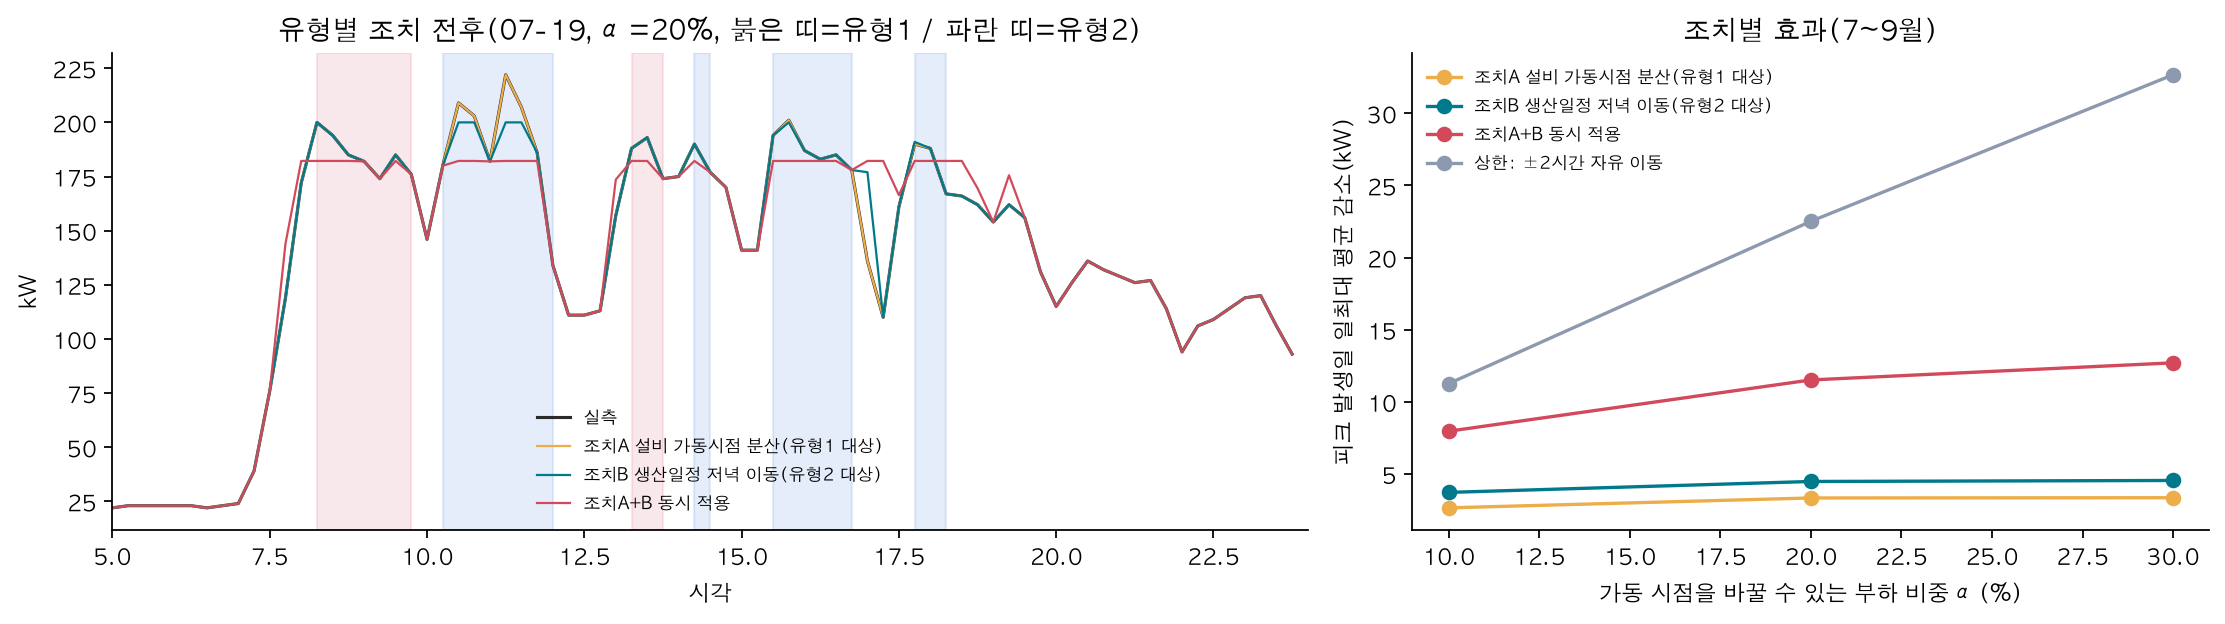

In [59]:
S, bytype, policy = step_mitigation(XD, Xte, dp, E)
show = ["조치", "alpha", "유형1 구간 최대 평균 전(kW)", "유형1 구간 최대 평균 후(kW)", "유형2 구간 최대 평균 전(kW)", "유형2 구간 최대 평균 후(kW)",
        "유형2 180kW 이상 시간 감소%", "피크 발생일 일최대 평균 감소(kW)", "피크 발생일 일최대 평균 감소(%)", "기간 최대수요전력 후(kW)"]
display(S[show])
print("▶ 날 유형별 일최대 감소(kW)"); display(bytype)
fig(S6 / "mitigation_by_type.png")

- **한 유형만 줄이면 다른 유형의 피크가 그날의 최대가 됩니다.** 그래서 조치 A만은 약 3kW, B만은 약 4.5kW입니다.
- **두 조치를 함께 쓰면 α 20%에서 일 최대가 평균 11.5kW(5.8%)** 줄고, 재가동일에는 14.4kW 줄어듭니다.
- 상한(±2시간 자유 이동)은 22.5kW로, 운영 제약을 얼마나 풀 수 있느냐에 따라 추가 여지가 있습니다.

### 6.2 예측 연동 운영 검증

위 시뮬레이션은 그날의 실측을 안다고 가정합니다. 현실에서는 **하루 전 예측만 보고** 계획을 세워야 하므로, 시험 구간에서 따로 검증했습니다.

- 규칙: 일 최대 예측이 경보 기준 이상인 날, 주간(8~17시) 설비 블록 Δ kW를 저녁(17~24시)으로 옮김
- 옮긴 전력량은 **예측 프로파일**에서 여유가 큰 슬롯에 나눠 넣음 → 그 계획을 실측에 적용해 평가

In [60]:
display(policy)
print("▶ Δ=15kW, 기준 185kW일 때 날짜별 결과"); display(table(S6 / "forecast_driven_policy_days.csv"))

,이전 블록 delta(kW),경보 기준(kW),조치일 수,시험기간 최대수요전력(kW),가동일 일최대 평균(kW),전력량요금 변화(원/2주),최대수요전력 감소(kW),"연간 기본요금 절감(원, 요금적용전력 반영 가정)"
0,10,조치 없음,0,204.00,192.50,0.00,0.00,0.00
1,10,195,1,204.00,191.50,-914.84,0.00,0.00
2,10,190,5,204.00,189.33,"-4,566.07",0.00,0.00
3,10,185,10,194.00,184.33,"-9,195.73",10.00,"896,400.00"
4,10,180,10,194.00,184.33,"-9,195.73",10.00,"896,400.00"
5,15,조치 없음,0,204.00,192.50,0.00,0.00,0.00
6,15,195,1,204.00,191.00,"-1,382.77",0.00,0.00
7,15,190,5,204.00,188.50,"-6,902.02",0.00,0.00
8,15,185,10,189.00,181.36,"-13,913.24",15.00,"1,344,600.00"
9,15,180,10,189.00,181.36,"-13,913.24",15.00,"1,344,600.00"


▶ Δ=15kW, 기준 185kW일 때 날짜별 결과


,date,예측 일최대,실측 일최대,경보(조치),조치 후 일최대
0,2021-09-01,189.30,198.00,1,183.60
1,2021-09-02,191.90,198.00,1,185.30
2,2021-09-03,187.90,190.00,1,176.10
3,2021-09-04,119.00,116.00,0,116.00
4,2021-09-05,40.40,28.00,0,28.00
5,2021-09-06,188.60,190.00,1,175.00
6,2021-09-07,191.40,192.00,1,177.00
7,2021-09-08,194.60,183.00,1,186.80
8,2021-09-09,187.60,190.00,1,177.00
9,2021-09-10,187.20,204.00,1,189.00


- 기준 185kW, Δ 15kW에서 시험 2주 최대수요전력이 **204 → 189kW**로 내려갑니다. 저녁 일부가 22~24시 경부하 시간대로 가므로 전력량요금도 줄어듭니다.
- 기준을 목표값 190kW 그대로 두면 9월 10일(실측 204, 예측 188)을 놓쳐 효과가 없습니다. **경보 기준 = 목표 − 일 최대 예측오차(약 5kW)** 로 잡아야 합니다.

### 6.3 요금 환산과 현장 운영 절차

요금 기준은 한전 산업용(갑)Ⅱ 고압A 선택Ⅱ입니다(최대 222kW로 계약전력 300kW 미만 가정, 준비 절의 설정값에서 변경 가능).
기본요금은 요금적용전력(직전 12개월 중 12·1·2·7·8·9월과 당월 최대수요전력의 최댓값)에 부과되므로, 여름 피크를 낮추면 1년 동안 효과가 이어집니다.

In [61]:
kw = BASIC_CHARGE_KRW_PER_KW
print(f"요금제: {TARIFF_NAME} | 기본요금 {kw:,}원/kW·월 → 1kW 감소 = 연 {kw * 12:,}원")
display(S[["조치", "alpha", "기간 최대수요전력 전(kW)", "기간 최대수요전력 후(kW)", "연간 기본요금 절감(원)", "전력량요금 변화(원/기간)"]])

요금제: 산업용전력(갑)Ⅱ 고압A 선택Ⅱ | 기본요금 7,470원/kW·월 → 1kW 감소 = 연 89,640원


,조치,alpha,기간 최대수요전력 전(kW),기간 최대수요전력 후(kW),연간 기본요금 절감(원),전력량요금 변화(원/기간)
0,조치A 설비 가동시점 분산(유형1 대상),0.10,222.00,222.00,0.00,-382.81
1,조치A 설비 가동시점 분산(유형1 대상),0.20,222.00,222.00,0.00,-863.01
2,조치A 설비 가동시점 분산(유형1 대상),0.30,222.00,222.00,0.00,-883.65
3,조치A+B 동시 적용,0.10,222.00,212.00,"896,400.00",545.21
4,조치A+B 동시 적용,0.20,222.00,212.00,"896,400.00",-603.45
5,조치A+B 동시 적용,0.30,222.00,212.00,"896,400.00","-4,656.67"
6,조치B 생산일정 저녁 이동(유형2 대상),0.10,222.00,218.00,"358,560.00",820.06
7,조치B 생산일정 저녁 이동(유형2 대상),0.20,222.00,218.00,"358,560.00","1,298.04"
8,조치B 생산일정 저녁 이동(유형2 대상),0.30,222.00,218.00,"358,560.00","1,359.48"
9,상한: ±2시간 자유 이동,0.10,222.00,206.40,"1,398,384.00","-2,721.24"


**현장 운영 절차(제안)**
1. **전일 오후, 생산계획 확정 직후** 모델 실행 → 다음 날 96개 15분 예측, 80% 구간, 일 최대 예측
2. 일 최대 예측이 **185kW 이상**이면 피크 경보일로 지정
3. **유형1 대비(가동시점 분산):** 8시와 13시에 한꺼번에 켜던 설비 일부를 1~2시간 먼저 켬. 재가동일에는 반드시 적용
4. **유형2 대비(생산일정 이동):** 9~11시, 14~15시에 몰린 생산 일부를 17시 이후로 이동. 일 최고 27℃ 이상 예보일에 우선 적용
5. **당일:** 경보 시간대(15분 예측 170kW 이상)와 피크 확률이 높은 시간대(1.8절의 우선순위 표)를 먼저 점검하고, 그 시간에는 설비 추가 기동을 미루도록 작업자에게 알림
6. **사후:** 예측과 실측 비교, 특수일·점심 정지 여부를 ERP에 기록, 매주 재학습

---
## 정리

### 발견한 사실과 근거

| # | 사실 | 근거(해당 절) |
|---|---|---|
| 1 | 1~6월은 서로 복사해 늘린 데이터, 7~9월은 원본 | 96개 값이 같은 날 160일, 7~9월과 일치하는 1~6월 날·시간 0건 (0.3) |
| 2 | 무작위 분할 검증은 성능을 부풀린다 | 시험 표본 58%가 학습셋에 복사본 (0.5) |
| 3 | 복사일 때문에 전날·전주 전력값이 예측에 해롭다 | LightGBM에 넣으면 MAE 8.19 → 12.93kW (1.3) |
| 4 | 07-13, 07-15는 행이 뒤섞여 시각을 알 수 없다 | 시간 값 70~188, 정상 모양과 불일치 (0.2) |
| 5 | 피크 시간에는 예측이 약 11kW 낮다 | 피크 시간 MAE 12.54, Bias −11.34 (2.1) |
| 6 | 큰 오차는 생산이 아주 많은 날과 휴가·공휴일 전후 특수일에서 나온다 | 07-30 −18.5kW, 08-16 +18.6kW (2.3) |
| 7 | 피크는 두 유형이고 원인이 다르다 | 실루엣 0.51, 모든 특성 p < 0.001 (4, 5) |
| 8 | 한 유형만 줄이면 일 최대는 거의 안 줄어든다 | A 3.3kW, B 4.5kW, A+B 11.5kW (6.1) |
| 9 | 경보 기준은 목표에서 예측오차를 빼야 한다 | 190kW 기준 효과 0, 185kW 기준 −15kW (6.2) |
| 10 | 15분 단위 피크 판정은 어렵고, 단순한 기준선 방식이 확률 모델보다 낫다 | Valid F1 0.69 대 0.66, 시험 F1 0.46 대 0.44. 베이스라인 0.37~0.39 (1.8) |
| 11 | 설정 탐색과 앙상블의 이득은 구간 편차보다 작다 | 탐색 이득 0.02~0.6kW, 구간별 표준편차 1.1~1.8kW. 최종은 Valid MAE 최저인 ExtraTrees (1.4, 1.5) |
| 12 | 공장인원은 전력에서 계산된 값이라 입력으로 쓰면 누수다 | 공장인원 = 생산량 ÷ 4구간 전력 합(3,511행 오차 1e-8 이하). 넣으면 MAE 8.19 → 7.73kW로 부풀려짐 (0.4) |

### 서면평가 지표 대응

| 지표(배점) | 대응 내용 | 절 |
|---|---|---|
| 1. 데이터 이해 및 진단(15) | 변수 의미, 가동 패턴, 결측·중복·이상치·불균형, 누수 변수(공장인원) 규명, 전처리, 검증전략 | 0 |
| 2. AI 예측모델 개발(40) | 전력량 예측: 베이스라인 포함 11개 모델 비교, 입력 구성 검증, **하이퍼파라미터 85가지 탐색, 앙상블 5종 비교**, 선정 근거. 피크 발생 확률 예측: 베이스라인 포함 6개 방식 F1·PR-AUC 비교 | 1.2~1.8 |
| 3. 영향요인 및 오류분석(15) | SHAP 영향변수·상호작용, 조건별 오차, 놓친 피크(FN)·헛경보(FP) 집중 조건 | 1.9, 2, 5 |
| 4. 현장 활용방안(10) | 하루 전 경보, 확률 기반 점검 우선순위, 유형별 조치, 작업자 알림 절차, 예측 연동 검증 | 1.8, 6 |
| 5. 창의성·차별성(10) | 불균형 가중 학습, 앙상블(5종 비교, 일 최대 앙상블), 불확실성 추정(구간 보정), 확률보정(등위 회귀), 제조지식 결합(누수 변수 규명, 복사일 탐지, 재가동일·피크 유형), 선형계획 | 0.3, 1.5, 1.7, 1.8, 4, 6 |
| 6. 코드 및 재현성(10) | 이 노트북 한 번 실행으로 전 과정 재현(시드·스레드·버전 고정) | 전체 |

### 외부 데이터

| 데이터 | 출처 | 사유·방법 |
|---|---|---|
| 대한민국 법정공휴일 | python-holidays 패키지 | 공휴일 가동 패턴 반영(`holiday` 변수) |
| 전기요금표 | 한국전력공사 전기요금표(종합), 2023.05.16 시행 | 피크 저감량의 요금 환산 |

데이터 출처: 중소벤처기업부, Korea AI Manufacturing Platform(KAMP), 자원 최적화 AI 데이터셋, KAIST(울산과학기술원, ㈜유피시앤에스), 2021.12.27., www.kamp-ai.kr

### 한계

- 기상 실측을 예보 대신 사용했습니다(LightGBM 기준 기상을 빼면 MAE 8.19 → 9.51kW).
- 옮길 수 있는 부하 비율 α와 블록 크기 Δ는 가정값입니다. 설비별 전력 계측으로 확인이 필요합니다.
- 저녁 생산은 인건비가 1.5배인 시간대이므로 인력 운영과 함께 설계해야 합니다.
- 원본 구간이 7~9월뿐이라 겨울 피크는 검증하지 못했습니다.

In [62]:
# 생성된 결과 파일 목록
for d in [S0, S1, S2, S3, S4, S5, S6, PRED]:
    print(f"{d.name:28s}", len(list(d.iterdir())), "개 파일")
display(table(PRED / "test_predictions_15min.csv").head())

step0_preprocess_split       11 개 파일
step1_forecast               20 개 파일
step2_error_analysis         13 개 파일
step3_peak_extraction        3 개 파일
step4_peak_types             5 개 파일
step5_peak_conditions        21 개 파일
step6_mitigation             7 개 파일
predictions                  3 개 파일


,일시(15분 시작),날짜,시간,15분구간(0~3),실측(kW),예측(kW),P10,P90,80%구간 하한(보정),80%구간 상한(보정),피크 발생 확률(보정),피크위험 경보(1=경보)
0,2021-09-01 00:00:00,2021-09-01,0,0,83.00,74.52,73.57,81.45,70.19,84.83,0.00,0
1,2021-09-01 00:15:00,2021-09-01,0,1,74.00,71.33,73.45,77.48,70.07,80.86,0.00,0
2,2021-09-01 00:30:00,2021-09-01,0,2,69.00,70.20,73.35,75.41,69.97,78.79,0.00,0
3,2021-09-01 00:45:00,2021-09-01,0,3,68.00,69.52,72.85,77.43,69.47,80.81,0.00,0
4,2021-09-01 01:00:00,2021-09-01,1,0,98.00,90.66,94.60,105.43,91.22,108.81,0.00,0
